In [1]:
#!pip install nimfa
#!pip install implicit

In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import csv
#import pandasql as ps
import matplotlib.pyplot as plt
#import shapefile as shp
import seaborn as sns
import random
import time
from sklearn.model_selection import train_test_split
#import pysal as ps
import scipy

#import torch
#import torch.nn as nn
#import torch.nn.parallel
#import torch.optim as optim
#import torch.utils.data

#from torch.nn import functional
#from torch.autograd import Variable

import statistics

#temporal pattern clustering
from tslearn.clustering import TimeSeriesKMeans, silhouette_score
from tslearn.utils import to_time_series_dataset
from sklearn import metrics
from scipy.cluster.hierarchy import fcluster
from scipy.stats import chisquare
from scipy.stats import wasserstein_distance

#regression model
from patsy import dmatrices
#import statsmodels.api as sm

from datetime import datetime

#from pysal.model import spreg
#from pysal.lib import weights
#from pysal.explore import esda

#calculate the demographic bias 
#use wasserstein_distance
from scipy.stats import wasserstein_distance

#path = 'C:/Users/29700/Downloads/RecSys-Workshop/tutorials/'
#os.chdir(path)
#import utilities as utl

from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
#from sklearn.metrics import mean_squared_error as mae
from datetime import datetime
import time
from sklearn.decomposition import NMF

import time
import scipy.sparse
from scipy.stats import entropy
from sys import exit

import itertools
from itertools import permutations

import xml.etree.ElementTree as ET

import geopandas as gpd

import copy 

import json

#binary factorization
import nimfa

from sklearn.decomposition import NMF
import scipy.sparse as sparse
import implicit

#extract number from str
import re

In [ ]:
#process the fcd data
path = "D:/My Drive/2021/Bias/sumo_simulation/"
os.chdir(path)
#os.listdir()

raw_dt_path = []
for i in os.listdir():
    if len(i) == 12 and '2017' in i:
        raw_dt_path.append(i)
print(raw_dt_path)

In [3]:
#read_csv
def get_data(raw_path, single_file=True):
    idx = 0
        
    if single_file == False:
        for path in raw_path:
            if idx == 0:
                dt = pd.read_csv(path)
                idx = 1
            else:
                dt_cur = pd.read_csv(path)
                dt = pd.concat([dt, dt_cur])
    else:
        dt = pd.read_csv(raw_path)
            
    get_hr = lambda x: int(x.split(':')[0])
    get_min = lambda x: int(x.split(':')[1])
    dt['hr'] = dt['time'].apply(get_hr)
    dt['min'] = dt['time'].apply(get_min)
    return(dt)

def get_time_variationbyzone(data, taz, time_loc, plot_index):
    data_taz = data[data['taz']==taz]
    data_taz = data_taz.sort_values(by=['hr', 'min'])
    data_taz = data_taz.groupby(by=['hr', 'min']).sum()
    
    data_taz.reset_index(inplace=True)
    data_taz = data_taz[['hr','min','sum']]
    #data_taz
    obs_sum = np.zeros((len(time_loc)))
    hr_ = data_taz['hr'].values
    min_ = data_taz['min'].values
    sum_val = data_taz['sum'].values
    
    for i in range(len(hr_)):
        obs_sum[time_loc[str(hr_[i])+'_'+str(min_[i])]] = sum_val[i]
    #use obs/max(obs) instead of obs/sum(obs) 
    obs_per = obs_sum/(np.max(obs_sum))
    
    if plot_index == True:
        fig = plt.figure(taz)
        plt.plot(obs_sum)
    return(obs_per)

def get_sim_obs_ts(fcd_out, taz_time_per, avg_per, return_sim=True):
    taz_ = fcd_out['taz'].values
    time_5 = fcd_out['time_5'].values
    per_ts = []
    for i in range(len(taz_)):
        if taz_[i] in taz_time_per:
            per_ts.append(taz_time_per[taz_[i]][time_5[i]])
        else:
            per_ts.append(avg_per[time_5[i]])
    if return_sim == True:
        sim_obs_ts = [] 
        for i in range(len(per_ts)):
            sim_obs_ts.append(np.random.binomial(1, per_ts[i], 1)[0])
        return(sim_obs_ts)
    else:
        return(per_ts)
    

#convert dt to matrix
def read_fcd(fcd_dt_path, app_based_data):
    fcd_out = pd.read_csv(fcd_dt_path, header=None)
    fcd_out.columns = ['id', 'taz', 'time']
    fcd_out.taz = fcd_out.taz.astype('int')
    
    
    revise_dt = lambda x: x.split('-')[0] if '-' in x else x
    get_sample_index = lambda x: x.split('-')[2] if '-' in x else 3
    fcd_out['reids'] = fcd_out['id'].apply(revise_dt)
    fcd_out['sample_index'] = (fcd_out['id'].apply(get_sample_index)).astype(int)
    
    fcd_out['time'] = fcd_out['time'].astype('int')
    fcd_out['hr'] = (fcd_out['time'].values/3600).astype(int)
    fcd_out['minus'] = ((fcd_out['time'].values- fcd_out['hr'].values*3600)/60).astype(int)
    fcd_out['time_30'] = (fcd_out['time']/30).astype(int)
    fcd_out['time_5'] = (fcd_out['time']/300).astype(int)
    
    print('num id', len(np.unique(fcd_out.reids)))

    #fcd_out.sort_values(by=['time', 'taz'])
    fcd_out['tl_id'] = fcd_out['taz'].astype(str)+'_'+(fcd_out['time_5']).astype(str)

    time_ = np.unique((fcd_out['time']/300).astype(int))
    
    if app_based_data == True:
        #sample index 0: non app-based samples, 1: app=based samples, 3: transit
        #fcd_out.groupby(by=['sample_index']).size()
        #sample_index 0    1714901, 1     572267, 3     180802
        return(fcd_out[fcd_out['sample_index']!=0])
    else:
        return(fcd_out)
    
def getfcdnorigindt(fcd_out, savepath, 
                    data_obs, time_loc, taz_time_per, avg_per, 
                    save_index):
    #get one day data (use 5 min as the time interval)
    #fcd_out = fcd_out[fcd_out['time_5']<288]
    newuser_ = {}
    index_ = 0
    for i in np.unique(fcd_out.reids):
        newuser_[i] = index_
        index_ += 1    
    ## fcd output processing
    #delete the data exceeds the 24-hr daily period
    #fcd_out = fcd_out[~fcd_out['time'].isin([86400, 86700])]
    fcd_out.time = fcd_out.time.astype('int')

    obs = data_obs.groupby(by=['time']).size().values
    obs_per = obs/max(obs)

    sample_ct = lambda x: np.random.binomial(1, obs_per[x], 1)[0]

    fcd_out['sim_obs'] = fcd_out['time_5'].apply(sample_ct)

    fcd_out['tl_id'] = fcd_out['taz'].astype(str)+'_'+((fcd_out['time']/300).astype(int)).astype(str)
    
    sim_obs = get_sim_obs_ts(fcd_out, taz_time_per, avg_per, True)
    fcd_out['sim_obs_ts'] = sim_obs

    #simulated observations based on time variation
    print('sim based on time', 
          np.count_nonzero(fcd_out['sim_obs'])/fcd_out.shape[0])

    #simulated observations based on time and spatial variation
    print('sim based on time and spatial',
          np.count_nonzero(fcd_out['sim_obs_ts'])/fcd_out.shape[0])
    
    return(fcd_out)

#fcd_out = read_fcd(fcd_dt_path, app_based_data)
def run_sim(csv_path, fcd_out, savepath, save_index=False, plot_index=True):
    data_obs = pd.read_csv(csv_path, header=0)
    print('app based data', data_obs.head(3))
    
    newids = np.unique(data_obs.newid)
    newid_ = {}
    index_ = 0
    for i in range(len(newids)):
        newid_[newids[i]] = index_
        index_ += 1
        
    get_hr = lambda x: x.split(':')[0]
    get_min = lambda x: x.split(':')[1]

    hr_ = np.unique(data_obs['time'].astype(str).apply(get_hr).astype(int))
    min_ = np.unique(data_obs['time'].astype(str).apply(get_min).astype(int))
    taz_ = np.unique(data_obs['taz'])

    data_obs['hr'] = data_obs['time'].astype(str).apply(get_hr).astype(int)
    data_obs['min'] = data_obs['time'].astype(str).apply(get_min).astype(int)
    
    index_ = 0
    lt_loc = {}
    for taz in taz_:
        for h in hr_:
            for m in min_:
                lt_loc['4_'+str(h)+'_'+str(m)+'_'+str(taz)] = index_
                index_ += 1
    obs_mx = np.zeros((len(newid_), len(lt_loc)))

    newid_col = data_obs.newid.values
    key_col = data_obs.key.values
    ct_col = data_obs['sum'].values

    for i in range(len(newid_col)):
        obs_mx[newid_[newid_col[i]]][lt_loc[key_col[i]]] = 1

    total_ct = np.sum(obs_mx, axis=0)
    #get ct based on taz and time
    total_ct = total_ct.reshape(1, total_ct.shape[0])
    total_ct_conver = np.hsplit(total_ct, len(taz_))
    max_num = np.max(np.array(total_ct_conver), axis=2)
    
    if plot_index == True:
        plt.plot(data_obs.groupby(by=['time']).size().values)
        
    time_loc = {}
    index_ = 0
    for hr in hr_:
        for miuts in min_:
            time_loc[str(hr)+'_'+str(miuts)] = index_
            index_ += 1

    taz_time_per = {}
    avg_per = 0
    index_ = 0 
    for taz_id in taz_:
        taz_time_per[taz_id] = get_time_variationbyzone(data_obs, taz_id, time_loc, plot_index)
        if index_ == 0:
            avg_per = taz_time_per[taz_id]
        else:
            avg_per = avg_per + taz_time_per[taz_id]
        index_ += 1
        
    avg_per = avg_per/np.max(avg_per)
    if plot_index == True:
        fig = plt.figure(1)
        plt.plot(avg_per)
        
    
    fcd_out = getfcdnorigindt(fcd_out, savepath, data_obs, time_loc, taz_time_per, avg_per, save_index=False)
    
    fcd_out['obs'] = 1
    #simulation compare
    print('sim_t vs sim_ts', mean_squared_error(fcd_out.sim_obs, fcd_out.sim_obs_ts, squared=False))
    print('obs vs sim_ts', mean_squared_error(fcd_out.obs, fcd_out.sim_obs_ts, squared=False))
    print('obs vs sim_t', mean_squared_error(fcd_out.obs, fcd_out.sim_obs, squared=False))
    
    return(fcd_out)   


def get_pred_timedict(num_taz, time_interval):
    pred_time_loc = {}
    for t in range(time_interval):
        select_time_loc = get_timeloc(num_taz, time_interval, t)
        pred_time_loc[t] = select_time_loc
    return(pred_time_loc)

def get_maxvalnindex(WHpert):
    max_val = np.max(WHpert, axis=1)
    max_index = np.argmax(WHpert, axis=1)
    return(max_val, max_index)

def get_pred_dt(WH_pred, time_interval):
    num_taz = int(WH_pred.shape[1]/time_interval)
    #print('num taz', num_taz)
    pred_time_dic = get_pred_timedict(num_taz, time_interval)
    for t in pred_time_dic:
        pred_val = WH_pred[:, pred_time_dic[t]]
        if t == 0:
            max_val, max_index = get_maxvalnindex(pred_val)
        else:
            max_val_cur, max_index_cur = get_maxvalnindex(pred_val)
            max_val = np.vstack((max_val, max_val_cur))
            max_index = np.vstack((max_index, max_index_cur))
    return(max_val.T, max_index.T)  


def get_simdt(fcd_out, sim_col, newuser_, loc_time):
    sim_dt = np.zeros((len(newuser_), len(loc_time)))
    fcd_obs = fcd_out[['reids', 'tl_id', 'sim_obs']].groupby(by=['reids', 'tl_id']).sum()
    fcd_obs.reset_index(inplace=True) 
    ids_ = fcd_obs['reids'].values
    tl_id_ = fcd_obs['tl_id'].values
    sim_obs = fcd_obs['sim_obs'].values
    for i in range(len(ids_)):
        sim_dt[newuser_[ids_[i]]][loc_time[tl_id_[i]]] = sim_obs[i]
    return(sim_dt)

def fit_dt(fcd_out, sim_col, newuser_, loc_time, k_val): 
    sim_dt = get_simdt(fcd_out, sim_col, newuser_, loc_time)
    #predict data based on time
    model = NMF(n_components=k_val, init='random', random_state=0)
    W = model.fit_transform(sim_dt)
    H = model.components_
    return(np.dot(W, H))

def get_index_lst(i, num_taz, num_time):
    return(list(np.arange(i, (num_time-1)*num_taz+i, num_time)))

#sep_dict = {'mor':[6, 9]
#            'noon':[9, 17]
#            'eve':[17, 20]}
def sep_indexdetime(num_taz, num_time, time_interval):
    sep_time = {'mor':[],
               'noon':[],
               'eve':[],
               'other':[]}
    for i in range(num_time):
        if i>=6*time_interval and i < 9*time_interval:
            sep_time['mor'].extend(get_index_lst(i, num_taz, num_time))
        elif i >= 9*time_interval and i < 17*time_interval:
            sep_time['noon'].extend(get_index_lst(i, num_taz, num_time))
        elif i>17*time_interval and i <20*time_interval:
            sep_time['eve'].extend(get_index_lst(i, num_taz, num_time))
        else:
            sep_time['other'].extend(get_index_lst(i, num_taz, num_time))
            
    for key in sep_time:
        sep_time[key] = sorted(sep_time[key])
    return(sep_time)


def fit_dtbytime(sim_dt, num_taz, num_time, time_interval, k_val, save_name):
    time_dict = sep_indexdetime(num_taz, num_time, time_interval)
    for ky in time_dict:
        #print(ky)
        input_dt = sim_dt[:, time_dict[ky]]
        model = NMF(n_components=k_val, init='random', random_state=0)
        W = model.fit_transform(sim_dt)
        H = model.components_
        WH = np.dot(W, H)
        WH_max, WH_index = get_pred_dt_time(WH, 288)
        pd.DataFrame(WH_max).to_csv('WH_max_'+ky+'_'+save_name+'.csv')
        pd.DataFrame(WH_index).to_csv('WH_index'+ky+'_'+save_name+'.csv')

def del_transit_oneobs(fcd_out):
    fcd_transit = fcd_out[fcd_out['sample_index']==3]
    fcd_transit = fcd_transit.groupby(by=['id']).size().to_frame()
    fcd_transit.reset_index(inplace=True)
    fcd_transit_ids = fcd_transit[['id']][fcd_transit[0]==1].values.flatten()
    #print(fcd_transit_ids)
    print('# o ftransit line with only one obs deleted', len(fcd_transit_ids))
    return(fcd_out[~fcd_out['id'].isin(fcd_transit_ids)])

def get_test_dt(fcd_out, selected_ids):
    fcd_test = (fcd_out[fcd_out['reids'].isin(selected_ids)]).sort_values(by=['reids', 'time_30'])
    fcd_test['od_taz'] = fcd_test['otaz'].astype(str)+'_'+fcd_test['dtaz'].astype(str)
    fcd_test = fcd_test.sort_values(by=['reids', 'time_30'])
    return(fcd_test)

def get_other_stay_od(fcd_ids):
    fcd_ids['otaz'] = fcd_ids['taz']
    fcd_ids['dtaz'] = fcd_ids[['taz']].shift(periods=-1, fill_value=fcd_ids['otaz'].values[-1])
    fcd_ids['od_taz'] = fcd_ids['otaz'].astype(str)+'_'+fcd_ids['dtaz'].astype(str)
    return(fcd_ids)

def get_stay_val(fcd_test, ids, other_index):
    fcd_ids = fcd_test[fcd_test['reids']==ids]
    if other_index == True:
        fcd_ids = get_other_stay_od(fcd_ids)

    fcd_index = fcd_ids.groupby(by=['od_taz', 'otaz','dtaz','time_5_new'], sort=False).size().to_frame()
    fcd_index.reset_index(inplace=True)
    fcd_index = fcd_index.sort_values(by=['time_5_new'])

    fcd_index['time_diff'] = fcd_index[['time_5_new']] - (fcd_index[['time_5_new']].shift(periods=1, fill_value=0))
    fcd_index['time_diff_index'] = fcd_index['time_diff']>1

    start_t = 0
    time_ = []
    taz_ = []
    first_index = False

    for i in range(fcd_index.shape[0]):
        #handle special condition, when the first index = 1
        if i == 0 and fcd_index.iloc[i, 5] == 1:
            first_index = True
        if fcd_index.iloc[i, 6] == True or first_index==True:
            add_time = np.arange(start_t, fcd_index.iloc[i, 3])
            time_.extend(add_time)
            taz_.extend(np.repeat(fcd_index.iloc[i, 1], len(add_time)))

        start_t = fcd_index.iloc[i, 3]+1

    if start_t-1 < 287:
        add_time = np.arange(start_t, 288)
        time_.extend(add_time)
        taz_.extend(np.repeat(fcd_index.iloc[i, 2], len(add_time)))
        
    return(np.vstack((np.repeat(ids, len(time_)), time_, taz_)))

def get_stays_mx(fcd_dt, selected_ids, other_index=False):
    fcd_test = get_test_dt(fcd_dt, selected_ids)
    index_ = 0
    for ids in np.unique(fcd_test['reids']):
        if index_ == 0:
            add_stay = get_stay_val(fcd_test, ids, other_index)
            index_ = 1
        else:
            add_stay_cur = get_stay_val(fcd_test, ids, other_index)
            add_stay = np.hstack((add_stay, add_stay_cur))
            
    return(add_stay.T)

#check add stay function
def add_stay_check(add_stay, selected_ids, fcd_out):
    #get fcd trip num based on the time
    fcd_trip_num = (fcd_out.sort_values(by=['reids', 'time_30'])).groupby(by=['reids', 'time_5'], sort=False).size().to_frame()
    fcd_trip_num.reset_index(inplace=True)
    fcd_trip_num = fcd_trip_num.groupby(by=['reids'], sort=False).size().to_frame()
    fcd_trip_num.reset_index(inplace=True)
    
    test = pd.DataFrame(add_stay)
    test.columns = ['reids', 'taz', 'time_5']
    test = test.groupby(by=['reids']).size().to_frame()
    test.columns = ['stay_num']
    test = test.join((fcd_trip_num[fcd_trip_num['reids'].isin(selected_ids)]).set_index('reids'))
    test.reset_index(inplace=True)
    test = test[~(test['reids'].isin(stays_[0].values))]
    test.columns = ['reids','stay_num', 'trip_num']
    test['total'] = test['stay_num']+test['trip_num']
    print(test['total'].describe())
    return(test[test['total']!=288])

#add ids with stays only
#time = np.range(0, 288)
def get_stays(stays_dt):
    for i in range(stays_dt.shape[0]):
        ids = stays_dt.iloc[i, 0]
        taz = stays_dt.iloc[i, 1]
        if i == 0 :
            stays = np.vstack((np.repeat(ids, 288),
                               np.arange(0, 288),
                               np.repeat(taz, 288)))
        else:
            stays = np.hstack((stays, np.vstack((np.repeat(ids, 288),
                                                 np.arange(0, 288),
                                                 np.repeat(taz, 288)))))
        
    return(stays.T)

def add_index(index_val, stay_mx):
    add_index = np.repeat(index_val, stay_mx.shape[0]).reshape(stay_mx.shape[0], 1)
    return(np.hstack((stay_mx, add_index)))

def join_dt(add_mx, colname, index_val):
    add_mx = add_index(index_val, add_mx)
    join_dt = pd.DataFrame(add_mx)
    join_dt.columns = colname
    return(join_dt)
    

#colname = ['reids', 'time_5', 'taz'], indexcol = 'col_index'
def get_filled_dt(stay, add_stay, add_stay_other, fcd_out, colname, indexcol):
    #add index to distinguish the filled dt
    fcd_dt = fcd_out[colname]
    fcd_dt[indexcol] = 3
    colname.append(indexcol)
    
    #add add stays
    fcd_dt = pd.concat([fcd_dt, join_dt(add_stay, colname, 0)])
    #add add other stays
    fcd_dt = pd.concat([fcd_dt, join_dt(add_stay_other, colname, 1)])
    #add stays only
    fcd_dt = pd.concat([fcd_dt, join_dt(stay, colname, 2)])
    
    return(fcd_dt.sort_values(by=['reids', 'time_5_new']))

def conver2mx(test_taz_time, taz_dict):
    time_len = len(np.unique(test_taz_time['minut_5']))
    taz_len = len(taz_dict)
    output_mx = np.zeros((taz_len, time_len))
    taz_val = test_taz_time.taz.values
    time_val = test_taz_time.minut_5.values
    num_val = test_taz_time[0].values 
    for i in range(test_taz_time.shape[0]):
        output_mx[taz_val[i]][time_val[i]] = num_val[i]
    return(output_mx)

def cal_time_taz_per(test_taz, test_taz_time, taz_dict):
    output_per = conver2mx(test_taz_time, taz_dict)
    print(output_per.shape)
    taz_ = test_taz_.taz.values
    num_ids = test_taz_[0].values
    
    missing_taz = []
    for i in range(output_per.shape[0]):
        if i in taz_:
            output_per[i, :] = output_per[i, :]/(num_ids[np.where(taz_==167)[0][0]])
        else:
            missing_taz.append(i)
    print('# of missing tazs', len(missing_taz))
    #add average data to the tazs without data info
    mean_per = np.sum(output_per, axis=0)/(len(taz_)-len(missing_taz))
    for i in missing_taz:
        output_per[i,:] = mean_per
    return(output_per)

#######
#get the simulated observed data
def check_fcd_dt(fcd_dt):
    fcd_colname = fcd_dt.columns
    id_dict = {}
    index_ = 0
    for i in np.unique(fcd_dt['reids']):
        if i not in id_dict:
            id_dict[i] = index_
            index_ += 1

    get_id_index = lambda x: id_dict[x]        
    fcd_dt['id_index']= fcd_dt['reids'].apply(get_id_index)
    if 'ts_index' not in fcd_colname:
        fcd_dt['ts_index'] = fcd_dt['taz_index']*288 + fcd_dt['time_5_new']
    return(fcd_dt)

#get the simulated observed data
def getinput_mx(fcd_dt, sim_col):
    fcd_val = fcd_dt[fcd_dt[sim_col] == 1]
    fcd_val = check_fcd_dt(fcd_val)
    #fcd_dt['ts_index'] = fcd_dt['taz_index']*288+fcd_dt['time_5_new'] 

    fcd_val = check_fcd_dt(fcd_val)
    input_mx = np.zeros((len(np.unique(fcd_val['reids'])),
                         len(np.unique(fcd_val['time_5_new']))*len(np.unique(fcd_val['taz_index']))))
   # print(input_mx.shape)
    
    vals = fcd_val[sim_col].values
    rows = fcd_val['id_index'].values
    cols = fcd_val['ts_index'].values
    for i in range(len(vals)):
        input_mx[rows[i], cols[i]] = vals[i]        
    return(input_mx)

def fit_dt01(fcd_dt, sim_col, k_val): 
    sim_dt = getinput_mx(fcd_dt, sim_col)
    #predict data based on time
    #for 0 and 1
    model = NMF(n_components=k_val, init='random', 
                random_state=0, solver='cd', 
                beta_loss='binary_reconstruction')
    
    W = model.fit_transform(sim_dt)
    H = model.components_
    return(np.dot(W, H))

def fit_dtbytime_stay01(fcd_dt, sim_col, time_interval, k_val, save_name):
    fcd_val = fcd_dt[fcd_dt[sim_col] == 1]
    num_taz = len(np.unique(fcd_dt['taz_index']))
    num_time = len(np.unique(fcd_dt['time_5_new']))
    sim_dt = getinput_mx(fcd_dt, sim_col)
    
    time_dict = sep_indexdetime(num_taz, num_time, time_interval)
    for ky in time_dict:
        #print(ky)
        input_dt = sim_dt[:, time_dict[ky]]
        model = NMF(n_components=k_val, init='random', 
                    random_state=0, solver='cd', 
                    beta_loss='binary_reconstruction')
        W = model.fit_transform(sim_dt)
        H = model.components_
        WH = np.dot(W, H)
        WH_max, WH_index = get_pred_dt_time(WH, 288)
        pd.DataFrame(WH_max).to_csv('WH_max_stay_'+ky+'_'+save_name+'.csv')
        pd.DataFrame(WH_index).to_csv('WH_index_stay_'+ky+'_'+save_name+'.csv')
    print('predtion based on time done')

def fit_dt(fcd_dt, sim_col, k_val): 
    sim_dt = getinput_mx(fcd_dt, sim_col)
    #predict data based on time
    #for 0 and 1
    model = NMF(n_components=k_val, init='random', random_state=0)
    
    W = model.fit_transform(sim_dt)
    H = model.components_
    return(np.dot(W, H))

def fit_dtbytime_stay(fcd_dt, sim_col, time_interval, k_val, save_name):
    fcd_val = fcd_dt[fcd_dt[sim_col] == 1]
    num_taz = len(np.unique(fcd_dt['taz_index']))
    num_time = len(np.unique(fcd_dt['time_5_new']))
    sim_dt = getinput_mx(fcd_dt, sim_col)
    
    time_dict = sep_indexdetime(num_taz, num_time, time_interval)
    for ky in time_dict:
        #print(ky)
        input_dt = sim_dt[:, time_dict[ky]]
        model = NMF(n_components=k_val, init='random', random_state=0)
        W = model.fit_transform(sim_dt)
        H = model.components_
        WH = np.dot(W, H)
        WH_max, WH_index = get_pred_dt(WH, 288)
        pd.DataFrame(WH_max).to_csv('WH_max_stay_'+ky+'_'+save_name+'.csv')
        pd.DataFrame(WH_index).to_csv('WH_index_stay_'+ky+'_'+save_name+'.csv')
    print('predtion based on time done')

#get time loc
#time_interval = 288
#num_taz = int(WH_ts.shape[1]/time_interval)

def get_timeloc(num_taz, time_interval, t):
    select_time_loc = []
    for i in range(num_taz):
        select_time_loc.append(time_interval*i+t)
    return(select_time_loc)

def get_pred_timedict(num_taz, time_interval):
    pred_time_loc = {}
    for t in range(time_interval):
        select_time_loc = get_timeloc(num_taz, time_interval, t)
        pred_time_loc[t] = select_time_loc
    return(pred_time_loc)

def get_maxvalnindex(WHpert):
    max_val = np.max(WHpert, axis=1)
    max_index = np.argmax(WHpert, axis=1)
    return(max_val, max_index)


def get_pred_dt_time(WH_pred, time_interval):
    num_taz = int(WH_pred.shape[1]/time_interval)
    print('num taz', num_taz)
    pred_time_dic = get_pred_timedict(num_taz, time_interval)
    for t in pred_time_dic:
        pred_val = WH_pred[:, pred_time_dic[t]]
        if t == 0:
            max_val, max_index = get_maxvalnindex(pred_val)
        else:
            max_val_cur, max_index_cur = get_maxvalnindex(pred_val)
            max_val = np.vstack((max_val, max_val_cur))
            max_index = np.vstack((max_index, max_index_cur))
    return(max_val.T, max_index.T) 

def get_idx_dict(idx_val):
    idx = 0
    idx_dict = {}
    for i in idx_val:
        if i not in idx_dict:
            idx_dict[i] = idx
            idx += 1
    return(idx_dict)

def get_dt_idx(idx_col, dt, idx_dict):
    get_idx = lambda x: idx_dict[x]
    dt[idx_col+'_idx'] = dt[idx_col].apply(get_idx)
    return(dt)

def get_time_idx(dt, time_col):
    get_hr = lambda x: int(x.split(':')[0])
    get_min = lambda x: int(x.split(':')[1])
    
    dt[time_col+'_idx'] = (dt[time_col].apply(get_hr)*12+dt[time_col].apply(get_min)/5).astype(int)
    return(dt)

def convert2matrix(dt, time_range):
    newids = np.unique(dt['newid'])
    newid_dict = get_idx_dict(newids) 
    dt = get_dt_idx('newid', dt, newid_dict)
    
    taz =  np.unique(dt['taz'])
    taz_dict = get_idx_dict(taz)
    dt = get_dt_idx('taz', dt, taz_dict)
    
    dt = get_time_idx(dt, 'time')
    
    dt['lt_idx'] = (dt['taz_idx']*time_range+dt['time_idx']).astype(int)
    
    arr = np.zeros((len(newids), len(taz) * time_range))
    
    lt_idx = dt['lt_idx'].values
    newid_idx = dt['newid_idx'].values
    
    for i in range(dt.shape[0]):
        arr[newid_idx[i], lt_idx[i]] = 1
    return(arr)  

def get_timeloc(num_taz, time_interval, t):
    select_time_loc = []
    for i in range(num_taz):
        select_time_loc.append(time_interval*i+t)
    return(select_time_loc)

def get_pred_timedict(num_taz, time_interval):
    pred_time_loc = {}
    for t in range(time_interval):
        select_time_loc = get_timeloc(num_taz, time_interval, t)
        pred_time_loc[t] = select_time_loc
    return(pred_time_loc)

def convert_timedic2mx(time_dict):
    #dataDict = {'device1':(1,1,0,1), 'device2':(0,1,0,1), 'device3':(1,0,0,1)}
    #orderedNames = ['device1','device2','device3']
    times = list(time_dict.keys())
    dataMatrix = np.array([time_dict[i] for i in times])
    return(dataMatrix)

def get_missing_rate(time_index_mx, input_mx_indi):
    indi_m = input_mx_indi[time_index_mx]
    return(np.count_nonzero(np.sum(indi_m,axis=1))/(indi_m.shape[0]))


def check_missings(dt, time_range, plot_idx=True):
    input_mx = convert2matrix(dt, time_range)
    num_taz = int(input_mx.shape[1]/time_range)
    #print('num taz', num_taz)
    time_dic = get_pred_timedict(num_taz, time_range)
    time_mx = convert_timedic2mx(time_dic)
    missing_rate = []
    for i in range(input_mx.shape[0]):
        missing_rate.append(get_missing_rate(time_mx, input_mx[i,]))
        #print(missing_rate)
    if plot_idx == True:
        plt.hist(missing_rate)
        plt.title('hist of non-missing rate')
        plt.xlabel('non-missing rate')
        plt.ylabel('# of ids')
        print(max(missing_rate))
        print(min(missing_rate))
    return(np.array(missing_rate))

#for input matrix
def check_missings_mx(input_mx, time_interval, plot_idx=True):
    num_taz = int(input_mx.shape[1]/time_interval)
    #print('num taz', num_taz)
    time_dic = get_pred_timedict(num_taz, time_interval)
    time_mx = convert_timedic2mx(time_dic)
    missing_rate = []
    for i in range(input_mx.shape[0]):
        missing_rate.append(get_missing_rate(time_mx, input_mx[i,]))
        #print(missing_rate)
    if plot_idx == True:
        plt.hist(missing_rate)
        plt.title('hist of non-missing rate')
        plt.xlabel('non-missing rate')
        plt.ylabel('# of ids')
        print(max(missing_rate))
        print(min(missing_rate))
    return(np.array(missing_rate))

#no ground truth to check 
def zero_est_eval(est_matrix, zero_index):
    zero_est = np.count_nonzero(est_matrix[np.where(zero_index>0)])
    zero_ratio = 1 - zero_est/np.count_nonzero(zero_index)
    return(zero_ratio)

In [ ]:
#app_based_test_dt = get_data(raw_dt_path[0], True)
#missing_info = check_missings(app_based_test_dt, 288)

#use the census tract
path = 'D:/My Drive/2021/Bias/'
#save matrice
#np.savetxt('test_matrice_reverse.csv', test_matrice_reverse, delimiter=",")
#np.savetxt('Zero_index.csv', Zero_index, delimiter=",")

#read the test matrice and data
test_matrice_reverse = pd.read_csv(path+'test_matrice_reverse.csv', header=None).to_numpy()
Zero_index = pd.read_csv(path+'Zero_index.csv', header=None).to_numpy()
#Seattle_ct = pd.read_csv('G:/My Drive/2021/Bias/census_tract_process/Seattle_ct.csv')
#geoids = np.unique(Seattle_ct.GEOID10)
newids = test_matrice_reverse[:, 0]

test_matrice_reverse = test_matrice_reverse[:, 1:]

missing_sum = check_missings_mx(test_matrice_reverse, 288)
missing_sum  = pd.DataFrame(missing_sum)
missing_sum[0].describe()

count    7767.000000
mean        0.050230
std         0.076175
min         0.003472
25%         0.006944
50%         0.020833
75%         0.059028
max         0.968750
Name: 0, dtype: float64

0.96875
0.003472222222222222


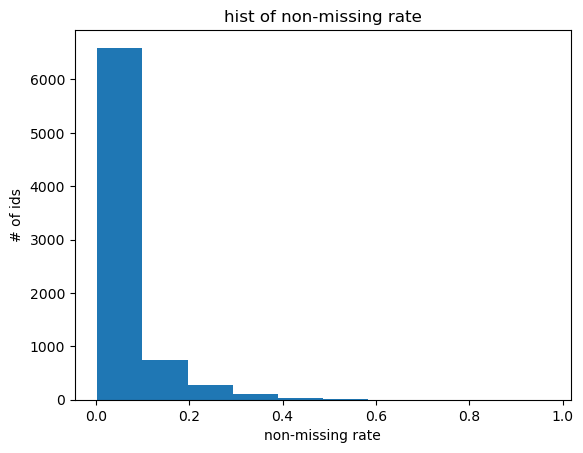

In [ ]:
missing_sum = check_missings_mx(test_matrice_reverse, 288)
#how the missing rate is calculated
#np.count_nonzero(np.sum(test_matrice_reverse[0].reshape(12, 288), axis=0))/288

In [4]:
def check_pred_index(fit_dt, WH_index):
    WH_max_mis, WH_index_mis = get_pred_dt(fit_dt, 288)

    #real vs revised data
    match_per = np.count_nonzero(1*((WH_index_mis == WH_index)==True))/(len(WH_index_mis.flatten()))
    #sim pred vs sim true
    #mx location with pred != raw dt
    check_idx = np.where((1*((WH_index_mis == WH_index)==True))==0)
    mitigate_miss_per  = np.count_nonzero(WH_index[check_idx]>0)/(len(WH_index[check_idx]))
    
    print('matched % compared with raw dt', match_per)
    print('% of missings mitigated', mitigate_miss_per)
    return(match_per, mitigate_miss_per)
    
        

def check_pred_indexbytime(fit_dt, WH_index, num_taz, ky):
    WH_max_mis, WH_index_mis = get_pred_dt_time(fit_dt, num_taz)

    #sim var vs sim true
    match_per = (np.count_nonzero(1*((WH_index_mis == WH_index)==True))/(len(WH_index_mis.flatten())))
    #sim pred vs sim true
    check_idx = np.where((1*((WH_index_mis == WH_index)==True))==0)
    mitigate_miss_per  = np.count_nonzero(WH_index[check_idx]>0)/(len(WH_index[check_idx]))
    
    print('matched % compared with raw dt'+ky+',', match_per)
    print('% of missings mitigated'+ky+',', mitigate_miss_per)
    
    return(match_per, mitigate_miss_per)

def get_pred_dt_time(WH_pred, num_taz):
    #print('num taz', num_taz)
    time_interval = int(WH_pred.shape[1]/num_taz)
    pred_time_dic = get_pred_timedict(num_taz, time_interval)
    for t in pred_time_dic:
        pred_val = WH_pred[:, pred_time_dic[t]]
        if t == 0:
            max_val, max_index = get_maxvalnindex(pred_val)
        else:
            max_val_cur, max_index_cur = get_maxvalnindex(pred_val)
            max_val = np.vstack((max_val, max_val_cur))
            max_index = np.vstack((max_index, max_index_cur))
    return(max_val.T, max_index.T) 


def get_pred_timedict(num_taz, time_interval):
    pred_time_loc = {}
    for t in range(time_interval):
        select_time_loc = get_timeloc(num_taz, time_interval, t)
        pred_time_loc[t] = select_time_loc
    return(pred_time_loc)


def save_result_dict(result_dict, savename):
    # create json object from dictionary
    #json = json.dumps(result_dict)
    # open file for writing, "w" 
    f = open(savename,"w")
    # write json object to file
    f.write(str(result_dict))
    # close file
    f.close()


### Sensitive test

In [6]:
def get_num_txt(line):
    nums = re.findall("\d+", line)
    est_ = nums[-2]+'.'+nums[-1]
    return(float(est_))


def get_para_dt(txt_file, result_para_dict):    
    with open(txt_file, 'r') as f:
        lines = f.readlines()
    f.close()
    
    para_result =  copy.deepcopy(result_para_dict)
    paras = list(para_result['ori'].keys())

    event_idx = 0
    start_idx = 0


    for l in lines:
        if l=='\n':
            pass
        else:
            if 'mor' in l or event_idx == 1:
                event_idx = 1
                est_val = get_num_txt(l)
                para_result['mor'][paras[start_idx%4]].append(est_val)
                if start_idx%4 == 3:
                    event_idx = 0

            elif 'eve' in l or event_idx == 3:
                event_idx = 3
                est_val = get_num_txt(l)
                para_result['eve'][paras[start_idx%4]].append(est_val)
                if start_idx%4 == 3:
                    event_idx = 0

            elif 'noon' in l or event_idx == 2:
                event_idx = 2
                est_val = get_num_txt(l)
                para_result['noon'][paras[start_idx%4]].append(est_val)
                if start_idx%4 == 3:
                    event_idx = 0

            elif 'other' in l or event_idx == 4:
                event_idx = 4
                est_val = get_num_txt(l)
                para_result['other'][paras[start_idx%4]].append(est_val)
                if start_idx%4 == 3:
                    event_idx = 0

            else:
                est_val = get_num_txt(l)
                para_result['ori'][paras[start_idx%4]].append(est_val)
            start_idx += 1
    
    return(para_result)

#prediction based on time
#prediction based on time
def get_rmse(test_matrix, est_matrix, zero_index):
    pred_rmse = mean_squared_error(test_matrix, est_matrix, squared=False)
    
    test = test_matrix.copy()    
    test = test - np.multiply(test, zero_index)
    est = est_matrix.copy()
    est = np.round(est - np.multiply(est, zero_index),0)
    
    zero_rmse = mean_squared_error(test, est, squared=False)

    return(pred_rmse, zero_rmse) 

def fit_process_dt_mf01_sensitive_w0(dt, missing_info, missing_val, para_lst, Zero_index, random_init): 
    #convert data into matrix
    result_para = []
    fit_dt = dt[np.where(missing_info>=missing_val)[0],]
    zero_dt = Zero_index[np.where(missing_info>=missing_val)[0],]
   
    #predict data based on missing_rate
    
    #para_lst = [k_val, alpha_W, alpha_H, l1_ratio, zero_weight]        
    model = NMF_w0(n_components=para_lst[0], init=random_init, random_state=0,
                   alpha_W = para_lst[1], alpha_H = para_lst[2],
                   l1_ratio = para_lst[3], zero_weight=para_lst[4], 
                   beta_loss='kullback-leibler',
                   solver="zero")
    W = model.fit_transform_w0(fit_dt, zero_dt)
    H = model.components_
    WH = np.dot(W, H)
        
    #check if the model fit the data well    
    if True in np.isnan(W) or True in np.isnan(H):
        print('Error, fitting data failed')
        del(W, H)
        return([0,0,0,0,0])
        
    else:
        pred_dt = np.dot(W, H)
        pred_dt = np.array(pred_dt)
    
        model_rmse, model_rmse_zero = get_rmse(fit_dt, pred_dt, zero_dt)
        zero_val = zero_est_eval(pred_dt, zero_dt)

        print('RMSE, data with missing rate>='+str(missing_val)+', para='+str(para_lst)+',', model_rmse)
        print('RMSE, zero, data with missing rate>='+str(missing_val)+', para='+str(para_lst)+',', model_rmse_zero)
        print('zero_val'+', para='+str(para_lst)+',', zero_val)

        WH_max, WH_index = get_pred_dt(pred_dt, 288)
        match_per, mitigate_miss_per = check_pred_index(fit_dt, WH_index)

        result_para = [model_rmse, model_rmse_zero, zero_val, match_per, mitigate_miss_per]    

        del(W, H, pred_dt)
        return(result_para)


#para_lst_nmf = [k_val, alpha_W, alpha_H, l1_ratio]
#para_lst_bmf = [k_val, lambda_w, lambda_h]    
def fit_dtbytime_sensitive_w0(dt, missing_info, missing_val, 
                              time_interval, para_lst, Zero_index, random_init):
     
    test_dt = dt
    num_time = 288
    num_taz = int(dt.shape[1]/num_time)    
    #predict data based on missing_rate
    
    fit_dt = test_dt[np.where(missing_info>=missing_val)[0],]
    zero_dt = Zero_index[np.where(missing_info>=missing_val)[0],]
    
    time_dict = sep_indexdetime(num_taz, num_time, time_interval)
    
    null_idx = 0
    result_para = {}
    for ky in time_dict:
        result_para[ky] = []
        #print(ky)
        input_dt = fit_dt[:, time_dict[ky]]
        zero_input_dt = zero_dt[:, time_dict[ky]]

        #para_lst_nmf = [k_val, alpha_W, alpha_H, l1_ratio]
        model = NMF_w0(n_components=para_lst[0], init=random_init, random_state=0,
               alpha_W = para_lst[1], alpha_H = para_lst[2],
               l1_ratio = para_lst[3], zero_weight=para_lst[4], 
               beta_loss='kullback-leibler',
               solver="zero")
        W = model.fit_transform_w0(input_dt, zero_input_dt)
        H = model.components_
        WH = np.dot(W, H)
        
        if True in np.isnan(W) or True in np.isnan(H):
            print('Error, fitting data failed')
            null_idx = 1
            del(W, H)
            result_para[ky] = [0,0,0,0,0]
        
        else:
            #print(WH.shape)
            pred_dt = np.dot(W, H)
            pred_dt = np.array(pred_dt)
            
            WH_max, WH_index = get_pred_dt_time(pred_dt, num_taz)
            #print(WH_max.shape, WH_index.shape)

            
            model_rmse, model_rmse_zero = get_rmse(input_dt, pred_dt, zero_input_dt)
            zero_val = zero_est_eval(pred_dt, zero_input_dt)

            print('RMSE, data with missing rate>='+str(missing_val)+', para='+str(para_lst)+','+ky+',', model_rmse)
            print('RMSE, zero, data with missing rate>='+str(missing_val)+', para='+str(para_lst)+','+ky+',', model_rmse_zero)
            print('zero_val'+', para='+str(para_lst)+',', zero_val)

            match_per, mitigate_miss_per = check_pred_indexbytime(input_dt, WH_index, num_taz, ky)

            del(WH_max, WH_index, pred_dt)
            #pd.DataFrame(WH_max).to_csv('WH_max_'+ky+'_'+save_name+'.csv')
            #pd.DataFrame(WH_index).to_csv('WH_index'+ky+'_'+save_name+'.csv')
            result_para[ky] = [model_rmse, model_rmse_zero, zero_val, match_per, mitigate_miss_per]
    
    return(result_para)    

def get_pred_dt_time(WH_pred, num_taz):
    #print('num taz', num_taz)
    time_interval = int(WH_pred.shape[1]/num_taz)
    pred_time_dic = get_pred_timedict(num_taz, time_interval)
    for t in pred_time_dic:
        pred_val = WH_pred[:, pred_time_dic[t]]
        if t == 0:
            max_val, max_index = get_maxvalnindex(pred_val)
        else:
            max_val_cur, max_index_cur = get_maxvalnindex(pred_val)
            max_val = np.vstack((max_val, max_val_cur))
            max_index = np.vstack((max_index, max_index_cur))
    return(max_val.T, max_index.T) 


def get_pred_timedict(num_taz, time_interval):
    pred_time_loc = {}
    for t in range(time_interval):
        select_time_loc = get_timeloc(num_taz, time_interval, t)
        pred_time_loc[t] = select_time_loc
    return(pred_time_loc)

def add_result2dict_w0(result_para, result_para_time, result_para_dict):
    result_para_dict = add_val_w0(result_para, 'ori', result_para_dict)
    result_para_dict = add_val_w0(result_para_time['mor'], 'mor', result_para_dict)
    result_para_dict = add_val_w0(result_para_time['noon'], 'noon', result_para_dict)
    result_para_dict = add_val_w0(result_para_time['eve'], 'eve', result_para_dict)
    result_para_dict = add_val_w0(result_para_time['other'], 'other', result_para_dict)
    return(result_para_dict)
    
    
def add_val_w0(result_val, ky, result_para_dict):    
    result_para_dict[ky]['rmse_predvssim'].append(result_val[0])
    result_para_dict[ky]['rmse_predvszero'].append(result_val[1])
    result_para_dict[ky]['per of zero val'].append(result_val[2])
    result_para_dict[ky]['per of match'].append(result_val[3])
    result_para_dict[ky]['per of missings mitigated'].append(result_val[4])
    return(result_para_dict)


def fit_model_get_para_sensitive_w0(fcd_dt, para_lst, missing_info, 
                                    missing_val, time_interval, result_para_dict, Zero_index, random_init):
    result_para_dict_return = copy.deepcopy(result_para_dict)
    for paras in para_lst:
        result_para = fit_process_dt_mf01_sensitive_w0(fcd_dt, 
                                                  missing_info, missing_val,  
                                                  paras, Zero_index, random_init)
        result_para_time = fit_dtbytime_sensitive_w0(fcd_dt, 
                                        missing_info, missing_val, 12, 
                                        paras, Zero_index, random_init)
        result_para_dict_return = add_result2dict_w0(result_para, result_para_time, result_para_dict_return)
        #rmse_sparse_100.append(fit_process_dt_nmf_csrsparse(sim_dt, missing_info, i, 100))
    return(result_para_dict_return)


def plot_paras_sensitive_w0(result_para_dict, xval, paras_intest, para_loc, idx):
    xval = np.array(xval)[:, para_loc]
    x_val = []
    for x in xval:
        if x < 1:
            x_val.append(round(x, 2))
        else: 
            x_val.append(x)

    #convert xval from number to string
    linestylelst = ['solid', 'dashed', 'dashed','dashed','dashed']
    makerlst = [None, None, '.', '^','*']
    plotidx = 0
    xval = list(map(str, list(x_val)))
    for ky in result_para_dict:
        #plt.figure(idx)
        paras = list(result_para_dict[ky].keys())
        #print(paras)
        #fig.tight_layout()
        
        #ax[0].set_title('RMSE')
        #print(result_para_dict[ky][paras[0]])
        plt.figure(idx)
        plt.title('sensitive test, test para: '+paras_intest)
        plt.plot(xval, result_para_dict[ky][paras[0]], label=ky,
                linestyle=linestylelst[plotidx], marker=makerlst[plotidx])
        plt.grid()
        plt.xlabel(paras_intest)
        plt.xticks(rotation=45)
        plt.ylabel('RMSE')
        #ax[0, 0].legend()
        plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
        
        plt.figure(idx+1)
        plt.plot(xval, result_para_dict[ky][paras[1]], label=ky, 
                 linestyle=linestylelst[plotidx], marker=makerlst[plotidx])
        plt.grid()
        plt.xlabel(paras_intest)
        plt.xticks(rotation=45)
        plt.ylabel('RMSE, sim pred vs sim zero')
        #ax[0, 1].legend()
        plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
        
        plt.figure(idx+2)
        plt.plot(xval, result_para_dict[ky][paras[2]], label=ky,
                linestyle=linestylelst[plotidx], marker=makerlst[plotidx])
        plt.grid()
        plt.xlabel(paras_intest)
        plt.xticks(rotation=45)
        plt.ylabel('zero index estimation')
        #ax[0, 1].legend()
        plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
        
        plt.figure(idx+3)
        plt.plot(xval, result_para_dict[ky][paras[3]], label=ky, 
                linestyle=linestylelst[plotidx], marker=makerlst[plotidx])
        plt.grid()
        plt.xlabel(paras_intest)
        plt.xticks(rotation=45)
        plt.ylabel('match per')
        #label = f"({x},{y})"
        plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')  
        
        plt.figure(idx+4)
        plt.plot(xval, result_para_dict[ky][paras[4]], label=ky, 
                 linestyle=linestylelst[plotidx], marker=makerlst[plotidx])
        plt.grid()
        plt.xlabel(paras_intest)
        plt.xticks(rotation=45)
        plt.ylabel('rate'+paras[4][3:])
        #label = f"({x},{y})"
        plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')  
        
        plotidx += 1

    return(idx+5) 

def generate_paralst(test_valrange, val_loc, other_val, para_len):
    para_lst = []
    add_para_cb = []
    idx = 0
    if len(val_loc) == 1:
        for i in range(para_len):
            if i in val_loc:
                add_para_cb.append(0)
            else:
                add_para_cb.append(other_val[idx])
                idx += 1
        #print(add_para_cb)        
        for j in range(len(test_valrange)):
            add_para_cb_cur = copy.deepcopy(add_para_cb)
            add_para_cb_cur[val_loc[0]] = test_valrange[j]
            para_lst.append(add_para_cb_cur)
        
    else:
        add_para_cb = np.zeros(para_len)
        idx = 0
        for i in range(para_len):
            if i not in val_loc:
                add_para_cb[i] = other_val[idx]
                idx += 1
        for j in range(len(test_valrange)):
            add_para_cb_cur = copy.deepcopy(add_para_cb)
            add_para_cb_cur[val_loc] = test_valrange[j]
            para_lst.append(list(add_para_cb_cur))
    
    #conver type k to int
    for i in range(len(para_lst)):
        para_lst[i][0] = int(para_lst[i][0])    
    
    return(para_lst)

### NMF with zero

In [8]:
#packages
import numbers
import scipy.sparse as sp
import warnings
from math import sqrt
import time

from sklearn.decomposition._cdnmf_fast import _update_cdnmf_fast #not able to be revised, visual studio version not matched
from sklearn._config import config_context
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.exceptions import ConvergenceWarning
from sklearn.utils import check_random_state, check_array
from sklearn.utils.extmath import randomized_svd, safe_sparse_dot, squared_norm
from sklearn.utils.validation import check_is_fitted, check_non_negative
from sklearn.metrics import mean_absolute_error

#code input NMF with zero
EPSILON = np.finfo(np.float32).eps

def norm(x):
    return sqrt(squared_norm(x))


def trace_dot(X, Y):
    return np.dot(X.ravel(), Y.ravel())


def _check_init(A, shape, whom):
    A = check_array(A)
    if np.shape(A) != shape:
        raise ValueError(
            "Array with wrong shape passed to %s. Expected %s, but got %s "
            % (whom, shape, np.shape(A))
        )
    check_non_negative(A, whom)
    if np.max(A) == 0:
        raise ValueError("Array passed to %s is full of zeros." % whom)
        

def _beta_divergence(X, W, H, beta, square_root=False):
    beta = _beta_loss_to_float(beta)

    # The method can be called with scalars
    if not sp.issparse(X):
        X = np.atleast_2d(X)
    W = np.atleast_2d(W)
    H = np.atleast_2d(H)

    # Frobenius norm
    if beta == 2:
        # Avoid the creation of the dense np.dot(W, H) if X is sparse.
        if sp.issparse(X):
            norm_X = np.dot(X.data, X.data)
            norm_WH = trace_dot(np.linalg.multi_dot([W.T, W, H]), H)
            cross_prod = trace_dot((X * H.T), W)
            res = (norm_X + norm_WH - 2.0 * cross_prod) / 2.0
        else:
            res = squared_norm(X - np.dot(W, H)) / 2.0

        if square_root:
            return np.sqrt(res * 2)
        else:
            return res

    if sp.issparse(X):
        # compute np.dot(W, H) only where X is nonzero
        WH_data = _special_sparse_dot(W, H, X).data
        X_data = X.data
    else:
        WH = np.dot(W, H)
        WH_data = WH.ravel()
        X_data = X.ravel()

    # do not affect the zeros: here 0 ** (-1) = 0 and not infinity
    indices = X_data > EPSILON
    WH_data = WH_data[indices]
    X_data = X_data[indices]

    # used to avoid division by zero
    WH_data[WH_data == 0] = EPSILON

    # generalized Kullback-Leibler divergence
    if beta == 1:
        # fast and memory efficient computation of np.sum(np.dot(W, H))
        sum_WH = np.dot(np.sum(W, axis=0), np.sum(H, axis=1))
        # computes np.sum(X * log(X / WH)) only where X is nonzero
        div = X_data / WH_data
        res = np.dot(X_data, np.log(div))
        # add full np.sum(np.dot(W, H)) - np.sum(X)
        res += sum_WH - X_data.sum()

    # Itakura-Saito divergence
    elif beta == 0:
        div = X_data / WH_data
        res = np.sum(div) - np.product(X.shape) - np.sum(np.log(div))

    # beta-divergence, beta not in (0, 1, 2)
    else:
        if sp.issparse(X):
            # slow loop, but memory efficient computation of :
            # np.sum(np.dot(W, H) ** beta)
            sum_WH_beta = 0
            for i in range(X.shape[1]):
                sum_WH_beta += np.sum(np.dot(W, H[:, i]) ** beta)

        else:
            sum_WH_beta = np.sum(WH ** beta)

        sum_X_WH = np.dot(X_data, WH_data ** (beta - 1))
        res = (X_data ** beta).sum() - beta * sum_X_WH
        res += sum_WH_beta * (beta - 1)
        res /= beta * (beta - 1)

    if square_root:
        return np.sqrt(2 * res)
    else:
        return res

def _special_sparse_dot(W, H, X):
    if sp.issparse(X):
        ii, jj = X.nonzero()
        n_vals = ii.shape[0]
        dot_vals = np.empty(n_vals)
        n_components = W.shape[1]

        batch_size = max(n_components, n_vals // n_components)
        for start in range(0, n_vals, batch_size):
            batch = slice(start, start + batch_size)
            dot_vals[batch] = np.multiply(W[ii[batch], :], H.T[jj[batch], :]).sum(
                axis=1
            )

        WH = sp.coo_matrix((dot_vals, (ii, jj)), shape=X.shape)
        return WH.tocsr()
    else:
        return np.dot(W, H)
    

def _beta_loss_to_float(beta_loss):
    """Convert string beta_loss to float."""
    allowed_beta_loss = {"frobenius": 2, "kullback-leibler": 1, "itakura-saito": 0}
    if isinstance(beta_loss, str) and beta_loss in allowed_beta_loss:
        beta_loss = allowed_beta_loss[beta_loss]
        return beta_loss
    
    elif type(beta_loss) == int:
        return beta_loss
    
    elif not isinstance(beta_loss, numbers.Number):
        raise ValueError(
            "Invalid beta_loss parameter: got %r instead of one of %r, or a float."
            % (beta_loss, allowed_beta_loss.keys())
        )
        print("warnings: beta loss not included")
    

def _initialize_nmf(X, n_components, init="warn", eps=1e-6, random_state=None):
    """Algorithms for NMF initialization.
    Computes an initial guess for the non-negative
    rank k matrix approximation for X: X = WH.
    """
    if init == "warn":
        warnings.warn(
            "The 'init' value, when 'init=None' and "
            "n_components is less than n_samples and "
            "n_features, will be changed from 'nndsvd' to "
            "'nndsvda' in 1.1 (renaming of 0.26).",
            FutureWarning,
        )
        init = None

    check_non_negative(X, "NMF initialization")
    n_samples, n_features = X.shape

    if (
        init is not None
        and init != "random"
        and n_components > min(n_samples, n_features)
    ):
        raise ValueError(
            "init = '{}' can only be used when "
            "n_components <= min(n_samples, n_features)".format(init)
        )

    if init is None:
        if n_components <= min(n_samples, n_features):
            init = "nndsvd"
        else:
            init = "random"

    # Random initialization
    if init == "random":
        avg = np.sqrt(X.mean() / n_components)
        rng = check_random_state(random_state)
        H = avg * rng.randn(n_components, n_features).astype(X.dtype, copy=False)
        W = avg * rng.randn(n_samples, n_components).astype(X.dtype, copy=False)
        np.abs(H, out=H)
        np.abs(W, out=W)
        return W, H

    # NNDSVD initialization
    U, S, V = randomized_svd(X, n_components, random_state=random_state)
    W = np.zeros_like(U)
    H = np.zeros_like(V)

    # The leading singular triplet is non-negative
    # so it can be used as is for initialization.
    W[:, 0] = np.sqrt(S[0]) * np.abs(U[:, 0])
    H[0, :] = np.sqrt(S[0]) * np.abs(V[0, :])

    for j in range(1, n_components):
        x, y = U[:, j], V[j, :]

        # extract positive and negative parts of column vectors
        x_p, y_p = np.maximum(x, 0), np.maximum(y, 0)
        x_n, y_n = np.abs(np.minimum(x, 0)), np.abs(np.minimum(y, 0))

        # and their norms
        x_p_nrm, y_p_nrm = norm(x_p), norm(y_p)
        x_n_nrm, y_n_nrm = norm(x_n), norm(y_n)

        m_p, m_n = x_p_nrm * y_p_nrm, x_n_nrm * y_n_nrm

        # choose update
        if m_p > m_n:
            u = x_p / x_p_nrm
            v = y_p / y_p_nrm
            sigma = m_p
        else:
            u = x_n / x_n_nrm
            v = y_n / y_n_nrm
            sigma = m_n

        lbd = np.sqrt(S[j] * sigma)
        W[:, j] = lbd * u
        H[j, :] = lbd * v

    W[W < eps] = 0
    H[H < eps] = 0

    if init == "nndsvd":
        pass
    elif init == "nndsvda":
        avg = X.mean()
        W[W == 0] = avg
        H[H == 0] = avg
    elif init == "nndsvdar":
        rng = check_random_state(random_state)
        avg = X.mean()
        W[W == 0] = abs(avg * rng.randn(len(W[W == 0])) / 100)
        H[H == 0] = abs(avg * rng.randn(len(H[H == 0])) / 100)
    else:
        raise ValueError(
            "Invalid init parameter: got %r instead of one of %r"
            % (init, (None, "random", "nndsvd", "nndsvda", "nndsvdar"))
        )

    return W, H

def _update_coordinate_descent(X, W, Ht, l1_reg, l2_reg, shuffle, random_state):
    """Helper function for _fit_coordinate_descent.
    Update W to minimize the objective function, iterating once over all
    coordinates. By symmetry, to update H, one can call
    _update_coordinate_descent(X.T, Ht, W, ...).
    """
    n_components = Ht.shape[1]

    HHt = np.dot(Ht.T, Ht)
    XHt = safe_sparse_dot(X, Ht)

    # L2 regularization corresponds to increase of the diagonal of HHt
    if l2_reg != 0.0:
        # adds l2_reg only on the diagonal
        HHt.flat[:: n_components + 1] += l2_reg
    # L1 regularization corresponds to decrease of each element of XHt
    if l1_reg != 0.0:
        XHt -= l1_reg

    if shuffle:
        permutation = random_state.permutation(n_components)
    else:
        permutation = np.arange(n_components)
    # The following seems to be required on 64-bit Windows w/ Python 3.5.
    permutation = np.asarray(permutation, dtype=np.intp)
    return _update_cdnmf_fast(W, HHt, XHt, permutation)

def _fit_coordinate_descent(
    X,
    W,
    H,
    tol=1e-4,
    max_iter=200,
    l1_reg_W=0,
    l1_reg_H=0,
    l2_reg_W=0,
    l2_reg_H=0,
    update_H=True,
    verbose=0,
    shuffle=False,
    random_state=None,
):
    """Compute Non-negative Matrix Factorization (NMF) with Coordinate Descent
    The objective function is minimized with an alternating minimization of W
    and H. Each minimization is done with a cyclic (up to a permutation of the
    features) Coordinate Descent.
    """
    # so W and Ht are both in C order in memory
    Ht = check_array(H.T, order="C")
    X = check_array(X, accept_sparse="csr")

    rng = check_random_state(random_state)

    for n_iter in range(1, max_iter + 1):
        violation = 0.0

        # Update W
        violation += _update_coordinate_descent(
            X, W, Ht, l1_reg_W, l2_reg_W, shuffle, rng
        )
        # Update H
        if update_H:
            violation += _update_coordinate_descent(
                X.T, Ht, W, l1_reg_H, l2_reg_H, shuffle, rng
            )

        if n_iter == 1:
            violation_init = violation

        if violation_init == 0:
            break

        if verbose:
            print("violation:", violation / violation_init)

        if violation / violation_init <= tol:
            if verbose:
                print("Converged at iteration", n_iter + 1)
            break
    #print(violation)

    return W, Ht.T, n_iter


def _multiplicative_update_w(
    X,
    W,
    H,
    beta_loss,
    l1_reg_W,
    l2_reg_W,
    gamma,
    H_sum=None,
    HHt=None,
    XHt=None,
    update_H=True,
):
    """Update W in Multiplicative Update NMF."""
    beta_loss = _beta_loss_to_float(beta_loss)
    if beta_loss == 2:
        # Numerator
        if XHt is None:
            XHt = safe_sparse_dot(X, H.T)
        if update_H:
            # avoid a copy of XHt, which will be re-computed (update_H=True)
            numerator = XHt
        else:
            # preserve the XHt, which is not re-computed (update_H=False)
            numerator = XHt.copy()

        # Denominator
        if HHt is None:
            HHt = np.dot(H, H.T)
        denominator = np.dot(W, HHt)

    else:
        # Numerator
        # if X is sparse, compute WH only where X is non zero
        WH_safe_X = _special_sparse_dot(W, H, X)
        if sp.issparse(X):
            WH_safe_X_data = WH_safe_X.data
            X_data = X.data
        else:
            WH_safe_X_data = WH_safe_X
            X_data = X
            # copy used in the Denominator
            WH = WH_safe_X.copy()
            #print(beta_loss)
            if beta_loss - 1.0 < 0:
                WH[WH == 0] = EPSILON

        # to avoid taking a negative power of zero
        if beta_loss - 2.0 < 0:
            WH_safe_X_data[WH_safe_X_data == 0] = EPSILON

        if beta_loss == 1:
            np.divide(X_data, WH_safe_X_data, out=WH_safe_X_data)
        elif beta_loss == 0:
            # speeds up computation time
            # refer to /numpy/numpy/issues/9363
            WH_safe_X_data **= -1
            WH_safe_X_data **= 2
            # element-wise multiplication
            WH_safe_X_data *= X_data
        else:
            WH_safe_X_data **= beta_loss - 2
            # element-wise multiplication
            WH_safe_X_data *= X_data

        # here numerator = dot(X * (dot(W, H) ** (beta_loss - 2)), H.T)
        numerator = safe_sparse_dot(WH_safe_X, H.T)

        # Denominator
        if beta_loss == 1:
            if H_sum is None:
                H_sum = np.sum(H, axis=1)  # shape(n_components, )
            denominator = H_sum[np.newaxis, :]

        else:
            # computation of WHHt = dot(dot(W, H) ** beta_loss - 1, H.T)
            if sp.issparse(X):
                # memory efficient computation
                # (compute row by row, avoiding the dense matrix WH)
                WHHt = np.empty(W.shape)
                for i in range(X.shape[0]):
                    WHi = np.dot(W[i, :], H)
                    if beta_loss - 1 < 0:
                        WHi[WHi == 0] = EPSILON
                    WHi **= beta_loss - 1
                    WHHt[i, :] = np.dot(WHi, H.T)
            else:
                WH **= beta_loss - 1
                WHHt = np.dot(WH, H.T)
            denominator = WHHt

    # Add L1 and L2 regularization
    if l1_reg_W > 0:
        denominator += l1_reg_W
    if l2_reg_W > 0:
        denominator = denominator + l2_reg_W * W
    denominator[denominator == 0] = EPSILON

    numerator /= denominator
    delta_W = numerator

    # gamma is in ]0, 1]
    if gamma != 1:
        delta_W **= gamma

    return delta_W, H_sum, HHt, XHt

def _multiplicative_update_h(X, W, H, beta_loss, l1_reg_H, l2_reg_H, gamma):
    beta_loss = _beta_loss_to_float(beta_loss)
    
    """Update H in Multiplicative Update NMF."""
    if beta_loss == 2:
        numerator = safe_sparse_dot(W.T, X)
        denominator = np.linalg.multi_dot([W.T, W, H])

    else:
        # Numerator
        WH_safe_X = _special_sparse_dot(W, H, X)
        if sp.issparse(X):
            WH_safe_X_data = WH_safe_X.data
            X_data = X.data
        else:
            WH_safe_X_data = WH_safe_X
            X_data = X
            # copy used in the Denominator
            WH = WH_safe_X.copy()
            print(beta_loss)
            if beta_loss - 1.0 < 0:
                WH[WH == 0] = EPSILON

        # to avoid division by zero
        if beta_loss - 2.0 < 0:
            WH_safe_X_data[WH_safe_X_data == 0] = EPSILON

        if beta_loss == 1:
            np.divide(X_data, WH_safe_X_data, out=WH_safe_X_data)
        elif beta_loss == 0:
            # speeds up computation time
            # refer to /numpy/numpy/issues/9363
            WH_safe_X_data **= -1
            WH_safe_X_data **= 2
            # element-wise multiplication
            WH_safe_X_data *= X_data
        else:
            WH_safe_X_data **= beta_loss - 2
            # element-wise multiplication
            WH_safe_X_data *= X_data

        # here numerator = dot(W.T, (dot(W, H) ** (beta_loss - 2)) * X)
        numerator = safe_sparse_dot(W.T, WH_safe_X)

        # Denominator
        if beta_loss == 1:
            W_sum = np.sum(W, axis=0)  # shape(n_components, )
            W_sum[W_sum == 0] = 1.0
            denominator = W_sum[:, np.newaxis]

        # beta_loss not in (1, 2)
        else:
            # computation of WtWH = dot(W.T, dot(W, H) ** beta_loss - 1)
            if sp.issparse(X):
                # memory efficient computation
                # (compute column by column, avoiding the dense matrix WH)
                WtWH = np.empty(H.shape)
                for i in range(X.shape[1]):
                    WHi = np.dot(W, H[:, i])
                    if beta_loss - 1 < 0:
                        WHi[WHi == 0] = EPSILON
                    WHi **= beta_loss - 1
                    WtWH[:, i] = np.dot(W.T, WHi)
            else:
                WH **= beta_loss - 1
                WtWH = np.dot(W.T, WH)
            denominator = WtWH

    # Add L1 and L2 regularization
    if l1_reg_H > 0:
        denominator += l1_reg_H
    if l2_reg_H > 0:
        denominator = denominator + l2_reg_H * H
    denominator[denominator == 0] = EPSILON

    numerator /= denominator
    delta_H = numerator

    # gamma is in ]0, 1]
    if gamma != 1:
        delta_H **= gamma

    return delta_H


def _fit_multiplicative_update(
    X,
    W,
    H,
    beta_loss="frobenius",
    max_iter=200,
    tol=1e-4,
    l1_reg_W=0,
    l1_reg_H=0,
    l2_reg_W=0,
    l2_reg_H=0,
    update_H=True,
    verbose=0,
):
    """Compute Non-negative Matrix Factorization with Multiplicative Update.
    The objective function is _beta_divergence(X, WH) and is minimized with an
    alternating minimization of W and H. Each minimization is done with a
    Multiplicative Update.
    
    """
    start_time = time.time()

    beta_loss = _beta_loss_to_float(beta_loss)

    # gamma for Maximization-Minimization (MM) algorithm [Fevotte 2011]
    if beta_loss < 1:
        gamma = 1.0 / (2.0 - beta_loss)
    elif beta_loss > 2:
        gamma = 1.0 / (beta_loss - 1.0)
    else:
        gamma = 1.0

    # used for the convergence criterion
    error_at_init = _beta_divergence(X, W, H, beta_loss, square_root=True)
    previous_error = error_at_init

    H_sum, HHt, XHt = None, None, None
    for n_iter in range(1, max_iter + 1):
        # update W
        # H_sum, HHt and XHt are saved and reused if not update_H
        delta_W, H_sum, HHt, XHt = _multiplicative_update_w(
            X, W, H, beta_loss, l1_reg_W, l2_reg_W, gamma, H_sum, HHt, XHt, update_H
        )
        W *= delta_W

        # necessary for stability with beta_loss < 1
        if beta_loss < 1:
            W[W < np.finfo(np.float64).eps] = 0.0

        # update H
        if update_H:
            delta_H = _multiplicative_update_h(
                X, W, H, beta_loss, l1_reg_H, l2_reg_H, gamma
            )
            H *= delta_H

            # These values will be recomputed since H changed
            H_sum, HHt, XHt = None, None, None

            # necessary for stability with beta_loss < 1
            if beta_loss <= 1:
                H[H < np.finfo(np.float64).eps] = 0.0

        # test convergence criterion every 10 iterations
        if tol > 0 and n_iter % 10 == 0:
            error = _beta_divergence(X, W, H, beta_loss, square_root=True)

            if verbose:
                iter_time = time.time()
                print(
                    "Epoch %02d reached after %.3f seconds, error: %f"
                    % (n_iter, iter_time - start_time, error)
                )

            if (previous_error - error) / error_at_init < tol:
                break
            previous_error = error

    # do not print if we have already printed in the convergence test
    if verbose and (tol == 0 or n_iter % 10 != 0):
        end_time = time.time()
        print(
            "Epoch %02d reached after %.3f seconds." % (n_iter, end_time - start_time)
        )

    return W, H, n_iter

def non_negative_factorization_w0(
    X,
    ZERO,
    W=None,
    H=None,
    n_components=None,
    *,
    init="warn",
    update_H=True,
    solver="cd",
    beta_loss="frobenius",
    tol=1e-4,
    max_iter=200,
    alpha="deprecated",
    alpha_W=0.0,
    alpha_H="same",
    l1_ratio=0.0,
    regularization="deprecated",
    random_state=None,
    verbose=0,
    shuffle=False,
):
    """Compute Non-negative Matrix Factorization (NMF).
    Find two non-negative matrices (W, H) whose product approximates the non-
    negative matrix X. This factorization can be used for example for
    dimensionality reduction, source separation or topic extraction.
   
    """
    X = check_array(X, accept_sparse=("csr", "csc"), dtype=[np.float64, np.float32])
    
    if type(ZERO) != int:
        zero_reg = ZEROS
    else:
        zero_reg = 0
    
    est = NMF_w0(
        n_components=n_components,
        init=init,
        solver=solver,
        beta_loss=beta_loss,
        tol=tol,
        max_iter=max_iter,
        random_state=random_state,
        alpha=alpha,
        alpha_W=alpha_W,
        alpha_H=alpha_H,
        l1_ratio=l1_ratio,
        verbose=verbose,
        shuffle=shuffle,
        regularization=regularization,
        zero_weight=zero_weight,
    )

    with config_context(assume_finite=True):
        W, H, n_iter = est._fit_transform_w0(X, zero_reg, W=W, H=H, 
                                             update_H=update_H)

    return W, H, n_iter

def check_nan(matrix, var):
    if True in np.isnan(matrix):
        print('nan in '+var)
        return(1)
    else:
        pass

def revise_nan(matrix):
    matrix[np.isnan(matrix)==True] = 0
    
def check_inf(matrix, var):
    if True in np.isinf(matrix):
        print('inf in '+var)
        return(1)
    else:
        pass
    
def check_non_zero(matrix, zero_index):
    if np.count_nonzero(zero_index) == 0:
        if np.count_nonzero(matrix) != 0:
            print('Warning, zero matrix return non zero')

def obj_loss_w0(
    X, 
    zero_reg,
    W, 
    H,
    beta_loss,
    l_zero,
    l1_reg_W,
    l1_reg_H,
    l2_reg_W,
    l2_reg_H,
):
    beta_loss = _beta_loss_to_float(beta_loss)
        
    obj = _beta_divergence(X, W, H, beta_loss, square_root=True)
        
    if l1_reg_W != 0:
        obj += l1_reg_W*np.linalg.norm(W.flatten(order="F"), 1)
    else:
        pass
        
    if l1_reg_H != 0:
        obj += l1_reg_H*np.linalg.norm(H.flatten(order="F"), 1)
    else:
        pass
        
    if l2_reg_W != 0:
        obj += l2_reg_W*np.linalg.norm(W)
    else:
        pass
        
    if l2_reg_H != 0:
        obj += l2_reg_H*np.linalg.norm(H)
    else:
        pass
        
    if l_zero != 0:
        obj += l_zero*np.linalg.norm((np.multiply(np.dot(W, H), zero_reg)-np.zeros(X.shape)))
    else:
        pass
        
    return(obj)

def _gradient_update_w(
    X,
    zero_reg,
    W,
    H,
    beta_loss,
    l1_reg_W,
    l2_reg_W,
    l_zero,
    H_sum = None,
    HHt=None,
    XHt=None,
    update_H=True,
):
    """Update W in Multiplicative Update NMF."""
    #print('X', X.shape)
    #print('zero index', zero_reg.shape)
    #print('W', W.shape)
    #print('H', H.shape)
    beta_loss = _beta_loss_to_float(beta_loss)
    
    if type(zero_reg) != int:
        zero_matrix = np.zeros(X.shape)
    
    if beta_loss == 2:
        # Numerator
        if XHt is None:
            XHt = safe_sparse_dot(X, H.T)
        if update_H:
            # avoid a copy of XHt, which will be re-computed (update_H=True)
            numerator = XHt
        else:
            # preserve the XHt, which is not re-computed (update_H=False)
            numerator = XHt.copy()

        # Denominator
        if HHt is None:
            HHt = np.dot(H, H.T)
        denominator = np.dot(W, HHt)

    else:
        # Numerator
        # if X is sparse, compute WH only where X is non zero
        WH_safe_X = _special_sparse_dot(W, H, X)
        if sp.issparse(X):
            WH_safe_X_data = WH_safe_X.data
            X_data = X.data
        else:
            WH_safe_X_data = WH_safe_X
            X_data = X
            # copy used in the Denominator
            WH = WH_safe_X.copy()
            if beta_loss - 1.0 < 0:
                WH[WH == 0] = EPSILON

        # to avoid taking a negative power of zero
        if beta_loss - 2.0 < 0:
            WH_safe_X_data[WH_safe_X_data == 0] = EPSILON

        if beta_loss == 1:
            np.divide(X_data, WH_safe_X_data, out=WH_safe_X_data)
        elif beta_loss == 0:
            # speeds up computation time
            # refer to /numpy/numpy/issues/9363
            WH_safe_X_data **= -1
            WH_safe_X_data **= 2
            # element-wise multiplication
            WH_safe_X_data *= X_data
        else:
            WH_safe_X_data **= beta_loss - 2
            # element-wise multiplication
            WH_safe_X_data *= X_data

        # here numerator = dot(X * (dot(W, H) ** (beta_loss - 2)), H.T)
        numerator = safe_sparse_dot(WH_safe_X, H.T)

        # Denominator
        if beta_loss == 1:
            if H_sum is None:
                H_sum = np.sum(H, axis=1)  # shape(n_components, )
            denominator = H_sum[np.newaxis, :]

        else:
            # computation of WHHt = dot(dot(W, H) ** beta_loss - 1, H.T)
            if sp.issparse(X):
                # memory efficient computation
                # (compute row by row, avoiding the dense matrix WH)
                WHHt = np.empty(W.shape)
                for i in range(X.shape[0]):
                    WHi = np.dot(W[i, :], H)
                    if beta_loss - 1 < 0:
                        WHi[WHi == 0] = EPSILON
                    WHi **= beta_loss - 1
                    WHHt[i, :] = np.dot(WHi, H.T)
            else:
                WH **= beta_loss - 1
                WHHt = np.dot(WH, H.T)
            denominator = WHHt
    
    if l_zero != 0 and type(zero_reg) != int:
        if beta_loss == 2:
            denominator += l_zero*np.dot(np.multiply(np.dot(W, H), zero_reg), H.T)
            check_non_zero(np.dot(np.multiply(np.dot(W, H), zero_reg), H.T), zero_reg)
        elif beta_loss == 1:
            zero_loss = np.sum(l_zero*np.dot(np.multiply(np.dot(W, H), zero_reg), H.T), axis=0)
            zero_loss = zero_loss[np.newaxis, :]
            denominator += zero_loss
        else:
            print('Error: loss function definition is wrong!')
    
    if l1_reg_W > 0:
        denominator += l1_reg_W
    if l2_reg_W > 0:
        denominator = denominator + l2_reg_W * W
        
    #revise_nan(denominator)
    denominator[denominator == 0] = EPSILON
    #check_inf(numerator, 'denominator')
    
    numerator /= denominator
    delta_W = numerator
    
    return delta_W, H_sum, HHt, XHt


def _gradient_update_h(X, zero_reg, W, H, beta_loss,
                       l1_reg_H, l2_reg_H, l_zero):
    beta_loss = _beta_loss_to_float(beta_loss)
    if type(zero_reg) != int:
        zero_matrix = np.zeros(X.shape)

    if beta_loss == 2:
        numerator = safe_sparse_dot(W.T, X)
        denominator = np.linalg.multi_dot([W.T, W, H])

    else:
        # Numerator
        WH_safe_X = _special_sparse_dot(W, H, X)
        if sp.issparse(X):
            WH_safe_X_data = WH_safe_X.data
            X_data = X.data
        else:
            WH_safe_X_data = WH_safe_X
            X_data = X
            # copy used in the Denominator
            WH = WH_safe_X.copy()
            if beta_loss - 1.0 < 0:
                WH[WH == 0] = EPSILON

        # to avoid division by zero
        if beta_loss - 2.0 < 0:
            WH_safe_X_data[WH_safe_X_data == 0] = EPSILON

        if beta_loss == 1:
            np.divide(X_data, WH_safe_X_data, out=WH_safe_X_data)
        elif beta_loss == 0:
            # speeds up computation time
            # refer to /numpy/numpy/issues/9363
            WH_safe_X_data **= -1
            WH_safe_X_data **= 2
            # element-wise multiplication
            WH_safe_X_data *= X_data
        else:
            WH_safe_X_data **= beta_loss - 2
            # element-wise multiplication
            WH_safe_X_data *= X_data

        # here numerator = dot(W.T, (dot(W, H) ** (beta_loss - 2)) * X)
        numerator = safe_sparse_dot(W.T, WH_safe_X)

        # Denominator
        if beta_loss == 1:
            W_sum = np.sum(W, axis=0)  # shape(n_components, )
            W_sum[W_sum == 0] = 1.0
            denominator = W_sum[:, np.newaxis]

        # beta_loss not in (1, 2)
        else:
            # computation of WtWH = dot(W.T, dot(W, H) ** beta_loss - 1)
            if sp.issparse(X):
                # memory efficient computation
                # (compute column by column, avoiding the dense matrix WH)
                WtWH = np.empty(H.shape)
                for i in range(X.shape[1]):
                    WHi = np.dot(W, H[:, i])
                    if beta_loss - 1 < 0:
                        WHi[WHi == 0] = EPSILON
                    WHi **= beta_loss - 1
                    WtWH[:, i] = np.dot(W.T, WHi)
            else:
                WH **= beta_loss - 1
                WtWH = np.dot(W.T, WH)
            denominator = WtWH
    
    #denominator = np.linalg.multi_dot([W.T, W, H])
    if l_zero != 0 and type(zero_reg) != int:
        if beta_loss == 2:
            denominator += l_zero*np.dot(W.T,np.multiply(np.dot(W, H), zero_reg))
            check_non_zero(np.dot(W.T,np.multiply(np.dot(W, H), zero_reg)), zero_reg)
        elif beta_loss == 1:
            zero_loss = np.sum(l_zero*np.dot(W.T, np.multiply(np.dot(W, H), zero_reg)), axis=1)
            zero_loss = zero_loss[:, np.newaxis]
            denominator += zero_loss
        else:
            print('Error: loss function definition is wrong!')

    if l1_reg_H > 0:
        denominator += l1_reg_H
    if l2_reg_H > 0:
        denominator = denominator + l2_reg_H * H
    denominator[denominator == 0] = EPSILON
    
   # check_nan(denominator,'denominator')
   # check_inf(denominator,'denominator')
    numerator /= denominator
    delta_H = numerator
    
    return delta_H

  
def _fit_gradient_descent_w0(
    X,
    zero_reg,
    W,
    H,
    beta_loss = "frobenius",
    tol=1e-4,
    max_iter=200,
    l1_reg_W=0,
    l1_reg_H=0,
    l2_reg_W=0,
    l2_reg_H=0,
    l_zero = 0,
    update_H=True,
    random_state=None,
):
    # used for the convergence criterion
    error_at_init = obj_loss_w0(
    X, 
    zero_reg,
    W, 
    H,
    beta_loss,
    l_zero,
    l1_reg_W,
    l1_reg_H,
    l2_reg_W,
    l2_reg_H,)

    #previous_error = error_at_init
    #current_error = 0
    
    HHt, XHt = None, None
    for n_iter in range(1, max_iter + 1):
        # update W
        # H_sum, HHt and XHt are saved and reused if not update_H
        
        #print('iter='+str(n_iter)+' W')
        
        delta_W, H_sum, HHt, XHt = _gradient_update_w(
            X, zero_reg, W, H, beta_loss, 
            l1_reg_W, l2_reg_W, l_zero, 
            HHt, XHt, update_H
        )
        
        W *= delta_W
        #check_nan(delta_W, 'update result delta W')
        #check_nan(W, 'update result W')
        
        # update H
        if update_H:
            #print('iter='+str(n_iter)+' H')
            delta_H = _gradient_update_h(
                X, zero_reg, W, H, beta_loss,
                l1_reg_H, l2_reg_H, l_zero
            )
            H *= delta_H
            #check_nan(delta_H, 'update result delta H')
            #check_nan(H, 'update result H')
            
            # These values will be recomputed since H changed
            HHt, XHt = None, None
            
            #if tol > 0 and n_iter % 10 == 0:
            #    current_error = obj_loss_w0(X, zero_reg, W, H, zero_weight, l1_reg_W, l1_reg_H, l2_reg_W, l2_reg_H)

            #if (previous_error - current_error) / error_at_init < tol:
            #    break
            
            #previous_error = current_error
    
    return W, H, n_iter

class NMF_w0(TransformerMixin, BaseEstimator):
    """Non-Negative Matrix Factorization (NMF).
    Find two non-negative matrices (W, H) whose product approximates the non-
    negative matrix X. This factorization can be used for example for
    dimensionality reduction, source separation or topic extraction.
    The objective function is:
    """

    def __init__(
        self,
        n_components=None,
        *,
        init="warn",
        solver="cd",
        beta_loss="frobenius",
        tol=1e-4,
        max_iter=200,
        random_state=None,
        alpha="deprecated",
        alpha_W=0.0,
        alpha_H="same",
        l1_ratio=0.0,
        verbose=0,
        shuffle=False,
        regularization="deprecated",
        zero_weight=0.0,
    ):
        self.n_components = n_components
        self.init = init
        self.solver = solver
        self.beta_loss = beta_loss
        self.tol = tol
        self.max_iter = max_iter
        self.random_state = random_state
        self.alpha = alpha
        self.alpha_W = alpha_W
        self.alpha_H = alpha_H
        self.l1_ratio = l1_ratio
        self.verbose = verbose
        self.shuffle = shuffle
        self.regularization = regularization
        self.zero_weight = zero_weight

    def _more_tags(self):
        return {"requires_positive_X": True}
    
    def _compute_regularization(self, X):
        """Compute scaled regularization terms."""
        n_samples, n_features = X.shape
        alpha_W = self.alpha_W
        alpha_H = self.alpha_W if self.alpha_H == "same" else self.alpha_H

        l1_reg_W = n_features * alpha_W * self.l1_ratio
        l1_reg_H = n_samples * alpha_H * self.l1_ratio
        l2_reg_W = n_features * alpha_W * (1.0 - self.l1_ratio)
        l2_reg_H = n_samples * alpha_H * (1.0 - self.l1_ratio)
        l_zero = self.zero_weight
        #print(l1_reg_W, l1_reg_H, l2_reg_W, l2_reg_H, l_zero)

        return l1_reg_W, l1_reg_H, l2_reg_W, l2_reg_H, l_zero

    def _check_params(self, X):
        # n_components
        self._n_components = self.n_components
        if self._n_components is None:
            self._n_components = X.shape[1]
        if (
            not isinstance(self._n_components, numbers.Integral)
            or self._n_components <= 0
        ):
            raise ValueError(
                "Number of components must be a positive integer; got "
                f"(n_components={self._n_components!r})"
            )

        # max_iter
        if not isinstance(self.max_iter, numbers.Integral) or self.max_iter < 0:
            raise ValueError(
                "Maximum number of iterations must be a positive "
                f"integer; got (max_iter={self.max_iter!r})"
            )

        # tol
        if not isinstance(self.tol, numbers.Number) or self.tol < 0:
            raise ValueError(
                "Tolerance for stopping criteria must be positive; got "
                f"(tol={self.tol!r})"
            )

        # beta_loss
        beta_loss = _beta_loss_to_float(self.beta_loss)

        # solver
        allowed_solver = ("cd", "mu", "zero")
        if self.solver not in allowed_solver:
            raise ValueError(
                f"Invalid solver parameter: got {self.solver!r} instead of one of "
                f"{allowed_solver}"
            )
        if self.solver != "mu" and beta_loss not in (2, "frobenius", 1, "kullback-leibler"):
            # 'mu' is the only solver that handles other beta losses than 'frobenius'
            raise ValueError(
                f"Invalid beta_loss parameter: solver {self.solver!r} does not handle "
                f"beta_loss = {self.beta_loss!r}"
            )
        if self.solver == "mu" and self.init == "nndsvd":
            warnings.warn(
                "The multiplicative update ('mu') solver cannot update "
                "zeros present in the initialization, and so leads to "
                "poorer results when used jointly with init='nndsvd'. "
                "You may try init='nndsvda' or init='nndsvdar' instead.",
                UserWarning,
            )

        # alpha and regularization are deprecated in favor of alpha_W and alpha_H
        # TODO clean up in 1.2
        if self.alpha != "deprecated":
            warnings.warn(
                "`alpha` was deprecated in version 1.0 and will be removed "
                "in 1.2. Use `alpha_W` and `alpha_H` instead",
                FutureWarning,
            )
            alpha = self.alpha
        else:
            alpha = 0.0            

        if self.regularization != "deprecated":
            warnings.warn(
                "`regularization` was deprecated in version 1.0 and will be "
                "removed in 1.2. Use `alpha_W` and `alpha_H` instead",
                FutureWarning,
            )
            allowed_regularization = ("both", "components", "transformation", None)
            if self.regularization not in allowed_regularization:
                raise ValueError(
                    f"Invalid regularization parameter: got {self.regularization!r} "
                    f"instead of one of {allowed_regularization}"
                )
            regularization = self.regularization
        else:
            regularization = "both"

        (
            self.l1_reg_W,
            self.l1_reg_H,
            self.l2_reg_W,
            self.l2_reg_H,
            self.l_zero,
        ) = self._compute_regularization(X)

        return self

    def _check_w_h(self, X, zero_reg, W, H, update_H):
        # check W and H, or initialize them
        n_samples, n_features = X.shape
        if self.init == "custom" and update_H:
            _check_init(H, (self._n_components, n_features), "NMF (input H)")
            _check_init(W, (n_samples, self._n_components), "NMF (input W)")
            if H.dtype != X.dtype or W.dtype != X.dtype:
                raise TypeError(
                    "H and W should have the same dtype as X. Got "
                    "H.dtype = {} and W.dtype = {}.".format(H.dtype, W.dtype)
                )
        elif not update_H:
            _check_init(H, (self._n_components, n_features), "NMF (input H)")
            if H.dtype != X.dtype:
                raise TypeError(
                    "H should have the same dtype as X. Got H.dtype = {}.".format(
                        H.dtype
                    )
                )
            # 'mu' solver should not be initialized by zeros
            if self.solver == "mu" or type(zero_reg) != int:
                avg = np.sqrt(X.mean() / self._n_components)
                W = np.full((n_samples, self._n_components), avg, dtype=X.dtype)
            else:
                W = np.zeros((n_samples, self._n_components), dtype=X.dtype)
        else:
            W, H = _initialize_nmf(
                X, self._n_components, init=self.init, random_state=self.random_state
            )
        return W, H

    def fit_transform_w0(self, X, zero_reg, y=None, W=None, H=None):
        """Learn a NMF model for the data X and returns the transformed data.
        This is more efficient than calling fit followed by transform.
        """
        X = self._validate_data(
            X, accept_sparse=("csr", "csc"), dtype=[np.float64, np.float32]
        )

        with config_context(assume_finite=True):
            W, H, n_iter = self._fit_transform_w0(X, zero_reg, W=W, H=H)

        self.reconstruction_err_ = _beta_divergence(
            X, W, H, self.beta_loss, square_root=True
        )

        self.n_components_ = H.shape[0]
        self.components_ = H
        self.n_iter_ = n_iter

        return W
    
    # w0 = with zero
    def _fit_transform_w0(self, X, zero_reg, y=None, W=None, H=None, 
                          update_H=True):
        """Learn a NMF model for the data X and returns the transformed data.
        """
        check_non_negative(X, "NMF (input X)")

        # check parameters
        self._check_params(X)
        
        #beta_loss = _beta_loss_to_float(self.beta_loss)
        
        if X.min() == 0 and _beta_loss_to_float(self.beta_loss) <= 0:
            raise ValueError(
                "When beta_loss <= 0 and X contains zeros, "
                "the solver may diverge. Please add small values "
                "to X, or use a positive beta_loss."
            )

        # initialize or check W and H
        W, H = self._check_w_h(X, zero_reg, W, H, update_H)

        # scale the regularization terms
        l1_reg_W, l1_reg_H, l2_reg_W, l2_reg_H, l_zero = self._compute_regularization(X)
        
        #print(l1_reg_W, l1_reg_H, l2_reg_W, l2_reg_H)
        
       # print(zero_reg)
       # if type(zero_reg) == int: #keep the original method when not considering the zero matrix
        if type(zero_reg) != int or self.solver == "zero":  
            #print('apply zero od method')
            W, H, n_iter = _fit_gradient_descent_w0(
                X,
                zero_reg,
                W,
                H,
                self.beta_loss,
                self.tol,
                self.max_iter, 
                l1_reg_W,
                l1_reg_H,
                l2_reg_W,
                l2_reg_H,
                l_zero,
            )
        elif self.solver == "cd":
            print('apply cd')
            W, H, n_iter = _fit_coordinate_descent(
                X,
                W,
                H,
                self.tol,
                self.max_iter,
                l1_reg_W,
                l1_reg_H,
                l2_reg_W,
                l2_reg_H,
                update_H=update_H,
                verbose=self.verbose,
                shuffle=self.shuffle,
                random_state=self.random_state,
            )
        elif self.solver == "mu":
            print('apply mu')
            W, H, n_iter = _fit_multiplicative_update(
                X,
                W,
                H,
                self.beta_loss,
                self.max_iter,
                self.tol,
                l1_reg_W,
                l1_reg_H,
                l2_reg_W,
                l2_reg_H,
                update_H=update_H,
                verbose=self.verbose,
            )
    #else: #add the zero constriants
        else:
            raise ValueError("Invalid solver parameter '%s'." % self.solver)

        '''if n_iter == self.max_iter and self.tol > 0:
            warnings.warn(
                "Maximum number of iterations %d reached. Increase "
                "it to improve convergence."
                % self.max_iter,
                ConvergenceWarning,
            )'''

        return W, H, n_iter

    def fit(self, X, y=None, **params):
        """Learn a NMF model for the data X.
        """
        self.fit_transform_w0(X, **params)
        return self

    def transform(self, X):
        """Transform the data X according to the fitted NMF model.
        """
        check_is_fitted(self)
        X = self._validate_data(
            X, accept_sparse=("csr", "csc"), dtype=[np.float64, np.float32], reset=False
        )

        with config_context(assume_finite=True):
            W, *_ = self._fit_transform_w0(X, zero_reg, H=self.components_, update_H=False)

        return W

    def inverse_transform(self, W):
        """Transform data back to its original space.
        """
        check_is_fitted(self)
        return np.dot(W, self.components_)


In [9]:
test = np.array([[0,1,1,0,0],
                [0,1,1,1,0],
                [1,0,0,1,0],
                [1,0,0,1,1],
                 [1,0,0,1,1],
                [0,1,1,0,0],])
zero_test = np.array([[1,0,0,1,0],
                [1,0,0,0,0],
                [0,1,1,0,1],
                [0,1,1,0,0],
                 [0,1,1,0,0],
                [1,0,0,1,0]])


In [10]:
model = NMF_w0(n_components=2, init='nndsvd', random_state=0,
               alpha_W = 0, alpha_H = 0,
               l1_ratio = 0, zero_weight=10, 
               beta_loss='kullback-leibler',
               solver="zero")
W = model.fit_transform_w0(test, zero_test)
H = model.components_
WH = np.dot(W, H)

In [9]:
test_matrice_reverse[np.where(test_matrice_reverse>0)]=1

In [ ]:
missing_info = check_missings_mx(test_matrice_reverse, 288)

In [10]:
missing_dt = check_missings_mx(test_matrice_reverse, 288, False)
missing_dt = pd.DataFrame(missing_dt)
missing_dt[0].describe()

count    7767.000000
mean        0.050230
std         0.076175
min         0.003472
25%         0.006944
50%         0.020833
75%         0.059028
max         0.968750
Name: 0, dtype: float64

### KNN and EM algorithm test

In [10]:
from sklearn.impute import KNNImputer
import impyute as impy

def knn_01(data_matrix, k_neighbors=5):
    """
    Perform KNN imputation on the missing values in the data_matrix.

    Parameters:
        data_matrix (numpy array): Input data matrix with missing values.
        k_neighbors (int): Number of neighbors to consider for KNN. Default is 5.

    Returns:
        numpy array: Data matrix with imputed missing values.
    """
    imputer = KNNImputer(n_neighbors=k_neighbors)
    imputed_data = np.round(imputer.fit_transform(data_matrix)).astype(np.int32)

    return imputed_data

def knn_float(data_matrix, k_neighbors=5):
    """
    Perform KNN imputation on the missing values in the data_matrix.

    Parameters:
        data_matrix (numpy array): Input data matrix with missing values.
        k_neighbors (int): Number of neighbors to consider for KNN. Default is 5.

    Returns:
        numpy array: Data matrix with imputed missing values.
    """
    imputer = KNNImputer(n_neighbors=k_neighbors)
    imputed_data = imputer.fit_transform(data_matrix)

    return imputed_data

#expected maximization algorithm
#based on mixture gaussian
def em_01(binary_matrix, loops=100):
    imputed_data_matrix = impy.em(binary_matrix, loops)
    return(np.round(imputed_data_matrix).astype(np.int32))

def em_float(binary_matrix, loops=100): 
    return(impy.em(binary_matrix, loops))

def em_bernoulli(data_matrix, loops=100):
    nan_xy = np.argwhere(np.isnan(data_matrix))
    data = data_matrix.copy()
    for x_i, y_i in nan_xy:
        col = data_matrix[:, int(y_i)]
        previous_p =  (col[~np.isnan(col)].sum())/data.shape[0]
        col[x_i] = np.random.binomial(1, previous_p, 1)
        for i in range(loops):
            p = (col[~np.isnan(col)].sum())/data.shape[0]
            col[x_i] = np.random.binomial(1, p, 1)
            delta = (p-previous_p)/previous_p
            if delta<0.01:
                data[x_i][y_i] = col[x_i]
                break
            data[x_i][y_i] = col[x_i]
            previous = col[x_i]
    return(data)

In [11]:
#numerical test
data_matrix = np.array([[ 1.,  0,  0],
                        [ np.nan,  1.,  np.nan],
                        [ 1.,  0,  np.nan],
                        [ 1., np.nan,  1.]])
#data_matrix = np.where(data_matrix==0, np.nan, data_matrix)


imputed_data_matrix = knn_01(data_matrix)
print("Original data matrix:")
print(data_matrix)
print('\nKNN return 0/1')
print(imputed_data_matrix)

imputed_data_matrix = knn_float(data_matrix)
print('\nKNN')
print(imputed_data_matrix)

imputed_data_matrix = em_01(data_matrix)
print('\nEM return 0/1')
print(imputed_data_matrix)

imputed_data_matrix = em_float(data_matrix)
print('\nEM')
print(imputed_data_matrix)

imputed_data_matrix = em_bernoulli(data_matrix)
print('\nEM based on Bernoulli')
print(imputed_data_matrix)

Original data matrix:
[[ 1.  0.  0.]
 [nan  1. nan]
 [ 1.  0. nan]
 [ 1. nan  1.]]

KNN return 0/1
[[1 0 0]
 [1 1 0]
 [1 0 0]
 [1 0 1]]

KNN
[[1.         0.         0.        ]
 [1.         1.         0.5       ]
 [1.         0.         0.5       ]
 [1.         0.33333333 1.        ]]

EM return 0/1
[[ 1  0  0]
 [ 1  1  1]
 [ 1  0  1]
 [ 1 -1  1]]

EM
[[ 1.          0.          0.        ]
 [ 1.          1.          1.08622946]
 [ 1.          0.          0.82820759]
 [ 1.         -0.12178784  1.        ]]

EM based on Bernoulli
[[1. 0. 0.]
 [1. 1. 0.]
 [1. 0. 0.]
 [1. 0. 1.]]


In [105]:
#other method check
# Code to Measure time taken by program to execute.
import time
 
np.unique(test_matrice_reverse)
#convert data
print(np.unique(Zero_index))
#assign zeros and convert others to np.nan
def get_matrix4test_alg(data_matrix, zero_matrix):
    input_matrice = data_matrix.copy()
    zeros = np.where(zero_matrix==1, -2, zero_matrix)
    
    input_matrice = input_matrice+zeros
    #assigne np.nan to the missing values
    input_matrice = np.where(input_matrice==0, np.nan, input_matrice)
    #assigne the negative values as certain zeros
    input_matrice = np.where(input_matrice==-2, 0, input_matrice)
    return(input_matrice)

#between 22:00 - 6:00
def get_idx(unique_val):
    idx_lst =[]
    for i in unique_val:
        idx = i-1
        if idx != -1:
            idx_lst.append(int(idx))
    return(idx_lst)

def get_loc_sum(WH_max, WH_index):
    WH_max_home = np.hstack((WH_max[:, :72], WH_max[:, 264:]))
    WH_index_home = np.hstack((WH_index[:, :72], WH_index[:, 264:]))
    
    test = np.zeros(WH_max_home.shape)
    test[WH_max_home>0]=1
    test = WH_index_home+test
    
    arr = np.zeros((12))

    for row in test[np.sum(test, axis=1)>0,]:
        unique_loc = np.unique(row)
        idx_loc = get_idx(unique_loc)
        arr[idx_loc] += 1
    return(arr)

[0. 1.]


In [40]:
data_matrice = get_matrix4test_alg(test_matrice_reverse, Zero_index)

In [27]:
ori_max, ori_index = get_pred_dt(test_matrice_reverse, 288)

In [41]:
# store starting time
begin = time.time()
test_matrice1 = knn_float(data_matrice, 300)
# program body starts
# program body ends
end = time.time()
print(f"Total runtime of the program is {end - begin}")

#knn_max, knn_index = get_pred_dt(test_matrice1, 288) when n=100
knn_max300, knn_index300 = get_pred_dt(test_matrice1, 288)

Total runtime of the program is 782.6097538471222


In [50]:
mean_squared_error(data_matrice, test_matrice1, squared=False)

0.22451216037525598

In [42]:
# store starting time
begin = time.time()
test_matrice1 = knn_float(data_matrice, 10)
# program body starts
# program body ends
end = time.time()
print(f"Total runtime of the program is {end - begin}")

#knn_max, knn_index = get_pred_dt(test_matrice1, 288) when n=100
knn_max10, knn_index10 = get_pred_dt(test_matrice1, 288)

Total runtime of the program is 712.7491943836212


In [43]:
begin = time.time()
test_matrice_em = em_01(data_matrice, 1000)
end = time.time()
print(f"Total runtime of the program is {end - begin}")

Total runtime of the program is 51431.85763502121


In [51]:
mean_squared_error(data_matrice, test_matrice_em, squared=False)

0.21743548284038455

In [44]:
begin = time.time()
test_matrice_ember = em_bernoulli(data_matrice, 1000)
end = time.time()
print(f"Total runtime of the program is {end - begin}")

Total runtime of the program is 6322.997701883316


In [45]:
em_max, em_index = get_pred_dt(test_matrice_em, 288)
em_ber_max, em_ber_index = get_pred_dt(test_matrice_ember, 288)

In [56]:
mean_squared_error(data_matrice, test_matrice_ember, squared=False)

0.0

In [46]:
Seattle_ct = pd.read_csv('G:/My Drive/2021/Bias/census_tract_process/Seattle_ct.csv')
ct_pop = Seattle_ct['pop'].values

In [82]:
np.unique(test_matrice_reverse)

array([0., 1.])

In [98]:
begin = time.time()
para_lst = [300, 0.01, 0.01, 0.1]

model = NMF(n_components=para_lst[0], init='nndsvd', random_state=0,
                   alpha_W = para_lst[1], alpha_H = para_lst[2],
                   l1_ratio = para_lst[3], 
                   beta_loss='kullback-leibler',
                   solver="mu")
W = model.fit_transform(test_matrice_reverse)
H = model.components_
WH = np.dot(W, H)

end = time.time()
print(f"Total runtime of the program is {end - begin}")

print(mean_squared_error(test_matrice_reverse, WH, squared=False))
WH_max_nmf, WH_index_nmf = get_pred_dt(WH, 288)

C:\Users\Yiran\anaconda3\lib\site-packages\sklearn\decomposition\_nmf.py:1411: UserWarning: The multiplicative update ('mu') solver cannot update zeros present in the initialization, and so leads to poorer results when used jointly with init='nndsvd'. You may try init='nndsvda' or init='nndsvdar' instead.
  warnings.warn(


Total runtime of the program is 154.70554089546204
0.051034437348113346


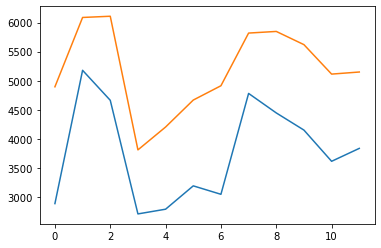

In [99]:
plt.plot(get_loc_sum(WH_max_nmf, WH_index_nmf))
plt.plot(get_loc_sum(WH_max_mmf_w0, WH_index_nmf_w0))

In [104]:
print(kstest(ct_pop, get_loc_sum(WH_max_nmf, WH_index_nmf)))
print(kstest(ct_pop, get_loc_sum(WH_max_mmf_w0, WH_index_nmf_w0)))

KstestResult(statistic=0.5, pvalue=0.09954677170991616)
KstestResult(statistic=0.3333333333333333, pvalue=0.5360977695073805)


### NMF with Zero (Test)

In [64]:
from sklearn.metrics import accuracy_score

In [ ]:
# C:\Users\Yiran\OneDrive - UW\Simulation

In [15]:
basepath = "C:\\Users\\Yiran\\OneDrive - UW\\Simulation\\"
gt_file = os.path.join(basepath, "df2matrix_smartphone_gt_1min.csv")
obs_file = os.path.join(basepath, "df2matrix_smartphone_288.csv")
zero_file = os.path.join(basepath, 'zero_index_sparse_5min.csv')

In [30]:
gt_df = pd.read_csv(gt_file)
gt_df.head(3)

,time_idx,person_idx,taz_idx
0,0,0,146
1,1,0,146
2,2,0,146


In [31]:
gt_df['time_idx_new'] = gt_df['time_idx']//5

In [37]:
def get2d3dmatrix(filepath, prefix, time_interval, save=False, return_3d=False, return_dim=False):
    print(f'load file [{filepath}]')
    #df2matrix.columns = ['person_idx','time_idx','taz_idx','obs']
    df2matrix = read_file(filepath)
    df2matrix['time_idx_new'] = df2matrix['time_idx']//time_interval
    
    person_ids = df2matrix.person_idx.unique()
    time_ids = df2matrix.time_idx_new.unique()
    taz_ids = df2matrix.taz_idx.unique()

    matrix_3d = np.zeros((len(person_ids), len(time_ids), len(taz_ids)))
    print(matrix_3d.shape)

    for i, j, k in df2matrix[['person_idx','time_idx_new','taz_idx']].values:
        matrix_3d[i, j, k] = 1

    #matrix_2d = df2matrix.p
    #person_idx = df2matrix['person']
    matrix_2d = matrix_3d.reshape(len(person_ids), len(time_ids)*len(taz_ids))
    
    if save == True:
        #pd.DataFrame(matrix_3d).to_csv(f'matrix_3d_{prefix}.csv', index=False, header=False)
        pd.DataFrame(matrix_2d).to_csv(f'matrix_2d_{prefix}.csv', index=False, header=False)
    if return_3d:
        return matrix_3d
    if return_dim:
        return matrix_2d, len(person_ids), len(time_ids), len(taz_ids)
    
    return matrix_2d

def read_file(filepath):
    file = pd.read_csv(filepath)
    return file

In [17]:
input_mx, person_len, time_len, taz_len = get2d3dmatrix(obs_file, '', return_dim=True)
zero_mx = get2d3dmatrix(zero_file, '', 1)

load file [C:\Users\Yiran\OneDrive - UW\Simulation\df2matrix_smartphone_288.csv]
(10406, 288, 168)
load file [C:\Users\Yiran\OneDrive - UW\Simulation\zero_index_sparse_5min.csv]
(10406, 288, 168)


In [38]:
gt_mx = get2d3dmatrix(gt_file, '', 5)

load file [C:\Users\Yiran\OneDrive - UW\Simulation\df2matrix_smartphone_gt_1min.csv]
(10406, 288, 168)


In [24]:
#begin = time.time()
para_lst = [300, 0.01, 0.01, 0.1, 0.1]

model = NMF_w0(n_components=para_lst[0], init='nndsvd', random_state=0,
                   alpha_W = para_lst[1], alpha_H = para_lst[2],
                   l1_ratio = para_lst[3], zero_weight=para_lst[4], 
                   beta_loss='kullback-leibler',
                   solver="zero")
W = model.fit_transform_w0(input_mx, zero_mx)
H = model.components_
WH = np.dot(W, H)

#end = time.time()
#print(f"Total runtime of the program is {end - begin}")

#print(mean_squared_error(test_matrice_reverse, WH, squared=False))
#WH_max_mmf_w0, WH_index_nmf_w0 = get_pred_dt(WH, 288)


In [26]:
WH.shape

(10406, 48384)

In [28]:
gt_mx.shape

(10406, 241920)

In [39]:
rmse_orig = mean_squared_error(input_mx, WH, squared=False)
rmse_gt = mean_squared_error(gt_mx, WH, squared=False)

#WH_3d = WH.reshape((person_len, time_len, taz_len))


In [41]:
rmse_orig

0.016219803332316738

In [42]:
rmse_gt

0.04906246662524457

In [44]:
WH_reshape = WH.reshape((person_len, time_len, taz_len ))

In [67]:
#print(np.max(WH_reshape), np.min(WH_reshape))
#0.20517641710319515 0.0

#compare the 0 and 1
threshold = 0.01
WH_01 = np.zeros(WH.shape)
WH_01[np.where(WH>=threshold)] = 1
print(np.count_nonzero(input_mx), np.count_nonzero(WH_01), np.count_nonzero(gt_mx))

374834 3855940 3104059


In [66]:
rmse_orig_01 = mean_squared_error(input_mx, WH_01, squared=False)
rmse_gt_01 = mean_squared_error(gt_mx, WH_01, squared=False)

print(rmse_orig_01, rmse_gt_01)
accuracy_ori = accuracy_score(input_mx.flatten(), WH_01.flatten())
accuracy_gt = accuracy_score(gt_mx.flatten(), WH_01.flatten())
print(accuracy_ori, accuracy_gt)


0.04460897421959414 0.05577546785380762
0.9928723441375397 0.9945941767385676


In [77]:
# Get locations where value == 1
origin_pos = set(zip(*np.where(input_mx == 1)))  # Ground truth positives
gt_pos = set(zip(*np.where(gt_mx == 1)))
pred_pos = set(zip(*np.where(WH_01 == 1)))      # Predicted positives

# Correct predictions (True Positives)
correct_pos_ori = origin_pos & pred_pos
correct_pos_gt = gt_pos & pred_pos

print(len(correct_pos_ori), len(correct_pos_gt))

321057 2119127


In [90]:
for threshold in check_threshold:
    WH_01 = np.zeros(WH.shape)
    WH_01[np.where(WH>=threshold)] = 1
    WH_test = np.zeros(WH.shape)
    WH_test[np.where(input_mx>0)] = 1
    WH_test[np.where(WH>=threshold)] = 1
    print(threshold, np.count_nonzero(WH_01), np.count_nonzero(WH_test))

0.01 3855940 3909717
0.02 2715558 3909717
0.03 1963894 3909717
0.04 1364167 3909717
0.05 890427 3909717
0.060000000000000005 555057 3909717
0.06999999999999999 337992 3909717
0.08 205372 3909717
0.09 124543 3909717
0.09999999999999999 75041 3909717
0.11 44316 3909717
0.12 25151 3909717
0.13 13542 3909717
0.14 6947 3909717
0.15000000000000002 3153 3909717
0.16 1317 3909717
0.17 458 3909717
0.18000000000000002 120 3909717
0.19 36 3909717
0.2 5 3909717


In [87]:
check_threshold = np.arange(0.01, 0.21, 0.01)
impute_accur = {}
for threshold in check_threshold:
    WH_miss_impute = input_mx
    WH_miss_impute[np.where(WH>=threshold)] = 1
    
    rmse_gt_impute = mean_squared_error(gt_mx, WH_miss_impute, squared=False)
    impute_accur[threshold] = [rmse_gt_impute, np.count_nonzero(WH_miss_impute)]
    

impute_accur


{0.01: [0.055448579906276295, 3909717],
 0.02: [0.055448579906276295, 3909717],
 0.03: [0.055448579906276295, 3909717],
 0.04: [0.055448579906276295, 3909717],
 0.05: [0.055448579906276295, 3909717],
 0.060000000000000005: [0.055448579906276295, 3909717],
 0.06999999999999999: [0.055448579906276295, 3909717],
 0.08: [0.055448579906276295, 3909717],
 0.09: [0.055448579906276295, 3909717],
 0.09999999999999999: [0.055448579906276295, 3909717],
 0.11: [0.055448579906276295, 3909717],
 0.12: [0.055448579906276295, 3909717],
 0.13: [0.055448579906276295, 3909717],
 0.14: [0.055448579906276295, 3909717],
 0.15000000000000002: [0.055448579906276295, 3909717],
 0.16: [0.055448579906276295, 3909717],
 0.17: [0.055448579906276295, 3909717],
 0.18000000000000002: [0.055448579906276295, 3909717],
 0.19: [0.055448579906276295, 3909717],
 0.2: [0.055448579906276295, 3909717]}

In [93]:
np.count_nonzero(zero_mx)

31387094

In [92]:
np.count_nonzero(WH[np.where(zero_mx>0)])

20512822

In [94]:
np.max(WH[np.where(zero_mx>0)])

0.10297754618003799

In [ ]:
with open(("C:\\Users\\Yiran\\OneDrive - UW\\Simulation\\result_remotePC_impute_check.txt", 'a') as f:
    f.write(f"paralist = {para_lst}\n')
    for ky, val in impute_accur.items():
        f.write(f"{ky}, {val[0]}, {val[1]}\n")
f.close()
    

In [40]:
with open("C:\\Users\\Yiran\\OneDrive - UW\\Simulation\\result_remotePC.txt", 'a') as f:
    f.write(f"paralist = {para_lst}\n')
    f.write(f"RMSE, Origin, {rmse_orig}\n")
    f.write(f"RMSE, GT, {rmse_gt}\n")
    f.write(f"RMSE01, Origin, {rmse_orig_01}, threshold={threshold}\n")
    f.write(f"RMSE01, GT, {rmse_gt_01}\n, threshold={threshold}")
    f.write('\n')
f.close()

In [ ]:
WH_max_mmf_w0, WH_index_nmf_w0 = get_pred_dt(WH, 288)

In [84]:
begin = time.time()
para_lst = [300, 0.01, 0.01, 0.1, 0.1]

model = NMF_w0(n_components=para_lst[0], init='nndsvd', random_state=0,
                   alpha_W = para_lst[1], alpha_H = para_lst[2],
                   l1_ratio = para_lst[3], zero_weight=para_lst[4], 
                   beta_loss='kullback-leibler',
                   solver="zero")
W = model.fit_transform_w0(test_matrice_reverse, Zero_index)
H = model.components_
WH = np.dot(W, H)

end = time.time()
print(f"Total runtime of the program is {end - begin}")

print(mean_squared_error(test_matrice_reverse, WH, squared=False))
WH_max_mmf_w0, WH_index_nmf_w0 = get_pred_dt(WH, 288)

Total runtime of the program is 430.3880932331085
0.05112148040192963


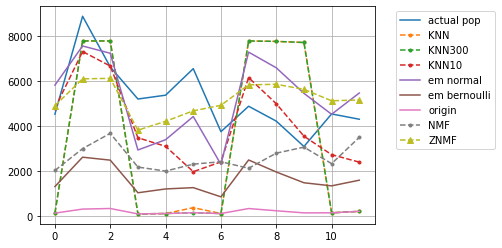

In [85]:
plt.plot(ct_pop, label='actual pop')
plt.plot(get_loc_sum(knn_max, knn_index), label='KNN',
        linestyle='dashed', marker='.')
plt.plot(get_loc_sum(knn_max300, knn_index300), label='KNN300',
        linestyle='dashed', marker='.')
plt.plot(get_loc_sum(knn_max10, knn_index10), label='KNN10',
        linestyle='dashed', marker='.')
plt.plot(get_loc_sum(em_max, em_index), label='em normal')
plt.plot(get_loc_sum(em_ber_max, em_ber_index), label='em bernoulli')
plt.plot(get_loc_sum(ori_max, ori_index), label='origin')
plt.plot(get_loc_sum(WH_max_nmf, WH_index_nmf), label='NMF',
        linestyle='dashed', marker='.')
plt.plot(get_loc_sum(WH_max_mmf_w0, WH_index_nmf_w0), label='ZNMF',
        linestyle='dashed', marker='^')

plt.grid()
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')


In [66]:
get_loc_sum(knn_max300, knn_index300)

array([ 133., 7767., 7766.,   98.,  115.,  151.,  115., 7766., 7747.,
       7698.,  147.,  212.])

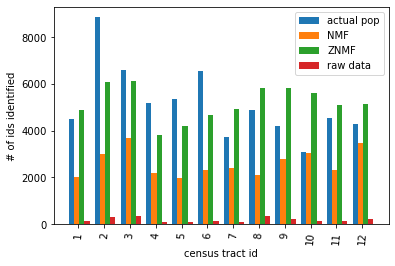

In [67]:
X = np.arange(1, 13)
ind = np.arange(len(X))
width = 0.2

bar1 = plt.bar(ind-width, ct_pop, width)
bar2 = plt.bar(ind, get_loc_sum(WH_max_nmf, WH_index_nmf), width)
bar3 = plt.bar(ind+width, get_loc_sum(WH_max_mmf_w0, WH_index_nmf_w0), width)
bar4 = plt.bar(ind+width*2, get_loc_sum(ori_max, ori_index), width)

plt.ylabel('# of ids identified')
plt.xlabel('census tract id')

plt.xticks(ind+width/3, X, rotation=85)
plt.legend((bar1, bar2, bar3,bar4), ('actual pop', 'NMF', 'ZNMF', 'raw data'))
plt.show()

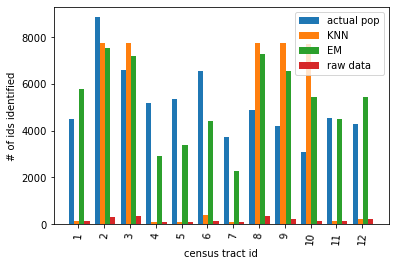

In [68]:
X = np.arange(1, 13)
ind = np.arange(len(X))
width = 0.2

bar1 = plt.bar(ind-width, ct_pop, width)
bar2 = plt.bar(ind, get_loc_sum(knn_max, knn_index), width)
bar3 = plt.bar(ind+width, get_loc_sum(em_max, em_index), width)
bar4 = plt.bar(ind+width*2, get_loc_sum(ori_max, ori_index), width)

plt.ylabel('# of ids identified')
plt.xlabel('census tract id')

plt.xticks(ind+width/3, X, rotation=85)
plt.legend((bar1, bar2, bar3,bar4), ('actual pop', 'KNN', 'EM', 'raw data'))
plt.show()

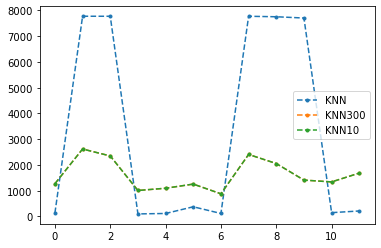

In [38]:
plt.plot(get_loc_sum(knn_max, knn_index), label='KNN',
        linestyle='dashed', marker='.')
plt.plot(get_loc_sum(knn_max300, knn_index300), label='KNN300',
        linestyle='dashed', marker='.')
plt.plot(get_loc_sum(knn_max10, knn_index10), label='KNN10',
        linestyle='dashed', marker='.')

plt.legend()

### NMF with zero loss

In [11]:
result_para_dict_w0 = {'ori':{'rmse_predvssim':[],                            
                                'rmse_predvszero':[],
                                'per of zero val':[],
                                'per of match':[],
                                'per of missings mitigated':[]},
                       'mor':{'rmse_predvssim':[],                            
                                'rmse_predvszero':[],
                                'per of zero val':[],
                                'per of match':[],
                                'per of missings mitigated':[]},
                       'noon':{'rmse_predvssim':[],                            
                                'rmse_predvszero':[],
                                'per of zero val':[],
                                'per of match':[],
                                'per of missings mitigated':[]},
                       'eve':{'rmse_predvssim':[],                            
                                'rmse_predvszero':[],
                                'per of zero val':[],
                                'per of match':[],
                                'per of missings mitigated':[]},
                       'other':{'rmse_predvssim':[],                            
                                'rmse_predvszero':[],
                                'per of zero val':[],
                                'per of match':[],
                                'per of missings mitigated':[]}
              }

In [131]:
k_nmf_w0_r = generate_paralst(list(np.array(range(1, 21))*10), [0], [0.01, 0.01, 0.5, 0.1], 5)
k_nmf_100_w0_r = generate_paralst(list(np.array(range(1, 11))*100), [0], [0.01, 0.01,0.5, 0.1], 5)

In [132]:
k_nmf_100_w0_r

[[100, 0.01, 0.01, 0.1, 0.1],
 [200, 0.01, 0.01, 0.1, 0.1],
 [300, 0.01, 0.01, 0.1, 0.1],
 [400, 0.01, 0.01, 0.1, 0.1],
 [500, 0.01, 0.01, 0.1, 0.1],
 [600, 0.01, 0.01, 0.1, 0.1],
 [700, 0.01, 0.01, 0.1, 0.1],
 [800, 0.01, 0.01, 0.1, 0.1],
 [900, 0.01, 0.01, 0.1, 0.1],
 [1000, 0.01, 0.01, 0.1, 0.1]]

In [162]:
#'sim_t', k_nmf_100, 0.05, 288, result_para_dict, 'NMF'
#fit_model_get_para_sensitive_w0(fcd_dt, para_lst, missing_info, missing_val, 
#time_interval, result_para_dict, Zero_index)
test_k_nmf = fit_model_get_para_sensitive_w0(test_matrice_reverse, k_nmf, missing_info, 
                                             0.0, 288, result_para_dict_w0,
                                             Zero_index)

RMSE, data with missing rate>=0.0, para=[10, 0, 0, 0, 0.5], 0.1540784040693739
RMSE, zero, data with missing rate>=0.0, para=[10, 0, 0, 0, 0.5], 0.15603245001695815
zero_val, para=[10, 0, 0, 0, 0.5], 0.9997932114265458
matched % compared with raw dt 0.11566206028353576
% of missings mitigated 0.9983752676713653
RMSE, data with missing rate>=0.0, para=[10, 0, 0, 0, 0.5],mor, 0.1714853040351072
RMSE, zero, data with missing rate>=0.0, para=[10, 0, 0, 0, 0.5],mor, 0.175372940487062
zero_val, para=[10, 0, 0, 0, 0.5], 0.9946467396269161
matched % compared with raw dtmor, 0.6861150451339714
% of missings mitigatedmor, 0.9951575781054167
RMSE, data with missing rate>=0.0, para=[10, 0, 0, 0, 0.5],noon, 0.18805964492427668
RMSE, zero, data with missing rate>=0.0, para=[10, 0, 0, 0, 0.5],noon, 0.19271355101230908
zero_val, para=[10, 0, 0, 0, 0.5], 0.9989190421700228
matched % compared with raw dtnoon, 0.3731505622076306
% of missings mitigatednoon, 0.9969854449838361
RMSE, data with missing rate

matched % compared with raw dt 0.11500668783886242
% of missings mitigated 0.9993130057111451
RMSE, data with missing rate>=0.0, para=[60, 0, 0, 0, 0.5],mor, 0.1507010162234948
RMSE, zero, data with missing rate>=0.0, para=[60, 0, 0, 0, 0.5],mor, 0.1546547400234954
zero_val, para=[60, 0, 0, 0, 0.5], 0.9965103319752252
matched % compared with raw dtmor, 0.7003812425790024
% of missings mitigatedmor, 0.998949592370221
RMSE, data with missing rate>=0.0, para=[60, 0, 0, 0, 0.5],noon, 0.17789291897209403
RMSE, zero, data with missing rate>=0.0, para=[60, 0, 0, 0, 0.5],noon, 0.18322542190863406
zero_val, para=[60, 0, 0, 0, 0.5], 0.9987501425090889
matched % compared with raw dtnoon, 0.3871963649628771
% of missings mitigatednoon, 0.9989276162879767
RMSE, data with missing rate>=0.0, para=[60, 0, 0, 0, 0.5],eve, 0.20115415931398736
RMSE, zero, data with missing rate>=0.0, para=[60, 0, 0, 0, 0.5],eve, 0.20478707229461
zero_val, para=[60, 0, 0, 0, 0.5], 0.9943187326701957
matched % compared wit

matched % compared with raw dt 0.11866219976252808
% of missings mitigated 0.9995536305308601
RMSE, data with missing rate>=0.0, para=[110, 0, 0, 0, 0.5],mor, 0.1264440479361852
RMSE, zero, data with missing rate>=0.0, para=[110, 0, 0, 0, 0.5],mor, 0.1301287223532221
zero_val, para=[110, 0, 0, 0, 0.5], 0.9969488242924743
matched % compared with raw dtmor, 0.700413430038768
% of missings mitigatedmor, 0.9991166077738516
RMSE, data with missing rate>=0.0, para=[110, 0, 0, 0, 0.5],noon, 0.1694121588413073
RMSE, zero, data with missing rate>=0.0, para=[110, 0, 0, 0, 0.5],noon, 0.17480224558917398
zero_val, para=[110, 0, 0, 0, 0.5], 0.9987205850684254
matched % compared with raw dtnoon, 0.3951399618042144
% of missings mitigatednoon, 0.9992505593089182
RMSE, data with missing rate>=0.0, para=[110, 0, 0, 0, 0.5],eve, 0.16999787165314623
RMSE, zero, data with missing rate>=0.0, para=[110, 0, 0, 0, 0.5],eve, 0.17368360581647677
zero_val, para=[110, 0, 0, 0, 0.5], 0.9945901925426095
matched % c

matched % compared with raw dt 0.11327392958814357
% of missings mitigated 0.9995462598196937
RMSE, data with missing rate>=0.0, para=[160, 0, 0, 0, 0.5],mor, 0.10092920768015595
RMSE, zero, data with missing rate>=0.0, para=[160, 0, 0, 0, 0.5],mor, 0.10374865445250693
zero_val, para=[160, 0, 0, 0, 0.5], 0.9975334807154733
matched % compared with raw dtmor, 0.700334749581563
% of missings mitigatedmor, 0.9994032700799618
RMSE, data with missing rate>=0.0, para=[160, 0, 0, 0, 0.5],noon, 0.1613866337183824
RMSE, zero, data with missing rate>=0.0, para=[160, 0, 0, 0, 0.5],noon, 0.166654251392325
zero_val, para=[160, 0, 0, 0, 0.5], 0.9985432404244449
matched % compared with raw dtnoon, 0.3949642719196601
% of missings mitigatednoon, 0.9993039762021927
RMSE, data with missing rate>=0.0, para=[160, 0, 0, 0, 0.5],eve, 0.13483407133000214
RMSE, zero, data with missing rate>=0.0, para=[160, 0, 0, 0, 0.5],eve, 0.1374404397093385
zero_val, para=[160, 0, 0, 0, 0.5], 0.9961413918135459
matched % co

RMSE, data with missing rate>=0.0, para=[100, 0, 0, 0, 0.5], 0.14565891035977735
RMSE, zero, data with missing rate>=0.0, para=[100, 0, 0, 0, 0.5], 0.14982802830707698
zero_val, para=[100, 0, 0, 0, 0.5], 0.9991592112947464
matched % compared with raw dt 0.1179446876385849
% of missings mitigated 0.9995240909325892
RMSE, data with missing rate>=0.0, para=[100, 0, 0, 0, 0.5],mor, 0.13196505412388856
RMSE, zero, data with missing rate>=0.0, para=[100, 0, 0, 0, 0.5],mor, 0.13571456345050345
zero_val, para=[100, 0, 0, 0, 0.5], 0.996199733250507
matched % compared with raw dtmor, 0.6954243737750884
% of missings mitigatedmor, 0.9987905545835633
RMSE, data with missing rate>=0.0, para=[100, 0, 0, 0, 0.5],noon, 0.17115304391412633
RMSE, zero, data with missing rate>=0.0, para=[100, 0, 0, 0, 0.5],noon, 0.17645125922905022
zero_val, para=[100, 0, 0, 0, 0.5], 0.9985727978651083
matched % compared with raw dtnoon, 0.39601841122698594
% of missings mitigatednoon, 0.9992183822288542
RMSE, data with 

RMSE, data with missing rate>=0.0, para=[600, 0, 0, 0, 0.5], 0.11834973415279187
RMSE, zero, data with missing rate>=0.0, para=[600, 0, 0, 0, 0.5], 0.12253596205051485
zero_val, para=[600, 0, 0, 0, 0.5], 0.9990024155632262
matched % compared with raw dt 0.1335390648470023
% of missings mitigated 0.999801876293415
RMSE, data with missing rate>=0.0, para=[600, 0, 0, 0, 0.5],mor, 0.00797855126586425
RMSE, zero, data with missing rate>=0.0, para=[600, 0, 0, 0, 0.5],mor, 0.007965272266880432
zero_val, para=[600, 0, 0, 0, 0.5], 0.9999086474339064
matched % compared with raw dtmor, 0.6985537101411956
% of missings mitigatedmor, 0.9999288154897494
RMSE, data with missing rate>=0.0, para=[600, 0, 0, 0, 0.5],noon, 0.08720418960594464
RMSE, zero, data with missing rate>=0.0, para=[600, 0, 0, 0, 0.5],noon, 0.0893237194658235
zero_val, para=[600, 0, 0, 0, 0.5], 0.9990794968479101
matched % compared with raw dtnoon, 0.4052883996395005
% of missings mitigatednoon, 0.9998308662354883
RMSE, data with m

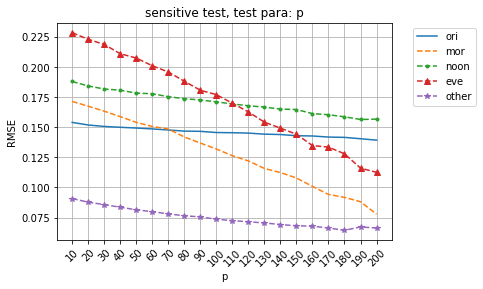

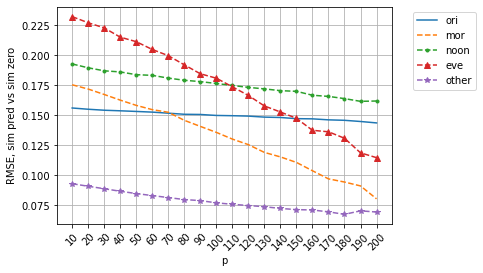

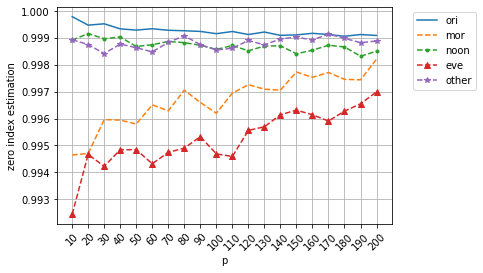

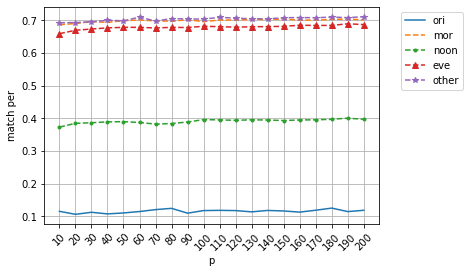

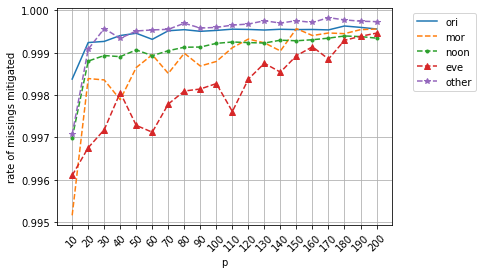

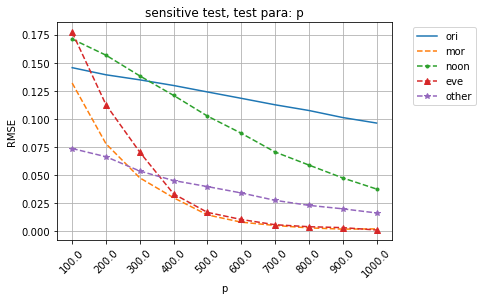

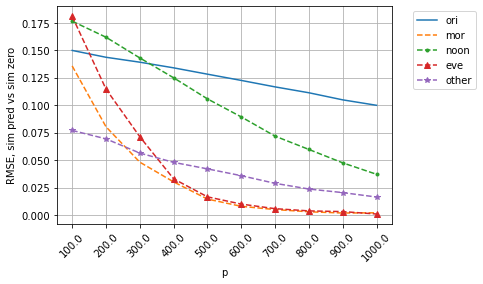

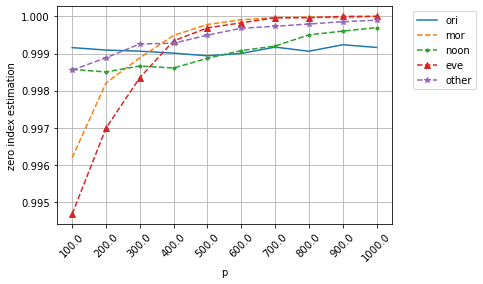

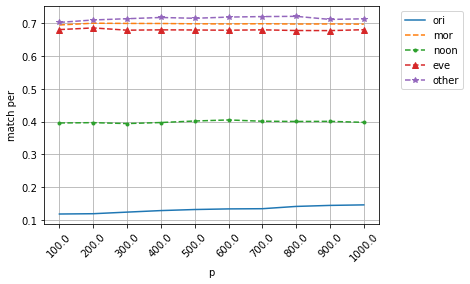

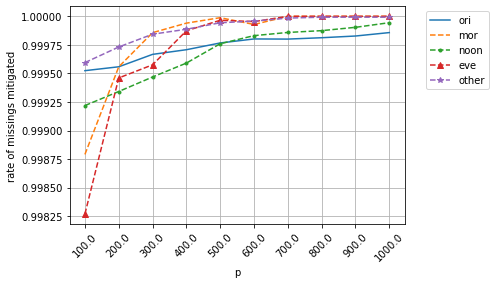

In [290]:
idx = plot_paras_sensitive_w0(test_k_nmf, k_nmf, 'p', 0, 1)
idx = plot_paras_sensitive_w0(test_k_nmf_100, k_nmf_100, 'p', 0, idx)

In [140]:
np

array([0.25, 0.5 , 0.75, 1.  , 1.25, 1.5 , 1.75, 2.  , 2.25, 2.5 , 2.75,
       3.  , 3.25, 3.5 , 3.75, 4.  , 4.25, 4.5 , 4.75, 5.  ])

RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1], 0.047745522059121935
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1], 0.05407004072361999
zero_val, para=[200, 0, 0, 0, 0.1], 0.24178810761186464
matched % compared with raw dt 0.12228060669785273
% of missings mitigated 0.9996969491694625
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1],mor, 0.03827251947260701
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1],mor, 0.04542111517321639
zero_val, para=[200, 0, 0, 0, 0.1], 0.47112345385781884
matched % compared with raw dtmor, 0.7066041514670329
% of missings mitigatedmor, 0.999658690590831
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1],noon, 0.05738505346843622
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1],noon, 0.06671672215760087
zero_val, para=[200, 0, 0, 0, 0.1], 0.247214211217471
matched % compared with raw dtnoon, 0.39869801725247844
% of missings mitigatednoon, 0.999458012713282
RMSE, data wit

C:\Users\Yiran\anaconda3\lib\site-packages\sklearn\utils\extmath.py:153: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
C:\Users\Yiran\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:961: RuntimeWarning: invalid value encountered in true_divide
  numerator /= denominator


Error, fitting data failed
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 15],mor, 0.041603331634441486
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 15],mor, 0.04997919451647821
zero_val, para=[200, 0, 0, 0, 15], 0.49222589662543625
matched % compared with raw dtmor, 0.709275710627584
% of missings mitigatedmor, 0.9995694427358839
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 15],noon, 0.06324811162292167
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 15],noon, 0.0729794783666934
zero_val, para=[200, 0, 0, 0, 15], 0.2878092447229412
matched % compared with raw dtnoon, 0.39618605424659886
% of missings mitigatednoon, 0.999502468776584
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 15],eve, 0.045711832242250824
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 15],eve, 0.055211267907679606
zero_val, para=[200, 0, 0, 0, 15], 0.41961879277916736
matched % compared with raw dteve, 0.6876823189685298
% of missings mitigatedeve

C:\Users\Yiran\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:807: RuntimeWarning: overflow encountered in true_divide
  np.divide(X_data, WH_safe_X_data, out=WH_safe_X_data)
C:\Users\Yiran\anaconda3\lib\site-packages\sklearn\utils\extmath.py:153: RuntimeWarning: overflow encountered in matmul
  ret = a @ b


Error, fitting data failed
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 20],mor, 0.04216998221888728
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 20],mor, 0.050628142486213085
zero_val, para=[200, 0, 0, 0, 20], 0.4983830595801436
matched % compared with raw dtmor, 0.7104201536414746
% of missings mitigatedmor, 0.9995924416450537
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 20],noon, 0.0637902344644813
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 20],noon, 0.07335336145110015
zero_val, para=[200, 0, 0, 0, 20], 0.29490303048216626
matched % compared with raw dtnoon, 0.39644221278056735
% of missings mitigatednoon, 0.9995089238098624
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 20],eve, 0.04621584790585452
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 20],eve, 0.05586140688887411
zero_val, para=[200, 0, 0, 0, 20], 0.4225854613848331
matched % compared with raw dteve, 0.6882892824955398
% of missings mitigatedeve,

...

C:\Users\Yiran\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:961: RuntimeWarning: invalid value encountered in true_divide
  numerator /= denominator


Error, fitting data failed
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],mor, 0.04328131591277071
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],mor, 0.05246546137642996
zero_val, para=[200, 0, 0, 0, 45], 0.5118118867959001
matched % compared with raw dtmor, 0.7134064346308456
% of missings mitigatedmor, 0.9995881949210706
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],noon, 0.06505024579128627
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],noon, 0.0740530608553133
zero_val, para=[200, 0, 0, 0, 45], 0.3105135816439849
matched % compared with raw dtnoon, 0.3979603879661817
% of missings mitigatednoon, 0.9995277344620183
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],eve, 0.04768779313949298
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],eve, 0.058024274646109424
zero_val, para=[200, 0, 0, 0, 45], 0.4307680375390224
matched % compared with raw dteve, 0.6905883867645165
% of missings mitigatedeve, 0

C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:947: RuntimeWarning: overflow encountered in multiply
  zero_loss = np.sum(l_zero*np.dot(W.T, np.multiply(np.dot(W, H), zero_reg)), axis=1)
C:\Users\Yiran\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:1023: RuntimeWarning: invalid value encountered in multiply
  H *= delta_H


Error, fitting data failed


6

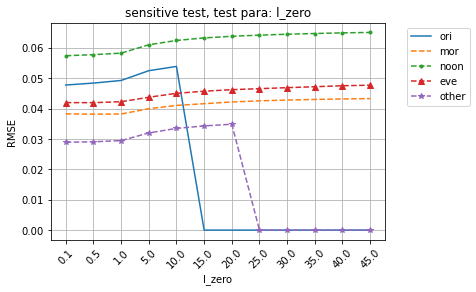

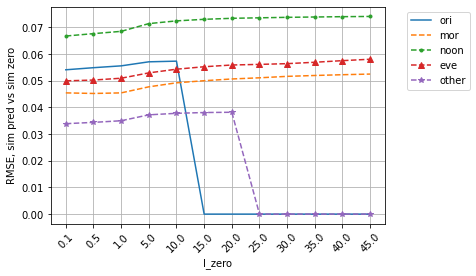

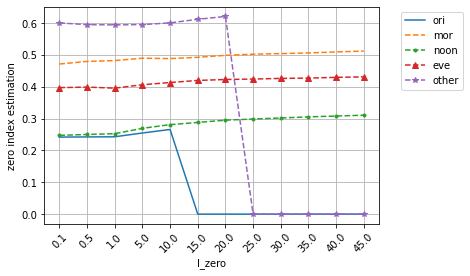

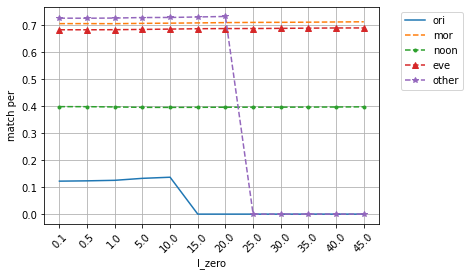

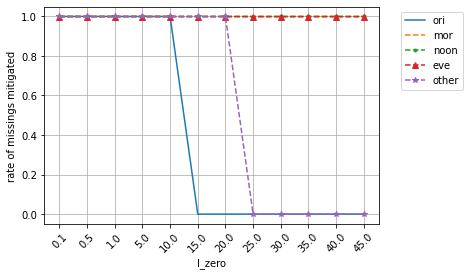

In [152]:
#lzero = generate_paralst(list(np.round(np.array(range(1, 22))*0.5,1)), [4], [300, 0,0,0], 5)
lzero = generate_paralst([0.1, 0.5, 1, 5, 10, 15, 20, 25, 30, 35, 40, 45], [4], [200, 0,0,0], 5)

test_lzero= fit_model_get_para_sensitive_w0(test_matrice_reverse, lzero, missing_info,
                                             0.0, 288, result_para_dict_w0,
                                             Zero_index)

plot_paras_sensitive_w0(test_lzero, lzero, 'l_zero', 4, 1)

RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1], 0.047745522059121935
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1], 0.05407004072361999
zero_val, para=[200, 0, 0, 0, 0.1], 0.24178810761186464
matched % compared with raw dt 0.12228060669785273
% of missings mitigated 0.9996969491694625
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1],mor, 0.03827251947260701
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1],mor, 0.04542111517321639
zero_val, para=[200, 0, 0, 0, 0.1], 0.47112345385781884
matched % compared with raw dtmor, 0.7066041514670329
% of missings mitigatedmor, 0.999658690590831
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1],noon, 0.05738505346843622
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1],noon, 0.06671672215760087
zero_val, para=[200, 0, 0, 0, 0.1], 0.247214211217471
matched % compared with raw dtnoon, 0.39869801725247844
% of missings mitigatednoon, 0.999458012713282
RMSE, data wit

C:\Users\Yiran\anaconda3\lib\site-packages\sklearn\utils\extmath.py:153: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
C:\Users\Yiran\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:961: RuntimeWarning: invalid value encountered in true_divide
  numerator /= denominator


Error, fitting data failed
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 15],mor, 0.041603331634441486
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 15],mor, 0.04997919451647821
zero_val, para=[200, 0, 0, 0, 15], 0.49222589662543625
matched % compared with raw dtmor, 0.709275710627584
% of missings mitigatedmor, 0.9995694427358839
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 15],noon, 0.06324811162292167
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 15],noon, 0.0729794783666934
zero_val, para=[200, 0, 0, 0, 15], 0.2878092447229412
matched % compared with raw dtnoon, 0.39618605424659886
% of missings mitigatednoon, 0.999502468776584
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 15],eve, 0.045711832242250824
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 15],eve, 0.055211267907679606
zero_val, para=[200, 0, 0, 0, 15], 0.41961879277916736
matched % compared with raw dteve, 0.6876823189685298
% of missings mitigatedeve

C:\Users\Yiran\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:807: RuntimeWarning: overflow encountered in true_divide
  np.divide(X_data, WH_safe_X_data, out=WH_safe_X_data)
C:\Users\Yiran\anaconda3\lib\site-packages\sklearn\utils\extmath.py:153: RuntimeWarning: overflow encountered in matmul
  ret = a @ b


Error, fitting data failed
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 20],mor, 0.04216998221888728
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 20],mor, 0.050628142486213085
zero_val, para=[200, 0, 0, 0, 20], 0.4983830595801436
matched % compared with raw dtmor, 0.7104201536414746
% of missings mitigatedmor, 0.9995924416450537
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 20],noon, 0.0637902344644813
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 20],noon, 0.07335336145110015
zero_val, para=[200, 0, 0, 0, 20], 0.29490303048216626
matched % compared with raw dtnoon, 0.39644221278056735
% of missings mitigatednoon, 0.9995089238098624
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 20],eve, 0.04621584790585452
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 20],eve, 0.05586140688887411
zero_val, para=[200, 0, 0, 0, 20], 0.4225854613848331
matched % compared with raw dteve, 0.6882892824955398
% of missings mitigatedeve,

...

C:\Users\Yiran\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:961: RuntimeWarning: invalid value encountered in true_divide
  numerator /= denominator


Error, fitting data failed
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],mor, 0.04328131591277071
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],mor, 0.05246546137642996
zero_val, para=[200, 0, 0, 0, 45], 0.5118118867959001
matched % compared with raw dtmor, 0.7134064346308456
% of missings mitigatedmor, 0.9995881949210706
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],noon, 0.06505024579128627
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],noon, 0.0740530608553133
zero_val, para=[200, 0, 0, 0, 45], 0.3105135816439849
matched % compared with raw dtnoon, 0.3979603879661817
% of missings mitigatednoon, 0.9995277344620183
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],eve, 0.04768779313949298
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],eve, 0.058024274646109424
zero_val, para=[200, 0, 0, 0, 45], 0.4307680375390224
matched % compared with raw dteve, 0.6905883867645165
% of missings mitigatedeve, 0

C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:947: RuntimeWarning: overflow encountered in multiply
  zero_loss = np.sum(l_zero*np.dot(W.T, np.multiply(np.dot(W, H), zero_reg)), axis=1)
C:\Users\Yiran\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:1023: RuntimeWarning: invalid value encountered in multiply
  H *= delta_H


Error, fitting data failed


6

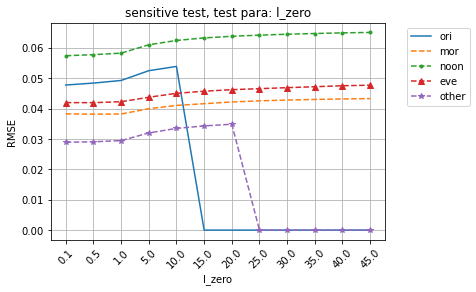

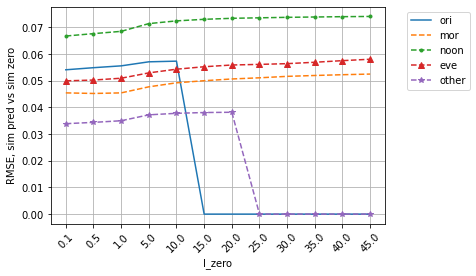

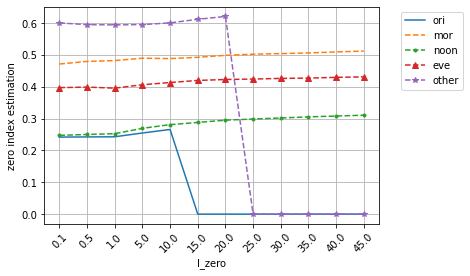

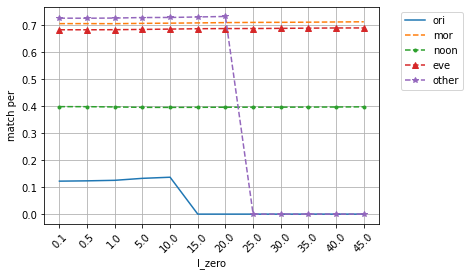

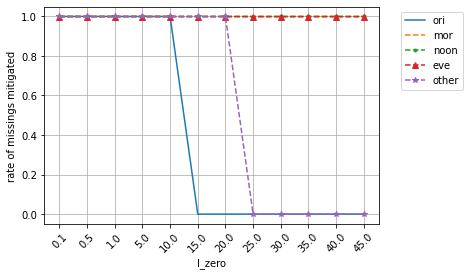

In [153]:
lzero_r = generate_paralst([0.1, 0.5, 1, 5, 10, 15, 20, 25, 30, 35, 40, 45], [4], [200, 0.01, 0.01, 0.5], 5)

test_lzero_r = fit_model_get_para_sensitive_w0(test_matrice_reverse, lzero, missing_info,
                                             0.0, 288, result_para_dict_w0,
                                             Zero_index, random_set)

plot_paras_sensitive_w0(test_lzero_r, lzero_r, 'l_zero', 4, 1)

RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1], 0.04610634695969203
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1], 0.052756828581720656
zero_val, para=[200, 0, 0, 0, 0.1], 0.17672696863858128
matched % compared with raw dt 0.10697502253122183
% of missings mitigated 0.9997421911449917
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1],mor, 0.028346593508652002
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1],mor, 0.03357970770192504
zero_val, para=[200, 0, 0, 0, 0.1], 0.35136023970913344
matched % compared with raw dtmor, 0.7035427664048753
% of missings mitigatedmor, 0.9997466613586189
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1],noon, 0.05265469587101876
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1],noon, 0.062174597829265994
zero_val, para=[200, 0, 0, 0, 0.1], 0.19875267600400293
matched % compared with raw dtnoon, 0.3960707158491052
% of missings mitigatednoon, 0.9995158879791433
RMSE, dat

RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 15], 0.05430003788451831
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 15], 0.05736476305440018
zero_val, para=[200, 0, 0, 0, 15], 0.27044536804957475
matched % compared with raw dt 0.12741227129021646
% of missings mitigated 0.9997207831596895
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 15],mor, 0.03537587717792735
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 15],mor, 0.039131192271214976
zero_val, para=[200, 0, 0, 0, 15], 0.37246268247675074
matched % compared with raw dtmor, 0.7024448163884239
% of missings mitigatedmor, 0.9998197115384615
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 15],noon, 0.06077128317147941
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 15],noon, 0.07208463349008815
zero_val, para=[200, 0, 0, 0, 15], 0.20604914135634878
matched % compared with raw dtnoon, 0.3915081434273207
% of missings mitigatednoon, 0.9995040896077019
RMSE, data with miss

C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:947: RuntimeWarning: overflow encountered in multiply
  zero_loss = np.sum(l_zero*np.dot(W.T, np.multiply(np.dot(W, H), zero_reg)), axis=1)
C:\Users\Yiran\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:961: RuntimeWarning: invalid value encountered in true_divide
  numerator /= denominator


Error, fitting data failed
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 25],mor, 0.03718798800791041
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 25],mor, 0.041248615190980234
zero_val, para=[200, 0, 0, 0, 25], 0.3747830376555278
matched % compared with raw dtmor, 0.7021658584037881
% of missings mitigatedmor, 0.9997958644539975
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 25],noon, 0.0621223515993983
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 25],noon, 0.0733561475853378
zero_val, para=[200, 0, 0, 0, 25], 0.21123436094702042
matched % compared with raw dtnoon, 0.39101192008926655
% of missings mitigatednoon, 0.9994912801900983
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 25],eve, 0.04060489650309048
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 25],eve, 0.045626576571640536
zero_val, para=[200, 0, 0, 0, 25], 0.2825509472010548
matched % compared with raw dteve, 0.6908274936084902
% of missings mitigatedeve,

C:\Users\Yiran\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Yiran\anaconda3\lib\site-packages\sklearn\utils\extmath.py:153: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
C:\Users\Yiran\anaconda3\lib\site-packages\sklearn\utils\extmath.py:153: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:851: RuntimeWarning: invalid value encountered in multiply
  zero_loss = np.sum(l_zero*np.dot(np.multiply(np.dot(W, H), zero_reg), H.T), axis=0)


...

C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:947: RuntimeWarning: overflow encountered in multiply
  zero_loss = np.sum(l_zero*np.dot(W.T, np.multiply(np.dot(W, H), zero_reg)), axis=1)
C:\Users\Yiran\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Yiran\anaconda3\lib\site-packages\sklearn\utils\extmath.py:153: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:1023: RuntimeWarning: invalid value encountered in multiply
  H *= delta_H
C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:851: RuntimeWarning: invalid value encountered in multiply
  zero_loss = np.sum(l_zero*np.dot(np.multiply(np.dot(W, H), zero_reg), H.T), axis=0)


Error, fitting data failed
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],mor, 0.039011919140280356
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],mor, 0.04440473446605032
zero_val, para=[200, 0, 0, 0, 45], 0.37896698518261374
matched % compared with raw dtmor, 0.7027452326795702
% of missings mitigatedmor, 0.9998074979546657
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],noon, 0.0634822426716551
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],noon, 0.07427222575530076
zero_val, para=[200, 0, 0, 0, 45], 0.21937110211251254
matched % compared with raw dtnoon, 0.3904821681472898
% of missings mitigatednoon, 0.9994895219989615
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],eve, 0.042894590644817474
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],eve, 0.04803460736499019
zero_val, para=[200, 0, 0, 0, 45], 0.2885812343668198
matched % compared with raw dteve, 0.6911622431900531
% of missings mitigatedeve

C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:947: RuntimeWarning: overflow encountered in multiply
  zero_loss = np.sum(l_zero*np.dot(W.T, np.multiply(np.dot(W, H), zero_reg)), axis=1)
C:\Users\Yiran\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Yiran\anaconda3\lib\site-packages\sklearn\utils\extmath.py:153: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
C:\Users\Yiran\anaconda3\lib\site-packages\sklearn\utils\extmath.py:153: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:851: RuntimeWarning: invalid value encountered in multiply
  zero_loss = np.sum(l_zero*np.dot(np.multiply(np.dot(W, H), zero_reg), H.T), axis=0)


Error, fitting data failed


6

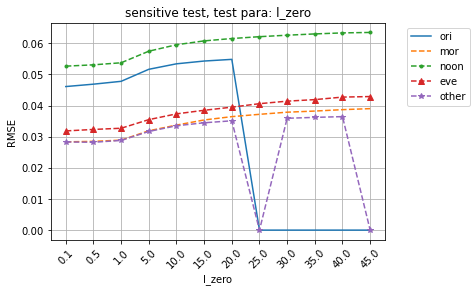

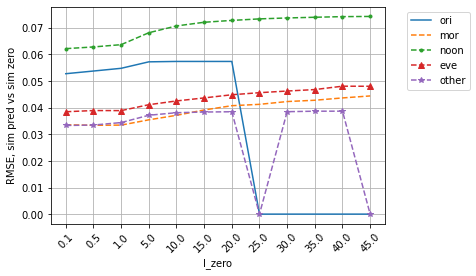

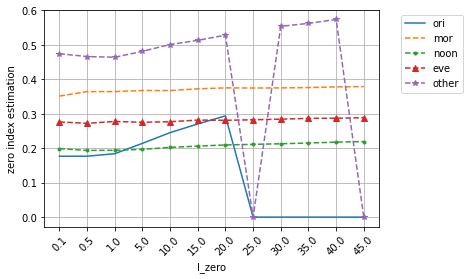

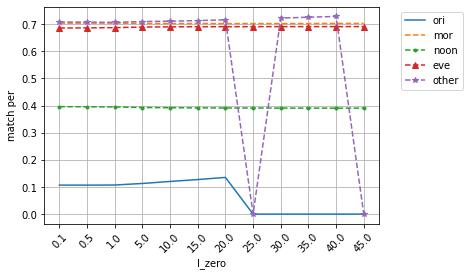

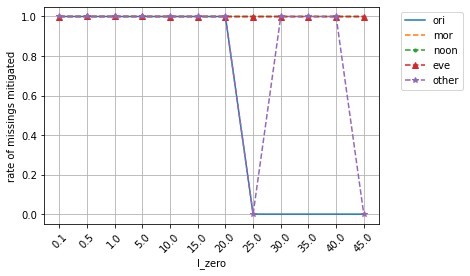

In [159]:
lzero = generate_paralst([0.1, 0.5, 1, 5, 10, 15, 20, 25, 30, 35, 40, 45], [4], [200, 0,0,0], 5)

test_lzero= fit_model_get_para_sensitive_w0(test_matrice_reverse, lzero, missing_info,
                                             0.0, 288, result_para_dict_w0,
                                             Zero_index, 'random')

plot_paras_sensitive_w0(test_lzero, lzero, 'l_zero', 4, 1)

RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1], 0.04610634695969203
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1], 0.052756828581720656
zero_val, para=[200, 0, 0, 0, 0.1], 0.17672696863858128
matched % compared with raw dt 0.10697502253122183
% of missings mitigated 0.9997421911449917
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1],mor, 0.028346593508652002
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1],mor, 0.03357970770192504
zero_val, para=[200, 0, 0, 0, 0.1], 0.35136023970913344
matched % compared with raw dtmor, 0.7035427664048753
% of missings mitigatedmor, 0.9997466613586189
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1],noon, 0.05265469587101876
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1],noon, 0.062174597829265994
zero_val, para=[200, 0, 0, 0, 0.1], 0.19875267600400293
matched % compared with raw dtnoon, 0.3960707158491052
% of missings mitigatednoon, 0.9995158879791433
RMSE, dat

RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 15], 0.05430003788451831
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 15], 0.05736476305440018
zero_val, para=[200, 0, 0, 0, 15], 0.27044536804957475
matched % compared with raw dt 0.12741227129021646
% of missings mitigated 0.9997207831596895
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 15],mor, 0.03537587717792735
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 15],mor, 0.039131192271214976
zero_val, para=[200, 0, 0, 0, 15], 0.37246268247675074
matched % compared with raw dtmor, 0.7024448163884239
% of missings mitigatedmor, 0.9998197115384615
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 15],noon, 0.06077128317147941
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 15],noon, 0.07208463349008815
zero_val, para=[200, 0, 0, 0, 15], 0.20604914135634878
matched % compared with raw dtnoon, 0.3915081434273207
% of missings mitigatednoon, 0.9995040896077019
RMSE, data with miss

C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:947: RuntimeWarning: overflow encountered in multiply
  zero_loss = np.sum(l_zero*np.dot(W.T, np.multiply(np.dot(W, H), zero_reg)), axis=1)
C:\Users\Yiran\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:961: RuntimeWarning: invalid value encountered in true_divide
  numerator /= denominator


Error, fitting data failed
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 25],mor, 0.03718798800791041
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 25],mor, 0.041248615190980234
zero_val, para=[200, 0, 0, 0, 25], 0.3747830376555278
matched % compared with raw dtmor, 0.7021658584037881
% of missings mitigatedmor, 0.9997958644539975
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 25],noon, 0.0621223515993983
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 25],noon, 0.0733561475853378
zero_val, para=[200, 0, 0, 0, 25], 0.21123436094702042
matched % compared with raw dtnoon, 0.39101192008926655
% of missings mitigatednoon, 0.9994912801900983
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 25],eve, 0.04060489650309048
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 25],eve, 0.045626576571640536
zero_val, para=[200, 0, 0, 0, 25], 0.2825509472010548
matched % compared with raw dteve, 0.6908274936084902
% of missings mitigatedeve,

C:\Users\Yiran\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Yiran\anaconda3\lib\site-packages\sklearn\utils\extmath.py:153: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
C:\Users\Yiran\anaconda3\lib\site-packages\sklearn\utils\extmath.py:153: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:851: RuntimeWarning: invalid value encountered in multiply
  zero_loss = np.sum(l_zero*np.dot(np.multiply(np.dot(W, H), zero_reg), H.T), axis=0)


...

C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:947: RuntimeWarning: overflow encountered in multiply
  zero_loss = np.sum(l_zero*np.dot(W.T, np.multiply(np.dot(W, H), zero_reg)), axis=1)
C:\Users\Yiran\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Yiran\anaconda3\lib\site-packages\sklearn\utils\extmath.py:153: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:1023: RuntimeWarning: invalid value encountered in multiply
  H *= delta_H
C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:851: RuntimeWarning: invalid value encountered in multiply
  zero_loss = np.sum(l_zero*np.dot(np.multiply(np.dot(W, H), zero_reg), H.T), axis=0)


Error, fitting data failed
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],mor, 0.039011919140280356
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],mor, 0.04440473446605032
zero_val, para=[200, 0, 0, 0, 45], 0.37896698518261374
matched % compared with raw dtmor, 0.7027452326795702
% of missings mitigatedmor, 0.9998074979546657
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],noon, 0.0634822426716551
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],noon, 0.07427222575530076
zero_val, para=[200, 0, 0, 0, 45], 0.21937110211251254
matched % compared with raw dtnoon, 0.3904821681472898
% of missings mitigatednoon, 0.9994895219989615
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],eve, 0.042894590644817474
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],eve, 0.04803460736499019
zero_val, para=[200, 0, 0, 0, 45], 0.2885812343668198
matched % compared with raw dteve, 0.6911622431900531
% of missings mitigatedeve

C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:947: RuntimeWarning: overflow encountered in multiply
  zero_loss = np.sum(l_zero*np.dot(W.T, np.multiply(np.dot(W, H), zero_reg)), axis=1)
C:\Users\Yiran\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Yiran\anaconda3\lib\site-packages\sklearn\utils\extmath.py:153: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
C:\Users\Yiran\anaconda3\lib\site-packages\sklearn\utils\extmath.py:153: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:851: RuntimeWarning: invalid value encountered in multiply
  zero_loss = np.sum(l_zero*np.dot(np.multiply(np.dot(W, H), zero_reg), H.T), axis=0)


Error, fitting data failed


6

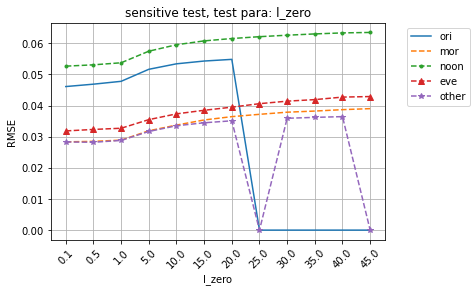

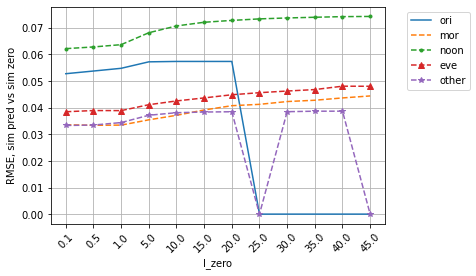

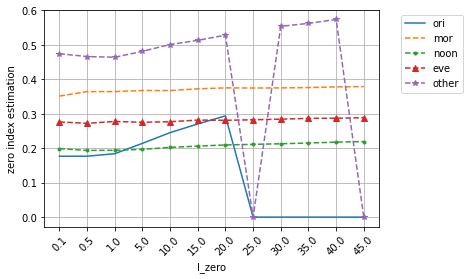

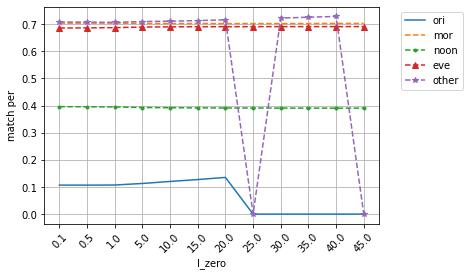

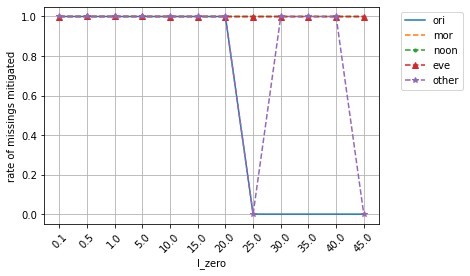

In [160]:
lzero_r_random = generate_paralst([0.1, 0.5, 1, 5, 10, 15, 20, 25, 30, 35, 40, 45], [4], [200, 0.01, 0.01, 0.5], 5)

test_lzero_r_random = fit_model_get_para_sensitive_w0(test_matrice_reverse, lzero, missing_info,
                                             0.0, 288, result_para_dict_w0,
                                             Zero_index, 'random')

plot_paras_sensitive_w0(test_lzero_r_random, lzero_r_random, 'l_zero', 4, 1)

RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1], 0.047745522059121935
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1], 0.05407004072361999
zero_val, para=[200, 0, 0, 0, 0.1], 0.24178810761186464
matched % compared with raw dt 0.12228060669785273
% of missings mitigated 0.9996969491694625
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1],mor, 0.03827251947260701
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1],mor, 0.04542111517321639
zero_val, para=[200, 0, 0, 0, 0.1], 0.47112345385781884
matched % compared with raw dtmor, 0.7066041514670329
% of missings mitigatedmor, 0.999658690590831
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1],noon, 0.05738505346843622
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 0.1],noon, 0.06671672215760087
zero_val, para=[200, 0, 0, 0, 0.1], 0.247214211217471
matched % compared with raw dtnoon, 0.39869801725247844
% of missings mitigatednoon, 0.999458012713282
RMSE, data wit

C:\Users\Yiran\anaconda3\lib\site-packages\sklearn\utils\extmath.py:153: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
C:\Users\Yiran\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:961: RuntimeWarning: invalid value encountered in true_divide
  numerator /= denominator


Error, fitting data failed
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 15],mor, 0.041603331634441486
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 15],mor, 0.04997919451647821
zero_val, para=[200, 0, 0, 0, 15], 0.49222589662543625
matched % compared with raw dtmor, 0.709275710627584
% of missings mitigatedmor, 0.9995694427358839
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 15],noon, 0.06324811162292167
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 15],noon, 0.0729794783666934
zero_val, para=[200, 0, 0, 0, 15], 0.2878092447229412
matched % compared with raw dtnoon, 0.39618605424659886
% of missings mitigatednoon, 0.999502468776584
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 15],eve, 0.045711832242250824
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 15],eve, 0.055211267907679606
zero_val, para=[200, 0, 0, 0, 15], 0.41961879277916736
matched % compared with raw dteve, 0.6876823189685298
% of missings mitigatedeve

C:\Users\Yiran\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:807: RuntimeWarning: overflow encountered in true_divide
  np.divide(X_data, WH_safe_X_data, out=WH_safe_X_data)
C:\Users\Yiran\anaconda3\lib\site-packages\sklearn\utils\extmath.py:153: RuntimeWarning: overflow encountered in matmul
  ret = a @ b


Error, fitting data failed
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 20],mor, 0.04216998221888728
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 20],mor, 0.050628142486213085
zero_val, para=[200, 0, 0, 0, 20], 0.4983830595801436
matched % compared with raw dtmor, 0.7104201536414746
% of missings mitigatedmor, 0.9995924416450537
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 20],noon, 0.0637902344644813
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 20],noon, 0.07335336145110015
zero_val, para=[200, 0, 0, 0, 20], 0.29490303048216626
matched % compared with raw dtnoon, 0.39644221278056735
% of missings mitigatednoon, 0.9995089238098624
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 20],eve, 0.04621584790585452
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 20],eve, 0.05586140688887411
zero_val, para=[200, 0, 0, 0, 20], 0.4225854613848331
matched % compared with raw dteve, 0.6882892824955398
% of missings mitigatedeve,

...

C:\Users\Yiran\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:961: RuntimeWarning: invalid value encountered in true_divide
  numerator /= denominator


Error, fitting data failed
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],mor, 0.04328131591277071
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],mor, 0.05246546137642996
zero_val, para=[200, 0, 0, 0, 45], 0.5118118867959001
matched % compared with raw dtmor, 0.7134064346308456
% of missings mitigatedmor, 0.9995881949210706
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],noon, 0.06505024579128627
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],noon, 0.0740530608553133
zero_val, para=[200, 0, 0, 0, 45], 0.3105135816439849
matched % compared with raw dtnoon, 0.3979603879661817
% of missings mitigatednoon, 0.9995277344620183
RMSE, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],eve, 0.04768779313949298
RMSE, zero, data with missing rate>=0.0, para=[200, 0, 0, 0, 45],eve, 0.058024274646109424
zero_val, para=[200, 0, 0, 0, 45], 0.4307680375390224
matched % compared with raw dteve, 0.6905883867645165
% of missings mitigatedeve, 0

C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:947: RuntimeWarning: overflow encountered in multiply
  zero_loss = np.sum(l_zero*np.dot(W.T, np.multiply(np.dot(W, H), zero_reg)), axis=1)
C:\Users\Yiran\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\3797599994.py:1023: RuntimeWarning: invalid value encountered in multiply
  H *= delta_H


Error, fitting data failed


NameError: name 'idx' is not defined

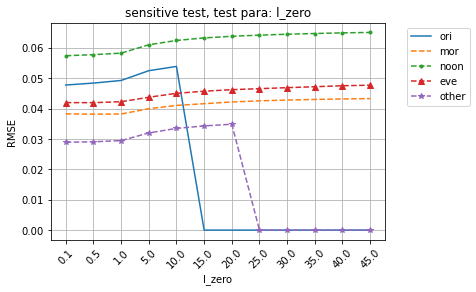

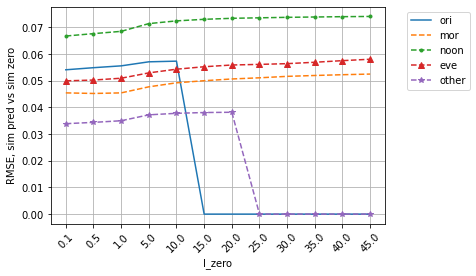

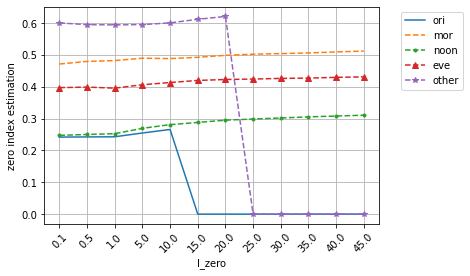

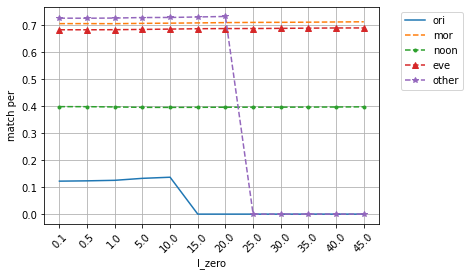

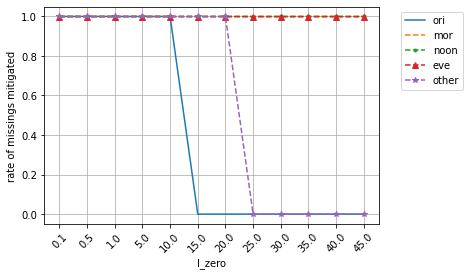

In [161]:
init_input = 'nndsvd'
lzero_nndsvd = generate_paralst([0.1, 0.5, 1, 5, 10, 15, 20, 25, 30, 35, 40, 45], [4], [200, 0,0,0], 5)

test_lzero_nndsvd = fit_model_get_para_sensitive_w0(test_matrice_reverse, lzero, missing_info,
                                             0.0, 288, result_para_dict_w0,
                                             Zero_index, init_input)

plot_paras_sensitive_w0(test_lzero_nndsvd, lzero_nndsvd, 'l_zero', 4, 1)

lzero_r_nndsvd = generate_paralst([0.1, 0.5, 1, 5, 10, 15, 20, 25, 30, 35, 40, 45], [4], [200, 0.01, 0.01, 0.5], 5)

test_lzero_r_nndsvd = fit_model_get_para_sensitive_w0(test_matrice_reverse, lzero, missing_info,
                                             0.0, 288, result_para_dict_w0,
                                             Zero_index, init_input)

plot_paras_sensitive_w0(test_lzero_r_nndsvd, lzero_r_nndsvd, 'l_zero', 4, idx)

In [ ]:
init_input = 'nndsvda'
lzero_nndsvd = generate_paralst([0.1, 0.5, 1, 5, 10, 15, 20, 25, 30, 35, 40, 45], [4], [200, 0,0,0], 5)

test_lzero_nndsvd = fit_model_get_para_sensitive_w0(test_matrice_reverse, lzero, missing_info,
                                             0.0, 288, result_para_dict_w0,
                                             Zero_index, init_input)

plot_paras_sensitive_w0(test_lzero_nndsvd, lzero_nndsvd, 'l_zero', 4, 1)

lzero_r_nndsvd = generate_paralst([0.1, 0.5, 1, 5, 10, 15, 20, 25, 30, 35, 40, 45], [4], [200, 0.01, 0.01, 0.5], 5)

test_lzero_r_nndsvd = fit_model_get_para_sensitive_w0(test_matrice_reverse, lzero, missing_info,
                                             0.0, 288, result_para_dict_w0,
                                             Zero_index, init_input)

plot_paras_sensitive_w0(test_lzero_r_nndsvd, lzero_r_nndsvd, 'l_zero', 4, idx)

In [ ]:
init_input = 'nndsvdar'
lzero_nndsvd = generate_paralst([0.1, 0.5, 1, 5, 10, 15, 20, 25, 30, 35, 40, 45], [4], [200, 0,0,0], 5)

test_lzero_nndsvd = fit_model_get_para_sensitive_w0(test_matrice_reverse, lzero, missing_info,
                                             0.0, 288, result_para_dict_w0,
                                             Zero_index, init_input)

plot_paras_sensitive_w0(test_lzero_nndsvd, lzero_nndsvd, 'l_zero', 4, 1)

lzero_r_nndsvd = generate_paralst([0.1, 0.5, 1, 5, 10, 15, 20, 25, 30, 35, 40, 45], [4], [200, 0.01, 0.01, 0.5], 5)

test_lzero_r_nndsvd = fit_model_get_para_sensitive_w0(test_matrice_reverse, lzero, missing_info,
                                             0.0, 288, result_para_dict_w0,
                                             Zero_index, init_input)

plot_paras_sensitive_w0(test_lzero_r_nndsvd, lzero_r_nndsvd, 'l_zero', 4, idx)

In [157]:
test_lzero_r['ori']

{'rmse_predvssim': [0.047745522059121935,
  0.04838947286760233,
  0.04924560424452219,
  0.05246721706915176,
  0.053863237166160045,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'rmse_predvszero': [0.05407004072361999,
  0.05485568366726712,
  0.055541965633745055,
  0.057055132750679693,
  0.05730381684119972,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'per of zero val': [0.24178810761186464,
  0.24226985681595592,
  0.2427743300391081,
  0.25464308519461987,
  0.26570968247728166,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'per of match': [0.12228060669785273,
  0.12342415561563881,
  0.12537641446003747,
  0.1326874383073688,
  0.13684856157818692,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'per of missings mitigated': [0.9996969491694625,
  0.9996751340900618,
  0.9996861649872575,
  0.9996953746427997,
  0.9997047825231253,
  0,
  0,
  0,
  0,
  0,
  0,
  0]}

In [14]:
lzero = generate_paralst(list(np.round(np.array(range(1, 31))*10,1)), [4], [300, 0,0,0], 5)

test_lzero = fit_model_get_para_sensitive_w0(test_matrice_reverse, lzero, missing_info,
                                             0.0, 288, result_para_dict_w0,
                                             Zero_index)

plot_paras_sensitive_w0(test_lzero, lzero, 'l_zero', 4, 1)

RMSE, data with missing rate>=0.0, para=[300, 0, 0, 0, 10], 0.05251916353132196
RMSE, zero, data with missing rate>=0.0, para=[300, 0, 0, 0, 10], 0.057341730623255684
zero_val, para=[300, 0, 0, 0, 10], 0.24493538425180028
matched % compared with raw dt 0.12856163183268243
% of missings mitigated 0.9997342658992868
RMSE, data with missing rate>=0.0, para=[300, 0, 0, 0, 10],mor, 0.02551630807997725
RMSE, zero, data with missing rate>=0.0, para=[300, 0, 0, 0, 10],mor, 0.025303701740120334
zero_val, para=[300, 0, 0, 0, 10], 0.4166773244660442
matched % compared with raw dtmor, 0.7005207215713203
% of missings mitigatedmor, 0.9998925219135876
RMSE, data with missing rate>=0.0, para=[300, 0, 0, 0, 10],noon, 0.05670475622872287
RMSE, zero, data with missing rate>=0.0, para=[300, 0, 0, 0, 10],noon, 0.0671255483172242
zero_val, para=[300, 0, 0, 0, 10], 0.21089233913362915
matched % compared with raw dtnoon, 0.39062969400454917
% of missings mitigatednoon, 0.9996632670578345
RMSE, data with miss

C:\Users\Yiran\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


RMSE, data with missing rate>=0.0, para=[300, 0, 0, 0, 20], 0.05433797518531303
RMSE, zero, data with missing rate>=0.0, para=[300, 0, 0, 0, 20], 0.05736274191542715
zero_val, para=[300, 0, 0, 0, 20], 0.30830585620695217
matched % compared with raw dt 0.14430040556199306
% of missings mitigated 0.9997189295709601
RMSE, data with missing rate>=0.0, para=[300, 0, 0, 0, 20],mor, 0.028851960864488765
RMSE, zero, data with missing rate>=0.0, para=[300, 0, 0, 0, 20],mor, 0.02934613224328426
zero_val, para=[300, 0, 0, 0, 20], 0.4207333784005993
matched % compared with raw dtmor, 0.6996695420797391
% of missings mitigatedmor, 0.9999166428503382
RMSE, data with missing rate>=0.0, para=[300, 0, 0, 0, 20],noon, 0.05957975437285036
RMSE, zero, data with missing rate>=0.0, para=[300, 0, 0, 0, 20],noon, 0.07154748108325287
zero_val, para=[300, 0, 0, 0, 20], 0.21274179042085573
matched % compared with raw dtnoon, 0.38899081584481354
% of missings mitigatednoon, 0.999688314880989
RMSE, data with missi

C:\Users\Yiran\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\769950635.py:947: RuntimeWarning: overflow encountered in multiply
  zero_loss = np.sum(zero_weight*np.dot(W.T, np.multiply(np.dot(W, H), zero_reg)), axis=1)
C:\Users\Yiran\AppData\Local\Temp\ipykernel_26272\769950635.py:1023: RuntimeWarning: invalid value encountered in multiply
  H *= delta_H


Error, fitting data failed
RMSE, data with missing rate>=0.0, para=[300, 0, 0, 0, 30],mor, 0.030756715415445352
RMSE, zero, data with missing rate>=0.0, para=[300, 0, 0, 0, 30],mor, 0.03113671182300782
zero_val, para=[300, 0, 0, 0, 30], 0.421975773299472
matched % compared with raw dtmor, 0.6996659656953207
% of missings mitigatedmor, 0.9998928277980875
RMSE, data with missing rate>=0.0, para=[300, 0, 0, 0, 30],noon, 0.061082379994152634
RMSE, zero, data with missing rate>=0.0, para=[300, 0, 0, 0, 30],noon, 0.07332948791798695
zero_val, para=[300, 0, 0, 0, 30], 0.2139325330304399
matched % compared with raw dtnoon, 0.38858310802111495
% of missings mitigatednoon, 0.9996797487124144
RMSE, data with missing rate>=0.0, para=[300, 0, 0, 0, 30],eve, 0.031667038321393004
RMSE, zero, data with missing rate>=0.0, para=[300, 0, 0, 0, 30],eve, 0.032044193664370536
zero_val, para=[300, 0, 0, 0, 30], 0.3933453551276831
matched % compared with raw dteve, 0.6923798488109033
% of missings mitigatedev

IndexError: list index out of range

In [ ]:
lzero = generate_paralst(list(np.round(np.array(range(1, 11))*10,1)), [4], [300, 0.01, 0.01, 0.5], 5)

test_lzero = fit_model_get_para_sensitive_w0(test_matrice_reverse, lzero, missing_info,
                                             0.0, 288, result_para_dict_w0,
                                             Zero_index)

plot_paras_sensitive_w0(test_lzero, lzero, 'l_zero', 4, 1)

RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 0.6], 0.14767775392071172
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 0.6], 0.15245760110408343
zero_val, para=[300, 0.01, 0.01, 0.5, 0.6], 0.9998977419142259
matched % compared with raw dt 0.11280184684491366
% of missings mitigated 0.9996230921559834
RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 0.6],mor, 0.15354877846093512
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 0.6],mor, 0.15853150279962452
zero_val, para=[300, 0.01, 0.01, 0.5, 0.6], 0.9998355653810316
matched % compared with raw dtmor, 0.6985894739853797
% of missings mitigatedmor, 0.9997033626806521
RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 0.6],noon, 0.17689548157945612
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 0.6],noon, 0.1836795729195052
zero_val, para=[300, 0.01, 0.01, 0.5, 0.6], 0.9998859927288696
matched % compared with raw dtnoon, 0.393342828

RMSE, data with missing rate>=0.0, para=[300, 0.01, 100.0, 0.5, 0.6],other, 0.09417796484080418
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 100.0, 0.5, 0.6],other, 0.09418123478847965
zero_val, para=[300, 0.01, 100.0, 0.5, 0.6], 1.0
matched % compared with raw dtother, 0.7143264521332572
% of missings mitigatedother, 0.9998472873010079
RMSE, data with missing rate>=0.0, para=[300, 0.1, 0.01, 0.5, 0.6], 0.1530041946708703
RMSE, zero, data with missing rate>=0.0, para=[300, 0.1, 0.01, 0.5, 0.6], 0.15616143927463816
zero_val, para=[300, 0.1, 0.01, 0.5, 0.6], 0.9999954551961878
matched % compared with raw dt 0.09259974536142941
% of missings mitigated 0.9994201284880971
RMSE, data with missing rate>=0.0, para=[300, 0.1, 0.01, 0.5, 0.6],mor, 0.17151641702440953
RMSE, zero, data with missing rate>=0.0, para=[300, 0.1, 0.01, 0.5, 0.6],mor, 0.17681858638413905
zero_val, para=[300, 0.1, 0.01, 0.5, 0.6], 0.9999451884603439
matched % compared with raw dtmor, 0.6936934037165787
% of 

RMSE, data with missing rate>=0.0, para=[700, 0.01, 0.01, 0.2, 0.6],eve, 0.1993933309966623
RMSE, zero, data with missing rate>=0.0, para=[700, 0.01, 0.01, 0.2, 0.6],eve, 0.2036924419220839
zero_val, para=[700, 0.01, 0.01, 0.2, 0.6], 1.0
matched % compared with raw dteve, 0.6840147878386581
% of missings mitigatedeve, 0.9998719426302983
RMSE, data with missing rate>=0.0, para=[700, 0.01, 0.01, 0.2, 0.6],other, 0.08554029159026588
RMSE, zero, data with missing rate>=0.0, para=[700, 0.01, 0.01, 0.2, 0.6],other, 0.08980749828427971
zero_val, para=[700, 0.01, 0.01, 0.2, 0.6], 0.9999896832765913
matched % compared with raw dtother, 0.7005119136163064
% of missings mitigatedother, 0.9998614372861604
RMSE, data with missing rate>=0.0, para=[700, 0.01, 0.1, 0.2, 0.6], 0.15227687397429335
RMSE, zero, data with missing rate>=0.0, para=[700, 0.01, 0.1, 0.2, 0.6], 0.15617918493710595
zero_val, para=[700, 0.01, 0.1, 0.2, 0.6], 0.9999954551961878
matched % compared with raw dt 0.09703267384804658
% 

RMSE, data with missing rate>=0.0, para=[700, 0.01, 0.01, 0.2, 0.6],noon, 0.17285568688534092
RMSE, zero, data with missing rate>=0.0, para=[700, 0.01, 0.01, 0.2, 0.6],noon, 0.18015609813843822
zero_val, para=[700, 0.01, 0.01, 0.2, 0.6], 0.9999324401356264
matched % compared with raw dtnoon, 0.39750305780867773
% of missings mitigatednoon, 0.9995859683332554
RMSE, data with missing rate>=0.0, para=[700, 0.01, 0.01, 0.2, 0.6],eve, 0.1993933309966623
RMSE, zero, data with missing rate>=0.0, para=[700, 0.01, 0.01, 0.2, 0.6],eve, 0.2036924419220839
zero_val, para=[700, 0.01, 0.01, 0.2, 0.6], 1.0
matched % compared with raw dteve, 0.6840147878386581
% of missings mitigatedeve, 0.9998719426302983
RMSE, data with missing rate>=0.0, para=[700, 0.01, 0.01, 0.2, 0.6],other, 0.08554029159026588
RMSE, zero, data with missing rate>=0.0, para=[700, 0.01, 0.01, 0.2, 0.6],other, 0.08980749828427971
zero_val, para=[700, 0.01, 0.01, 0.2, 0.6], 0.9999896832765913
matched % compared with raw dtother, 0.70

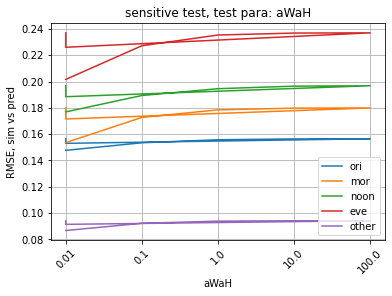

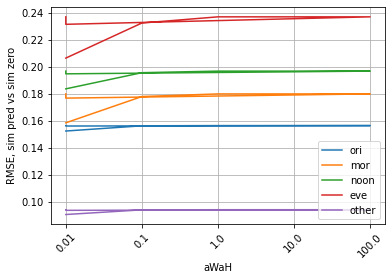

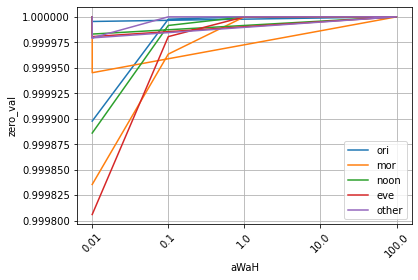

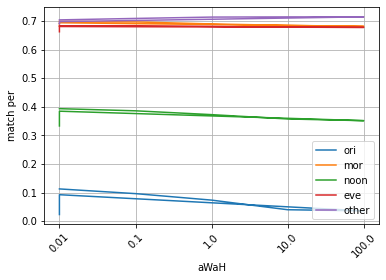

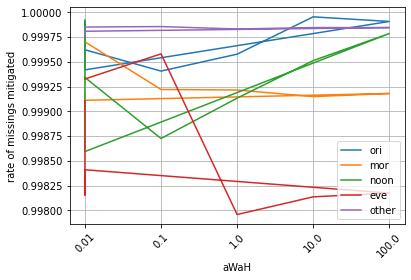

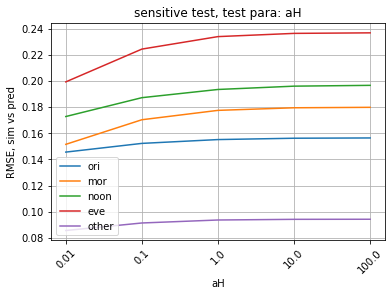

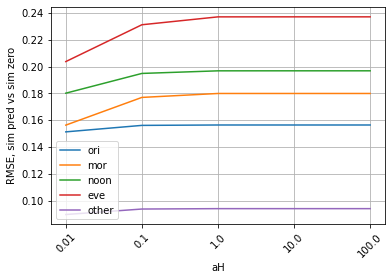

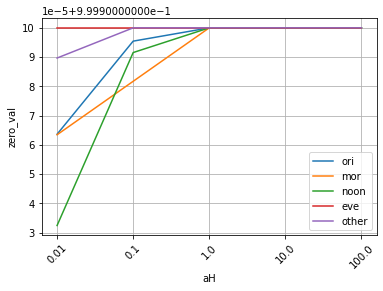

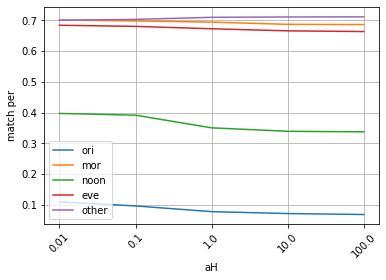

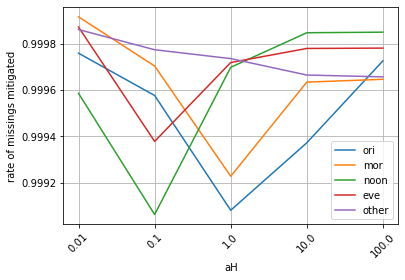

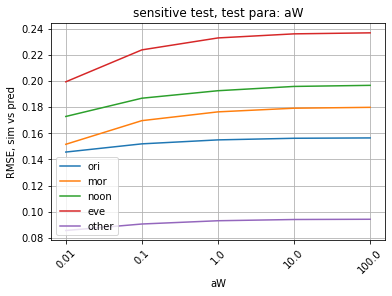

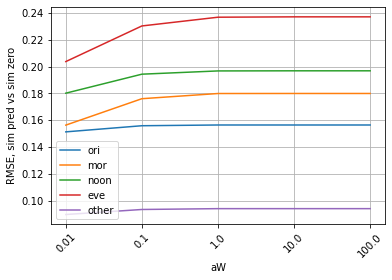

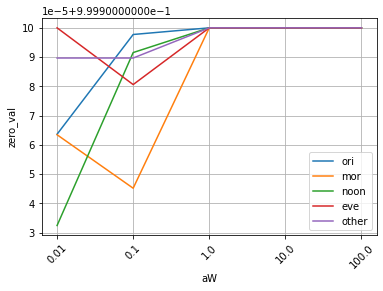

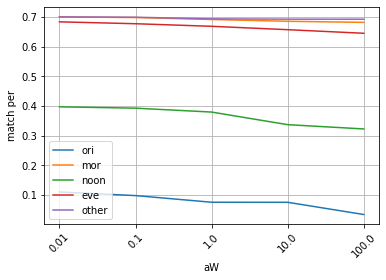

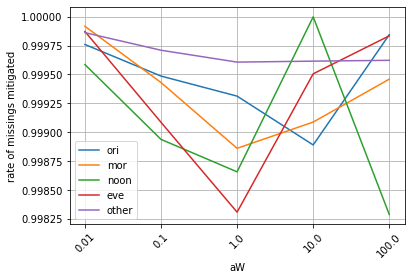

In [178]:
aWaH_nmf_1 =  [[300, 0.01, 0.01, 0.5, 0.1],
                [300, 0.01, 0.1, 0.5, 0.1],
                [300, 0.01, 1.0, 0.5, 0.1],
                [300, 0.01, 10.0, 0.5,0.1],
                [300, 0.01, 100.0, 0.5,0.1],
                [300, 0.1, 0.01, 0.5,0.1],
                [300, 1., 0.01, 0.5,0.1],
                [300, 10., 0.01, 0.5,0.1],
                [300, 100., 0.01, 0.5,0.1]]

aWaH_nmf_2 =  [[300, 0.01, 0.01, 0.2,0.1],
                [300, 0.01, 0.1, 0.2,0.1],
                [300, 0.01, 1.0, 0.2,0.1],
                [300, 0.01, 10.0, 0.2,0.1],
                [300, 0.01, 100.0, 0.2,0.1]]

aWaH_nmf_3 =  [[300, 0.01, 0.01, 0.2,0.1],
                [300, 0.1, 0.01, 0.2,0.1],
                [300, 1., 0.01, 0.2,0.1],
                [300, 10., 0.01, 0.2,0.1],
                [300, 100., 0.01, 0.2,0.1]]

test_awah_1 = fit_model_get_para_sensitive_w0(test_matrice_reverse, aWaH_nmf_1, missing_info,
                                             0.0, 288, result_para_dict_w0,
                                             Zero_index)

test_awah_2 = fit_model_get_para_sensitive_w0(test_matrice_reverse, aWaH_nmf_2, missing_info,
                                             0.0, 288, result_para_dict_w0,
                                             Zero_index)

test_awah_3 = fit_model_get_para_sensitive_w0(test_matrice_reverse, aWaH_nmf_3, missing_info,
                                             0.0, 288, result_para_dict_w0,
                                             Zero_index)

idx = plot_paras_sensitive_w0(test_awah_1, aWaH_nmf_1, 'aWaH', 2, 1)
idx = plot_paras_sensitive_w0(test_awah_2, aWaH_nmf_2, 'aH', 2, idx)
idx = plot_paras_sensitive_w0(test_awah_3, aWaH_nmf_3, 'aW', 1, idx)

In [184]:
l1_ratio_nmf_1 = generate_paralst(list(np.round(np.array(range(0, 11))*0.1, 2)), [3], [300, 0.01, 0.01, 0.6], 5)
l1_ratio_nmf_2 = generate_paralst(list(np.round(np.array(range(0, 11))*0.1, 2)), [3], [300, 10, 0.01, 0.6], 5)
l1_ratio_nmf_3 = generate_paralst(list(np.round(np.array(range(0, 11))*0.1, 2)), [3], [300, 0.01, 10, 0.6], 5)
l1_ratio_nmf_4 = generate_paralst(list(np.round(np.array(range(0, 11))*0.1, 2)), [3], [300, 10, 10, 0.6], 5)

In [187]:
test_l1_1 = fit_model_get_para_sensitive_w0(test_matrice_reverse, l1_ratio_nmf_1, missing_info,
                                             0.0, 288, result_para_dict_w0, Zero_index)
test_l1_2 = fit_model_get_para_sensitive_w0(test_matrice_reverse, l1_ratio_nmf_2, missing_info,
                                             0.0, 288, result_para_dict_w0, Zero_index)
test_l1_3 = fit_model_get_para_sensitive_w0(test_matrice_reverse, l1_ratio_nmf_3, missing_info,
                                             0.0, 288, result_para_dict_w0, Zero_index)
test_l1_4 = fit_model_get_para_sensitive_w0(test_matrice_reverse, l1_ratio_nmf_4, missing_info,
                                             0.0, 288, result_para_dict_w0, Zero_index)

RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.0, 0.6], 0.14553152753303497
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.0, 0.6], 0.15149016976025773
zero_val, para=[300, 0.01, 0.01, 0.0, 0.6], 0.9999590967656904
matched % compared with raw dt 0.10266726749924895
% of missings mitigated 0.9997469161634882
RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.0, 0.6],mor, 0.15096682006376877
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.0, 0.6],mor, 0.1545819123370327
zero_val, para=[300, 0.01, 0.01, 0.0, 0.6], 0.9999086474339064
matched % compared with raw dtmor, 0.7025056149235369
% of missings mitigatedmor, 0.9998797831287642
RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.0, 0.6],noon, 0.17298040163083567
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.0, 0.6],noon, 0.17933028548400187
zero_val, para=[300, 0.01, 0.01, 0.0, 0.6], 0.9999282176441031
matched % compared with raw dtnoon, 0.395636185

RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.4, 0.6],other, 0.08644457803118621
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.4, 0.6],other, 0.09046246183305894
zero_val, para=[300, 0.01, 0.01, 0.4, 0.6], 0.9999793665531828
matched % compared with raw dtother, 0.7021675727037573
% of missings mitigatedother, 0.9998285132455654
RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 0.6], 0.14767775392071172
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 0.6], 0.15245760110408343
zero_val, para=[300, 0.01, 0.01, 0.5, 0.6], 0.9998977419142259
matched % compared with raw dt 0.11280184684491366
% of missings mitigated 0.9996230921559834
RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 0.6],mor, 0.15354877846093512
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 0.6],mor, 0.15853150279962452
zero_val, para=[300, 0.01, 0.01, 0.5, 0.6], 0.9998355653810316
matched % compared with raw dtmor, 0.698

matched % compared with raw dtnoon, 0.393982554396807
% of missings mitigatednoon, 0.9991878123160406
RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.9, 0.6],eve, 0.1965137875108242
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.9, 0.6],eve, 0.20096426889080032
zero_val, para=[300, 0.01, 0.01, 0.9, 0.6], 0.9998254900820197
matched % compared with raw dteve, 0.6873659622211187
% of missings mitigatedeve, 0.9993293170800583
RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.9, 0.6],other, 0.08691697092500338
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.9, 0.6],other, 0.09012695303543165
zero_val, para=[300, 0.01, 0.01, 0.9, 0.6], 0.9999587331063654
matched % compared with raw dtother, 0.7115939762100091
% of missings mitigatedother, 0.9998561129845118
RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 1.0, 0.6], 0.14795251166133558
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 0.01, 1.0, 0.6], 0.1519551971396

RMSE, data with missing rate>=0.0, para=[300, 10, 0.01, 0.3, 0.6],noon, 0.19610242426166646
RMSE, zero, data with missing rate>=0.0, para=[300, 10, 0.01, 0.3, 0.6],noon, 0.19682343504642466
zero_val, para=[300, 10, 0.01, 0.3, 0.6], 1.0
matched % compared with raw dtnoon, 0.3661135788163598
% of missings mitigatednoon, 0.9990182927603323
RMSE, data with missing rate>=0.0, para=[300, 10, 0.01, 0.3, 0.6],eve, 0.23634441760048355
RMSE, zero, data with missing rate>=0.0, para=[300, 10, 0.01, 0.3, 0.6],eve, 0.2370097347436488
zero_val, para=[300, 10, 0.01, 0.3, 0.6], 1.0
matched % compared with raw dteve, 0.6594162114440214
% of missings mitigatedeve, 0.9992007430929082
RMSE, data with missing rate>=0.0, para=[300, 10, 0.01, 0.3, 0.6],other, 0.09403898897502931
RMSE, zero, data with missing rate>=0.0, para=[300, 10, 0.01, 0.3, 0.6],other, 0.09418123478847965
zero_val, para=[300, 10, 0.01, 0.3, 0.6], 1.0
matched % compared with raw dtother, 0.6898788793869379
% of missings mitigatedother, 0.9

RMSE, data with missing rate>=0.0, para=[300, 10, 0.01, 0.8, 0.6],noon, 0.19647057179093988
RMSE, zero, data with missing rate>=0.0, para=[300, 10, 0.01, 0.8, 0.6],noon, 0.19682343504642466
zero_val, para=[300, 10, 0.01, 0.8, 0.6], 1.0
matched % compared with raw dtnoon, 0.35666924166344793
% of missings mitigatednoon, 0.999428795383666
RMSE, data with missing rate>=0.0, para=[300, 10, 0.01, 0.8, 0.6],eve, 0.23674565894898775
RMSE, zero, data with missing rate>=0.0, para=[300, 10, 0.01, 0.8, 0.6],eve, 0.2370097347436488
zero_val, para=[300, 10, 0.01, 0.8, 0.6], 1.0
matched % compared with raw dteve, 0.6686346999209108
% of missings mitigatedeve, 0.9988010657193606
RMSE, data with missing rate>=0.0, para=[300, 10, 0.01, 0.8, 0.6],other, 0.09413859162592868
RMSE, zero, data with missing rate>=0.0, para=[300, 10, 0.01, 0.8, 0.6],other, 0.09418123478847965
zero_val, para=[300, 10, 0.01, 0.8, 0.6], 1.0
matched % compared with raw dtother, 0.6917377716914217
% of missings mitigatedother, 0.9

RMSE, data with missing rate>=0.0, para=[300, 0.01, 10, 0.2, 0.6],noon, 0.1961284594115783
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 10, 0.2, 0.6],noon, 0.19682343504642466
zero_val, para=[300, 0.01, 10, 0.2, 0.6], 1.0
matched % compared with raw dtnoon, 0.36056258315093775
% of missings mitigatednoon, 0.999387564625565
RMSE, data with missing rate>=0.0, para=[300, 0.01, 10, 0.2, 0.6],eve, 0.23661626973198238
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 10, 0.2, 0.6],eve, 0.2370097347436488
zero_val, para=[300, 0.01, 10, 0.2, 0.6], 1.0
matched % compared with raw dteve, 0.6839154665342383
% of missings mitigatedeve, 0.9979400879826827
RMSE, data with missing rate>=0.0, para=[300, 0.01, 10, 0.2, 0.6],other, 0.09410854897145642
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 10, 0.2, 0.6],other, 0.09418123478847965
zero_val, para=[300, 0.01, 10, 0.2, 0.6], 1.0
matched % compared with raw dtother, 0.7073888574994653
% of missings mitigatedother, 0.99

RMSE, data with missing rate>=0.0, para=[300, 0.01, 10, 0.7, 0.6],noon, 0.1965336429126833
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 10, 0.7, 0.6],noon, 0.19682343504642466
zero_val, para=[300, 0.01, 10, 0.7, 0.6], 1.0
matched % compared with raw dtnoon, 0.35578006308742116
% of missings mitigatednoon, 0.9995253470899405
RMSE, data with missing rate>=0.0, para=[300, 0.01, 10, 0.7, 0.6],eve, 0.23683243616122307
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 10, 0.7, 0.6],eve, 0.2370097347436488
zero_val, para=[300, 0.01, 10, 0.7, 0.6], 1.0
matched % compared with raw dteve, 0.6739244790229727
% of missings mitigatedeve, 0.9983980505855012
RMSE, data with missing rate>=0.0, para=[300, 0.01, 10, 0.7, 0.6],other, 0.09415566123604521
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 10, 0.7, 0.6],other, 0.09418123478847965
zero_val, para=[300, 0.01, 10, 0.7, 0.6], 1.0
matched % compared with raw dtother, 0.7145318134468034
% of missings mitigatedother, 0.9

RMSE, data with missing rate>=0.0, para=[300, 10, 10, 0.1, 0.6],noon, 0.19680104400129178
RMSE, zero, data with missing rate>=0.0, para=[300, 10, 10, 0.1, 0.6],noon, 0.19682343504642466
zero_val, para=[300, 10, 10, 0.1, 0.6], 1.0
matched % compared with raw dtnoon, 0.3531205742242822
% of missings mitigatednoon, 0.9996765726654144
RMSE, data with missing rate>=0.0, para=[300, 10, 10, 0.1, 0.6],eve, 0.23699529901303287
RMSE, zero, data with missing rate>=0.0, para=[300, 10, 10, 0.1, 0.6],eve, 0.2370097347436488
zero_val, para=[300, 10, 10, 0.1, 0.6], 1.0
matched % compared with raw dteve, 0.6701760194228329
% of missings mitigatedeve, 0.9987620035466925
RMSE, data with missing rate>=0.0, para=[300, 10, 10, 0.1, 0.6],other, 0.09417915889093491
RMSE, zero, data with missing rate>=0.0, para=[300, 10, 10, 0.1, 0.6],other, 0.09418123478847965
zero_val, para=[300, 10, 10, 0.1, 0.6], 1.0
matched % compared with raw dtother, 0.6941127274004131
% of missings mitigatedother, 0.9997912861987999
RM

RMSE, data with missing rate>=0.0, para=[300, 10, 10, 0.6, 0.6],eve, 0.2370090948916714
RMSE, zero, data with missing rate>=0.0, para=[300, 10, 10, 0.6, 0.6],eve, 0.2370097347436488
zero_val, para=[300, 10, 10, 0.6, 0.6], 1.0
matched % compared with raw dteve, 0.6706248045761372
% of missings mitigatedeve, 0.9987491484157741
RMSE, data with missing rate>=0.0, para=[300, 10, 10, 0.6, 0.6],other, 0.09418114979662262
RMSE, zero, data with missing rate>=0.0, para=[300, 10, 10, 0.6, 0.6],other, 0.09418123478847965
zero_val, para=[300, 10, 10, 0.6, 0.6], 1.0
matched % compared with raw dtother, 0.7044563405039546
% of missings mitigatedother, 0.9997443781187669
RMSE, data with missing rate>=0.0, para=[300, 10, 10, 0.7, 0.6], 0.15647309818674568
RMSE, zero, data with missing rate>=0.0, para=[300, 10, 10, 0.7, 0.6], 0.1564732911513456
zero_val, para=[300, 10, 10, 0.7, 0.6], 1.0
matched % compared with raw dt 0.031544604666466386
% of missings mitigated 0.999895214680654
RMSE, data with missing

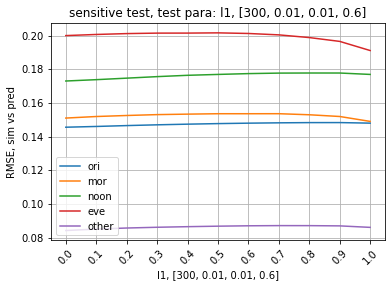

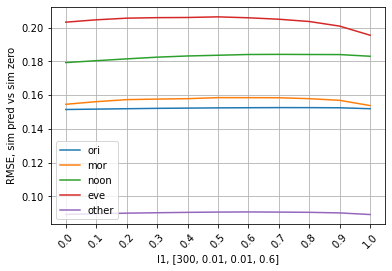

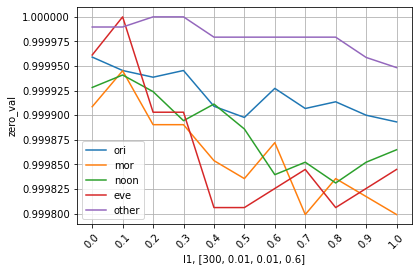

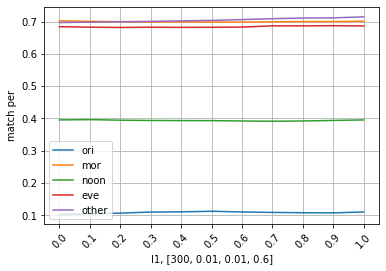

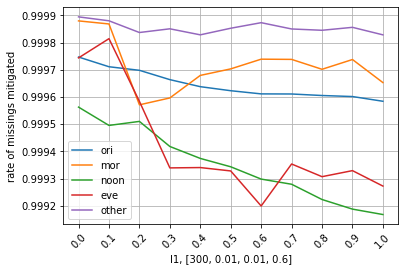

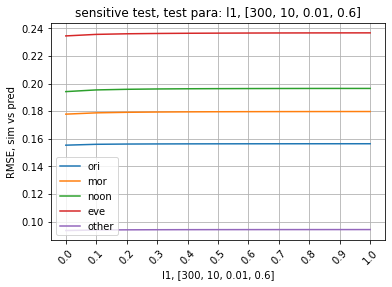

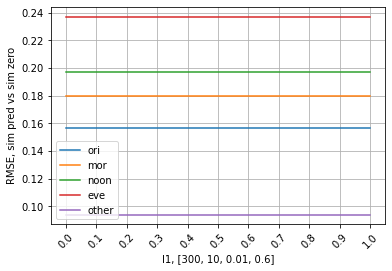

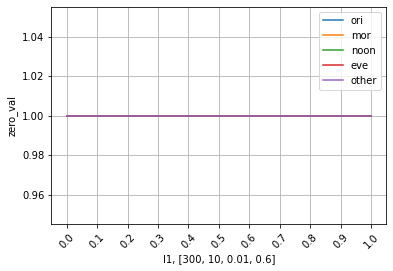

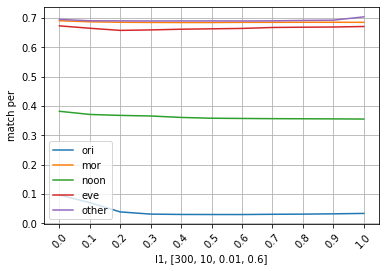

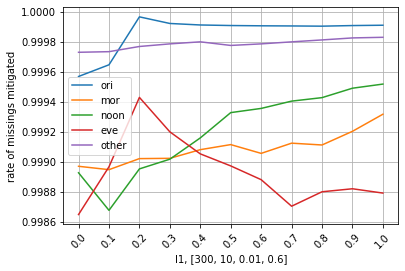

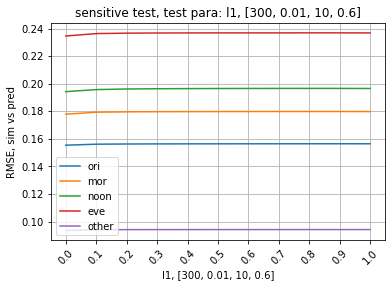

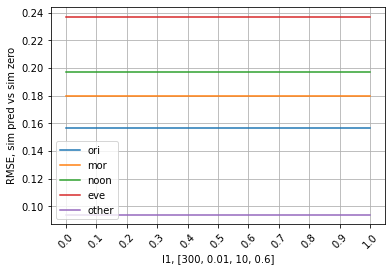

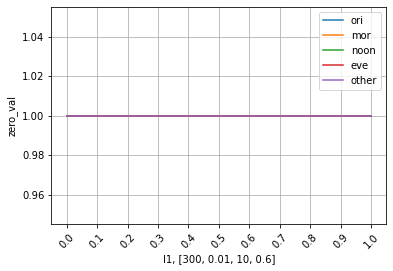

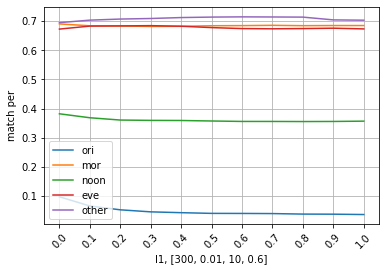

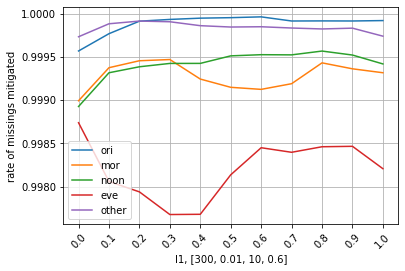

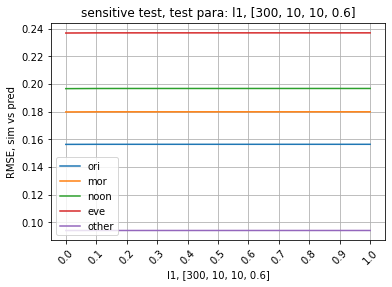

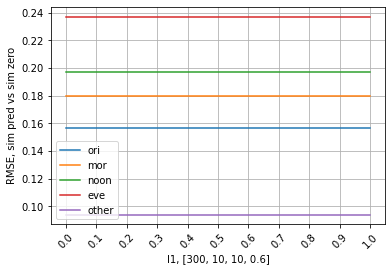

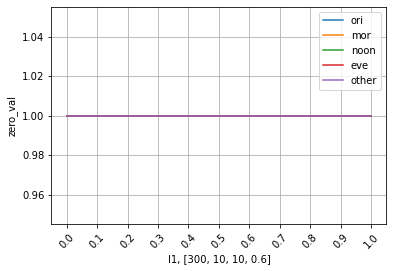

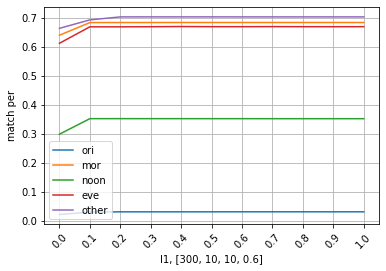

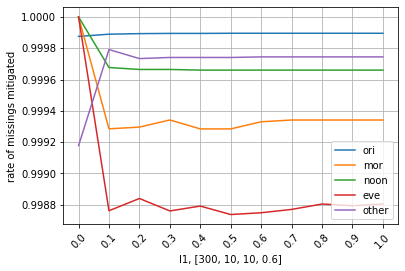

In [190]:
idx = plot_paras_sensitive_w0(test_l1_1, l1_ratio_nmf_1, 'l1, [300, 0.01, 0.01, 0.6]', 3, 1)
idx = plot_paras_sensitive_w0(test_l1_2, l1_ratio_nmf_2, 'l1, [300, 10, 0.01, 0.6]', 3, idx)
idx = plot_paras_sensitive_w0(test_l1_3, l1_ratio_nmf_3, 'l1, [300, 0.01, 10, 0.6]', 3, idx)
idx = plot_paras_sensitive_w0(test_l1_4, l1_ratio_nmf_4, 'l1, [300, 10, 10, 0.6]', 3, idx)

### model comparison

C:\Users\Yiran\anaconda3\lib\site-packages\sklearn\decomposition\_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


RMSE, data with missing rate>=0.0, para=[100, 0.01, 0.01, 0.5], 0.14819854840033364
matched % compared with raw dt 0.29242933064389226
% of missings mitigated 0.9994256875007108


C:\Users\Yiran\anaconda3\lib\site-packages\sklearn\decomposition\_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


RMSE, data with missing rate>=0.0, para=[100, 0.01, 0.01, 0.5],mor, 0.1579822392047505
matched % compared with raw dtmor, 0.833934165915626
% of missings mitigatedmor, 0.9985355558427015


C:\Users\Yiran\anaconda3\lib\site-packages\sklearn\decomposition\_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


RMSE, data with missing rate>=0.0, para=[100, 0.01, 0.01, 0.5],noon, 0.17900904728422173
matched % compared with raw dtnoon, 0.49572979700442044
% of missings mitigatednoon, 0.9989414893617021
RMSE, data with missing rate>=0.0, para=[100, 0.01, 0.01, 0.5],eve, 0.20862013807409832
matched % compared with raw dteve, 0.8291931063657599
% of missings mitigatedeve, 0.9970495122003747
RMSE, data with missing rate>=0.0, para=[100, 0.01, 0.01, 0.5],other, 0.08690470014011736
matched % compared with raw dtother, 0.7733300560647026
% of missings mitigatedother, 0.999680790138293
RMSE, data with missing rate>=0.0, para=[200, 0.01, 0.01, 0.5], 0.1472696181972405
matched % compared with raw dt 0.2793692688439695
% of missings mitigated 0.9994882057797386
RMSE, data with missing rate>=0.0, para=[200, 0.01, 0.01, 0.5],mor, 0.15453171373361763
matched % compared with raw dtmor, 0.8821438278757707
% of missings mitigatedmor, 0.9972082296534563
RMSE, data with missing rate>=0.0, para=[200, 0.01, 0.01, 0

RMSE, data with missing rate>=0.0, para=[1000, 0.01, 0.01, 0.5],mor, 0.15267957003690794
matched % compared with raw dtmor, 0.82078022402472
% of missings mitigatedmor, 0.9997804916985952
RMSE, data with missing rate>=0.0, para=[1000, 0.01, 0.01, 0.5],noon, 0.17513869460384632
matched % compared with raw dtnoon, 0.3934514613106734
% of missings mitigatednoon, 0.9994096342385609
RMSE, data with missing rate>=0.0, para=[1000, 0.01, 0.01, 0.5],eve, 0.19861513359184207
matched % compared with raw dteve, 0.8863433206422777
% of missings mitigatedeve, 0.9996439783797779
RMSE, data with missing rate>=0.0, para=[1000, 0.01, 0.01, 0.5],other, 0.0865151559795597
matched % compared with raw dtother, 0.749563474202682
% of missings mitigatedother, 0.9998470441277691
RMSE, data with missing rate>=0.0, para=[100, 1.1, 1.1], 0.15568698114036478
matched % compared with raw dt 0.02219191236427621
% of missings mitigated 0.9998477543770616
RMSE, data with missing rate>=0.0, para=[100, 1.1, 1.1],mor, 0.0

RMSE, data with missing rate>=0.0, para=[900, 1.1, 1.1],noon, 0.07568628468450618
matched % compared with raw dtnoon, 0.13634071499077294
% of missings mitigatednoon, 0.9997406719546813
RMSE, data with missing rate>=0.0, para=[900, 1.1, 1.1],eve, 0.23652228101993103
matched % compared with raw dteve, 0.013217090621493866
% of missings mitigatedeve, 1.0
RMSE, data with missing rate>=0.0, para=[900, 1.1, 1.1],other, 0.09411185790735781
matched % compared with raw dtother, 0.03549026555452343
% of missings mitigatedother, 0.9995454811225734
RMSE, data with missing rate>=0.0, para=[1000, 1.1, 1.1], 0.07410384489574139
matched % compared with raw dt 0.11331461096090296
% of missings mitigated 0.9997368186211413
RMSE, data with missing rate>=0.0, para=[1000, 1.1, 1.1],mor, 0.17961531769039715
matched % compared with raw dtmor, 0.011830679656094875
% of missings mitigatedmor, 1.0
RMSE, data with missing rate>=0.0, para=[1000, 1.1, 1.1],noon, 0.07506724395076404
matched % compared with raw dtn

if pred & fit dt is equal, with tol=0.01: False
RMSE, data with missing rate>=0.0, k=70,noon, 0.15536664703921652
matched % compared with raw dtnoon, 0.38815394189090596
% of missings mitigatednoon, 0.9984174024357098
if pred & fit dt is equal, with tol=0.01: False
RMSE, data with missing rate>=0.0, k=70,eve, 0.1437809788808662
matched % compared with raw dteve, 0.6726369806323457
% of missings mitigatedeve, 0.9971120999640417
if pred & fit dt is equal, with tol=0.01: False
RMSE, data with missing rate>=0.0, k=70,other, 0.062165611128414504
matched % compared with raw dtother, 0.7017717467522587
% of missings mitigatedother, 0.9993934571869971
if pred & fit dt is equal, with tol=0.01: False
RMSE, data with missing rate>=0.0, k=80, 0.13352556619054073
matched % compared with raw dt 0.0991351408380184
% of missings mitigated 0.9987226700265639
if pred & fit dt is equal, with tol=0.01: False
RMSE, data with missing rate>=0.0, k=80,mor, 0.09748354282100252
matched % compared with raw dtmor

NameError: name 'test_k_svd_100' is not defined

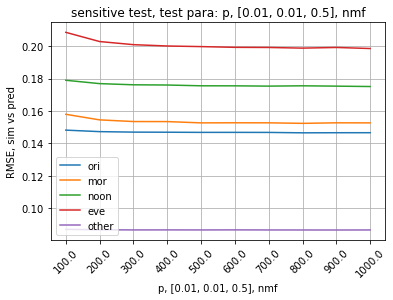

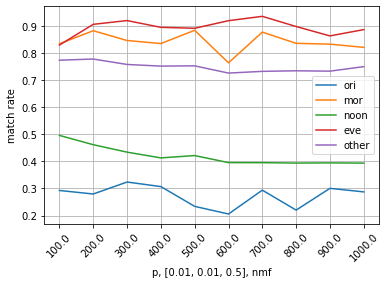

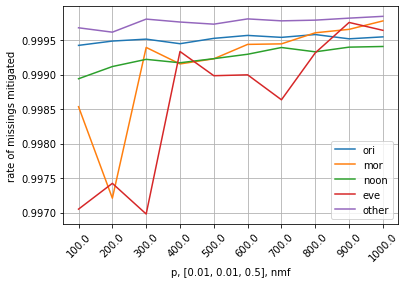

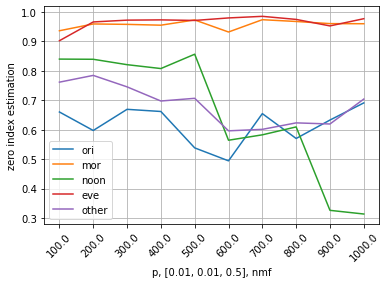

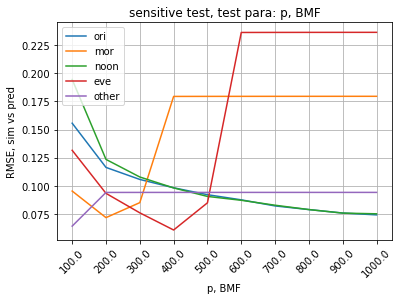

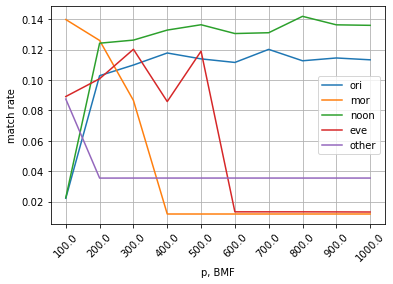

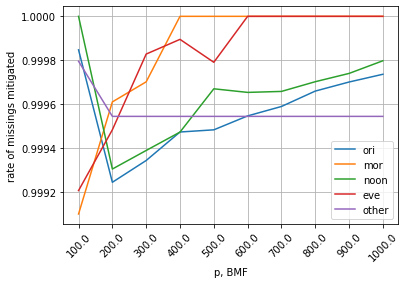

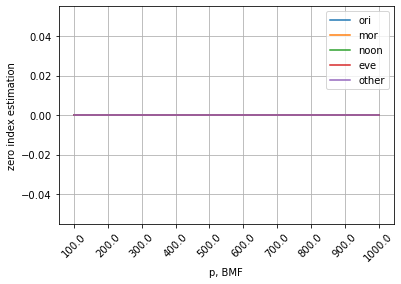

In [221]:
#NMF
k_nmf_100_r = generate_paralst(list(np.array(range(1, 11))*100), [0], [0.01, 0.01, 0.5], 4)
test_k_nmf_100_r = fit_model_get_para_sensitive(test_matrice_reverse, Zero_index, k_nmf_100_r, 
                                          missing_val, 288, result_para_dict, 'NMF', True)


#BMF
k_bmf_100 =  generate_paralst(list(np.array(range(1, 11))*100), [0], [1.1, 1.1], 3)
test_k_bmf_100 = fit_model_get_para_sensitive(test_matrice_reverse, Zero_index, k_bmf_100,
                                          missing_val, 288, result_para_dict, 'BMF', True)

if pred & fit dt is equal, with tol=0.01: False
RMSE, data with missing rate>=0.0, k=100, 0.12927862784395378
matched % compared with raw dt 0.09758164885627227
% of missings mitigated 0.9988521838725146
if pred & fit dt is equal, with tol=0.01: False
RMSE, data with missing rate>=0.0, k=100,mor, 0.08624762977138335
matched % compared with raw dtmor, 0.702366135931219
% of missings mitigatedmor, 0.9983057364639157
if pred & fit dt is equal, with tol=0.01: False
RMSE, data with missing rate>=0.0, k=100,noon, 0.1433722430760357
matched % compared with raw dtnoon, 0.39003154371057036
% of missings mitigatednoon, 0.998819292366956
if pred & fit dt is equal, with tol=0.01: False
RMSE, data with missing rate>=0.0, k=100,eve, 0.11886652419113196
matched % compared with raw dteve, 0.6845077157939267
% of missings mitigatedeve, 0.9965603684486679
if pred & fit dt is equal, with tol=0.01: False
RMSE, data with missing rate>=0.0, k=100,other, 0.05603822205763174
matched % compared with raw dtothe

KeyError: 'rmse_predvsraw'

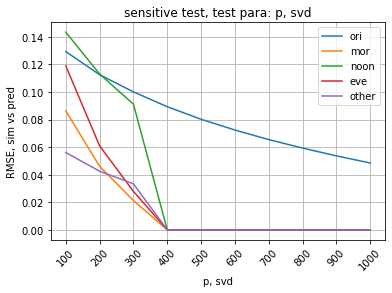

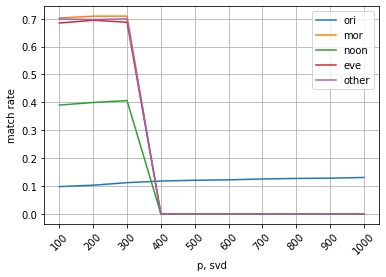

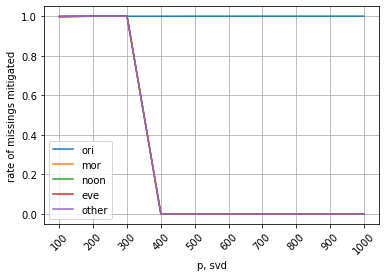

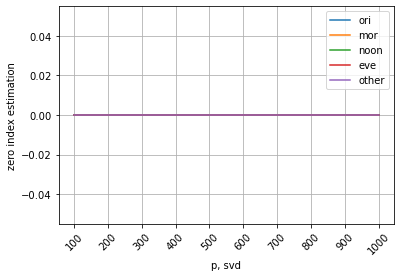

In [222]:
#SVD
k_svd_100 = (list(np.array(range(1, 11))*100))
test_k_svd_100 = fit_model_get_para(test_matrice_reverse, Zero_index, k_svd_100, 
                       missing_val, 288, 
                       result_para_dict, 'SVD',
                       True, True)

4

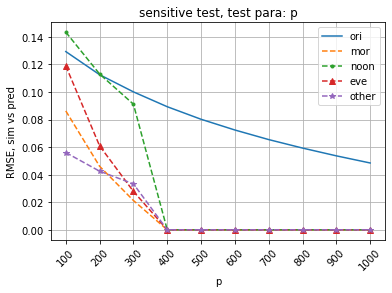

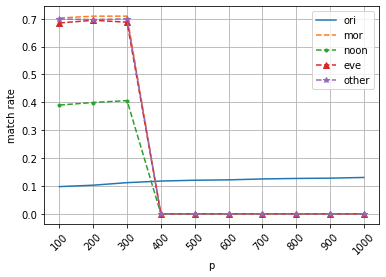

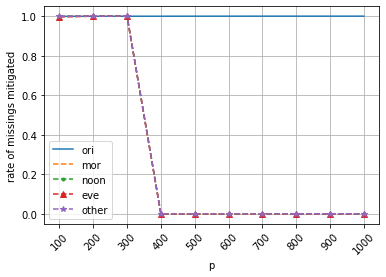

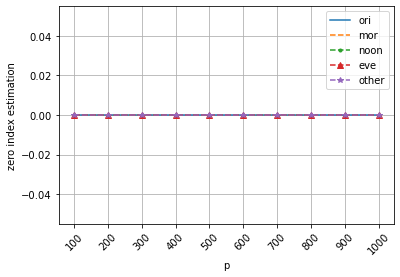

In [590]:
plot_paras_sensitive_svd(test_k_svd_100, k_svd_100, 'p', 0)

In [250]:
#NMF w0
k_nmf_100_w0 = generate_paralst(list(np.array(range(1, 11))*100), [0], [0.01, 0.01, 0.5, 0.8], 5)

test_k_nmf_100_w0 = fit_model_get_para_sensitive_w0(test_matrice_reverse, k_nmf_100_w0, missing_info,
                                             0.0, 288, result_para_dict_w0,
                                             Zero_index)


RMSE, data with missing rate>=0.0, para=[100, 0.01, 0.01, 0.5, 0.8], 0.14947637122036023
RMSE, zero, data with missing rate>=0.0, para=[100, 0.01, 0.01, 0.5, 0.8], 0.15394509661853883
zero_val, para=[100, 0.01, 0.01, 0.5, 0.8], 0.10520084624246984
matched % compared with raw dt 0.11129127147618843
% of missings mitigated 0.9995528054291131
RMSE, data with missing rate>=0.0, para=[100, 0.01, 0.01, 0.5, 0.8],mor, 0.1590977336928722
RMSE, zero, data with missing rate>=0.0, para=[100, 0.01, 0.01, 0.5, 0.8],mor, 0.16407154505710483
zero_val, para=[100, 0.01, 0.01, 0.5, 0.8], 0.21292456105091995
matched % compared with raw dtmor, 0.6948950688811639
% of missings mitigatedmor, 0.999214638206093
RMSE, data with missing rate>=0.0, para=[100, 0.01, 0.01, 0.5, 0.8],noon, 0.18114522682728992
RMSE, zero, data with missing rate>=0.0, para=[100, 0.01, 0.01, 0.5, 0.8],noon, 0.1878313470414037
zero_val, para=[100, 0.01, 0.01, 0.5, 0.8], 0.11262651640226828
matched % compared with raw dtnoon, 0.39533174

RMSE, data with missing rate>=0.0, para=[500, 0.01, 0.01, 0.5, 0.8],other, 0.0867354567336349
RMSE, zero, data with missing rate>=0.0, para=[500, 0.01, 0.01, 0.5, 0.8],other, 0.09053338701560748
zero_val, para=[500, 0.01, 0.01, 0.5, 0.8], 0.5673785205818632
matched % compared with raw dtother, 0.7059758014145457
% of missings mitigatedother, 0.9998226732193134
RMSE, data with missing rate>=0.0, para=[600, 0.01, 0.01, 0.5, 0.8], 0.1474743642173658
RMSE, zero, data with missing rate>=0.0, para=[600, 0.01, 0.01, 0.5, 0.8], 0.1523655435538041
zero_val, para=[600, 0.01, 0.01, 0.5, 0.8], 0.16918713911417227
matched % compared with raw dt 0.11730406777963749
% of missings mitigated 0.9995902758117375
RMSE, data with missing rate>=0.0, para=[600, 0.01, 0.01, 0.5, 0.8],mor, 0.15244329036107296
RMSE, zero, data with missing rate>=0.0, para=[600, 0.01, 0.01, 0.5, 0.8],mor, 0.15735450420541042
zero_val, para=[600, 0.01, 0.01, 0.5, 0.8], 0.3443078216067089
matched % compared with raw dtmor, 0.70009

RMSE, data with missing rate>=0.0, para=[1000, 0.01, 0.01, 0.5, 0.8],eve, 0.19861010997300807
RMSE, zero, data with missing rate>=0.0, para=[1000, 0.01, 0.01, 0.5, 0.8],eve, 0.20308339421663674
zero_val, para=[1000, 0.01, 0.01, 0.5, 0.8], 0.30124289841583773
matched % compared with raw dteve, 0.6845408228954
% of missings mitigatedeve, 0.999825085125239
RMSE, data with missing rate>=0.0, para=[1000, 0.01, 0.01, 0.5, 0.8],other, 0.08675270797921901
RMSE, zero, data with missing rate>=0.0, para=[1000, 0.01, 0.01, 0.5, 0.8],other, 0.09060708878119147
zero_val, para=[1000, 0.01, 0.01, 0.5, 0.8], 0.5795109873104303
matched % compared with raw dtother, 0.7047085199407963
% of missings mitigatedother, 0.9998702782171903


[[100, 0.01, 0.01, 0.5, 0.8],
 [200, 0.01, 0.01, 0.5, 0.8],
 [300, 0.01, 0.01, 0.5, 0.8],
 [400, 0.01, 0.01, 0.5, 0.8],
 [500, 0.01, 0.01, 0.5, 0.8],
 [600, 0.01, 0.01, 0.5, 0.8],
 [700, 0.01, 0.01, 0.5, 0.8],
 [800, 0.01, 0.01, 0.5, 0.8],
 [900, 0.01, 0.01, 0.5, 0.8],
 [1000, 0.01, 0.01, 0.5, 0.8]]

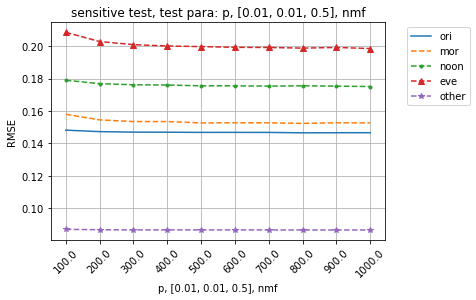

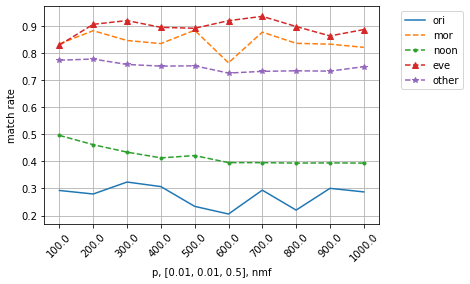

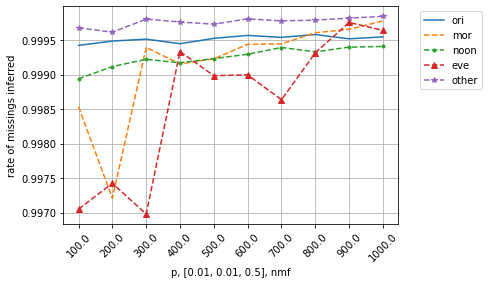

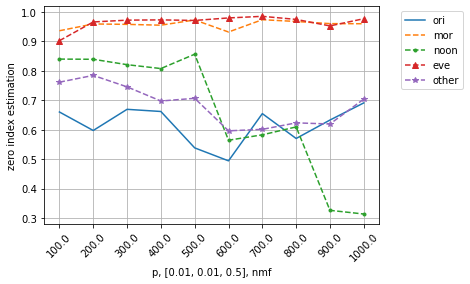

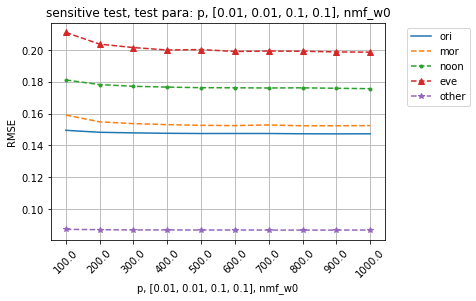

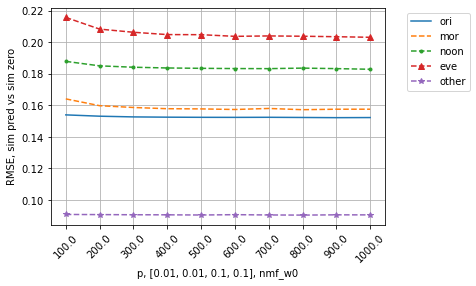

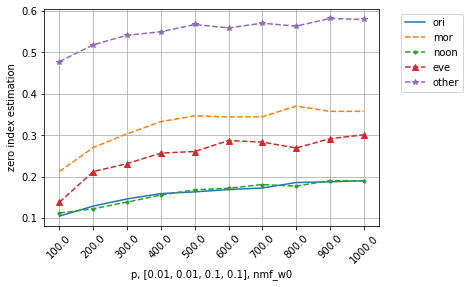

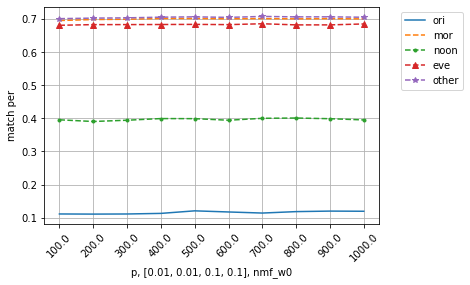

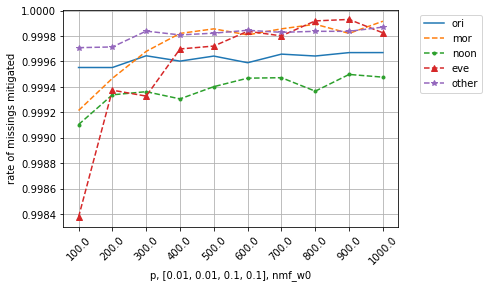

In [575]:
idx = plot_paras_sensitive(test_k_nmf_100_r, k_nmf_100_r, 'p, '+'[0.01, 0.01, 0.5], nmf', 0, 1)
#idx = plot_paras_sensitive(test_k_bmf_100, k_bmf_100, 'p, BMF', 0, idx)
#idx = plot_paras_sensitive_svd(test_k_svd_100, k_svd_100, 'p, svd', idx)
idx = plot_paras_sensitive_w0(test_k_nmf_100_w0, k_nmf_100_w0, 'p, [0.01, 0.01, 0.1, 0.1], nmf_w0', 0, idx)

In [318]:
np.array(k_nmf_100_r)[:, 0]

array([ 100.,  200.,  300.,  400.,  500.,  600.,  700.,  800.,  900.,
       1000.])

0.96875
0.003472222222222222
RMSE, data with missing rate>=0.0, para=[10, 0, 0, 0], 0.15262221267268672
matched % compared with raw dt 0.14031094874325853
% of missings mitigated 0.9981565598130039


C:\Users\Yiran\anaconda3\lib\site-packages\sklearn\decomposition\_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


RMSE, data with missing rate>=0.0, para=[10, 0, 0, 0],mor, 0.17146079054058816
matched % compared with raw dtmor, 0.688668583608715
% of missings mitigatedmor, 0.9955199191287966
RMSE, data with missing rate>=0.0, para=[10, 0, 0, 0],noon, 0.1871126117770066
matched % compared with raw dtnoon, 0.3850974743573237
% of missings mitigatednoon, 0.9980217714197225
RMSE, data with missing rate>=0.0, para=[10, 0, 0, 0],eve, 0.22869771052579024
matched % compared with raw dteve, 0.6771064393312366
% of missings mitigatedeve, 0.9954657826082003
RMSE, data with missing rate>=0.0, para=[10, 0, 0, 0],other, 0.08995138778486682
matched % compared with raw dtother, 0.7027347104245871
% of missings mitigatedother, 0.9977127271165328
RMSE, data with missing rate>=0.0, para=[20, 0, 0, 0], 0.1508558776304644
matched % compared with raw dt 0.17169685135115803
% of missings mitigated 0.999194744466297
RMSE, data with missing rate>=0.0, para=[20, 0, 0, 0],mor, 0.16624786431274752
matched % compared with raw

C:\Users\Yiran\anaconda3\lib\site-packages\sklearn\decomposition\_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


RMSE, data with missing rate>=0.0, para=[20, 0, 0, 0],eve, 0.22350999217855938
matched % compared with raw dteve, 0.6974084496680093
% of missings mitigatedeve, 0.996851370079506
RMSE, data with missing rate>=0.0, para=[20, 0, 0, 0],other, 0.08677378828288679
matched % compared with raw dtother, 0.7266023768709958
% of missings mitigatedother, 0.9992877742361087
RMSE, data with missing rate>=0.0, para=[30, 0, 0, 0], 0.1489053804761244
matched % compared with raw dt 0.16840657768622233
% of missings mitigated 0.9991199814212327


...

RMSE, data with missing rate>=0.0, para=[290, 0.01, 0.01, 0],noon, 0.17163566851254128
matched % compared with raw dtnoon, 0.4618846830608128
% of missings mitigatednoon, 0.99951400173464
RMSE, data with missing rate>=0.0, para=[290, 0.01, 0.01, 0],eve, 0.20004473851524537
matched % compared with raw dteve, 0.8046570656072394
% of missings mitigatedeve, 0.9997175300830462
RMSE, data with missing rate>=0.0, para=[290, 0.01, 0.01, 0],other, 0.08382935941751576
matched % compared with raw dtother, 0.7472332085204728
% of missings mitigatedother, 0.9998779214656159


C:\Users\Yiran\anaconda3\lib\site-packages\sklearn\decomposition\_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0], 0.14413884224844542
matched % compared with raw dt 0.29246598858418094
% of missings mitigated 0.9996720752141937
RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0],mor, 0.15058318191903272
matched % compared with raw dtmor, 0.7191501080068095
% of missings mitigatedmor, 0.9998726585083217


C:\Users\Yiran\anaconda3\lib\site-packages\sklearn\decomposition\_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0],noon, 0.17147292144716103
matched % compared with raw dtnoon, 0.45373320887515556
% of missings mitigatednoon, 0.999535984522997
RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0],eve, 0.19982109335326909
matched % compared with raw dteve, 0.8052051720649634
% of missings mitigatedeve, 0.9996223137062356
RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0],other, 0.08377101824188987
matched % compared with raw dtother, 0.7475417825149206
% of missings mitigatedother, 0.9998356247523834


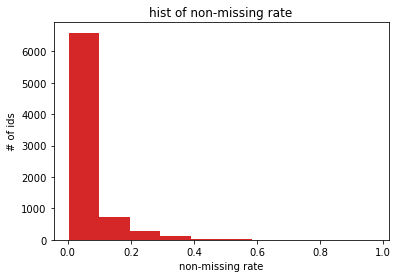

In [583]:
#sensitive test
#nmf
k_nmf_ori = generate_paralst(list(np.array(range(1, 31))*10), [0], [0, 0, 0], 4)
k_nmf_r1 = generate_paralst(list(np.array(range(1, 31))*10), [0], [0.01, 0.01, 0.5], 4)
k_nmf_r2 = generate_paralst(list(np.array(range(1, 31))*10), [0], [0.01, 0.01, 1], 4)
k_nmf_r3 = generate_paralst(list(np.array(range(1, 31))*10), [0], [0.01, 0.01, 0], 4)

#test of k
test_k_nmf_ori = fit_model_get_para_sensitive(test_matrice_reverse, Zero_index, k_nmf_ori, 
                                              missing_val, 288, result_para_dict, 'NMF', True)
test_k_nmf_ori_r1 = fit_model_get_para_sensitive(test_matrice_reverse, Zero_index, k_nmf_r1, 
                                              missing_val, 288, result_para_dict, 'NMF', True)
test_k_nmf_ori_r2 = fit_model_get_para_sensitive(test_matrice_reverse, Zero_index, k_nmf_r2, 
                                              missing_val, 288, result_para_dict, 'NMF', True)
test_k_nmf_ori_r3 = fit_model_get_para_sensitive(test_matrice_reverse, Zero_index, k_nmf_r3, 
                                              missing_val, 288, result_para_dict, 'NMF', True)


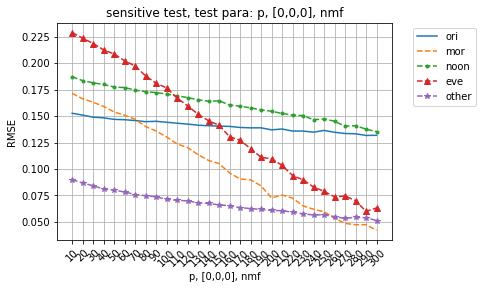

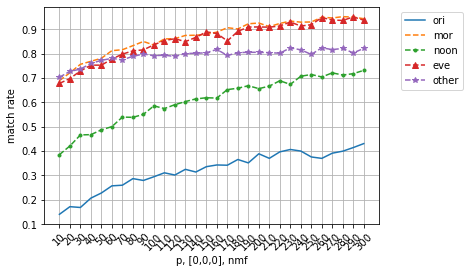

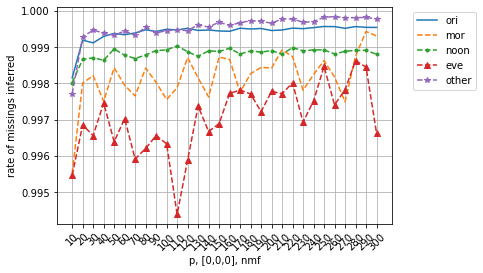

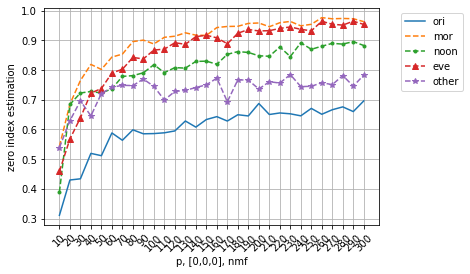

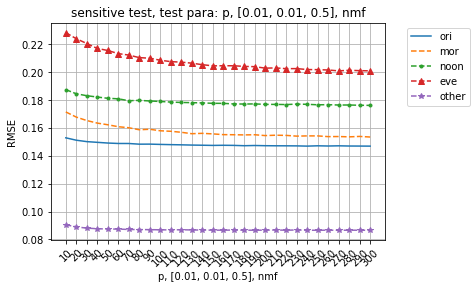

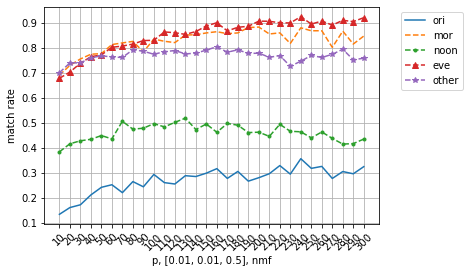

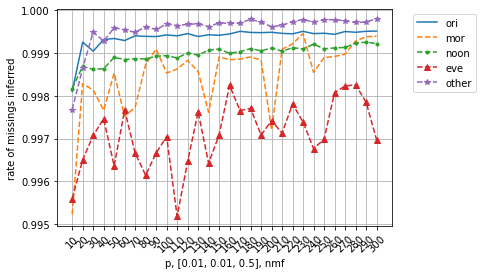

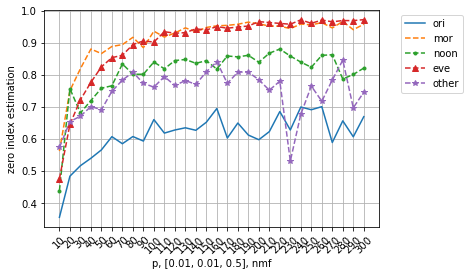

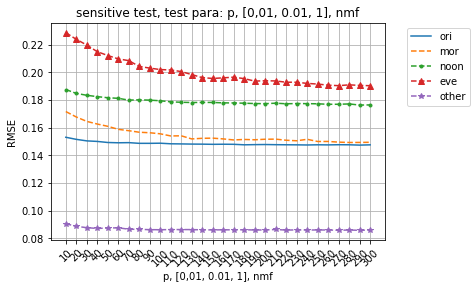

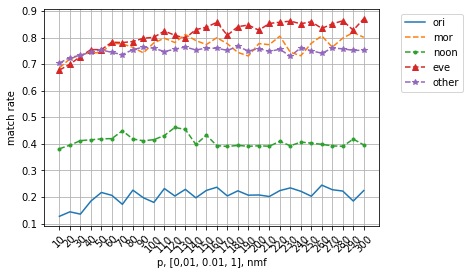

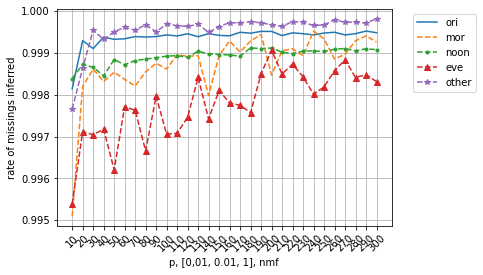

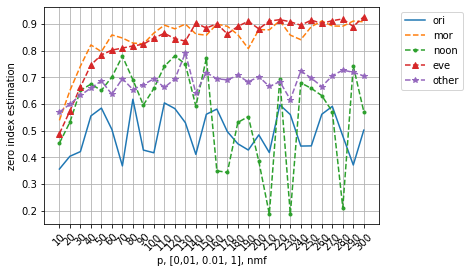

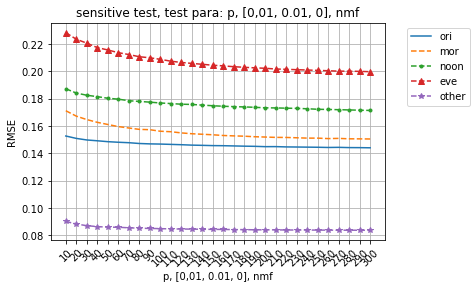

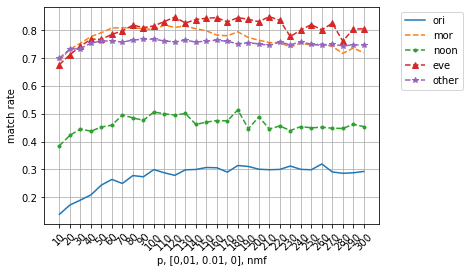

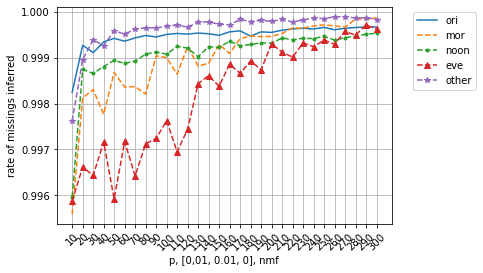

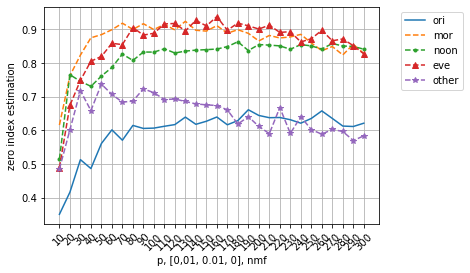

In [607]:
idx = plot_paras_sensitive(test_k_nmf_ori, k_nmf_ori, 'p, [0,0,0], nmf', 0, 1) # nmf with all zeros
idx = plot_paras_sensitive(test_k_nmf_ori_r1, k_nmf_r1, 'p, [0.01, 0.01, 0.5], nmf', 0, idx)
idx = plot_paras_sensitive(test_k_nmf_ori_r2, k_nmf_r2, 'p, [0,01, 0.01, 1], nmf', 0, idx)
idx = plot_paras_sensitive(test_k_nmf_ori_r3, k_nmf_r3, 'p, [0,01, 0.01, 0], nmf', 0, idx)

if pred & fit dt is equal, with tol=0.01: False
RMSE, data with missing rate>=0.0, k=10, 0.15167411629794555
matched % compared with raw dt 0.02512007710684806
% of missings mitigated 0.9998908609830307
if pred & fit dt is equal, with tol=0.01: False
RMSE, data with missing rate>=0.0, k=10,mor, 0.16367598072612427
matched % compared with raw dtmor, 0.6493498133127333
% of missings mitigatedmor, 0.9996532239968994
if pred & fit dt is equal, with tol=0.01: False
RMSE, data with missing rate>=0.0, k=10,noon, 0.18611027858998594
matched % compared with raw dtnoon, 0.3313631925668426
% of missings mitigatednoon, 0.9999057279308083
if pred & fit dt is equal, with tol=0.01: False
RMSE, data with missing rate>=0.0, k=10,eve, 0.21607944867533416
matched % compared with raw dteve, 0.6234876492118671
% of missings mitigatedeve, 0.9994626439869863
if pred & fit dt is equal, with tol=0.01: False
RMSE, data with missing rate>=0.0, k=10,other, 0.08460165008296942
matched % compared with raw dtother, 

if pred & fit dt is equal, with tol=0.01: False
RMSE, data with missing rate>=0.0, k=80,other, 0.05995487689752508
matched % compared with raw dtother, 0.7003959323563242
% of missings mitigatedother, 0.9993962424974252
if pred & fit dt is equal, with tol=0.01: False
RMSE, data with missing rate>=0.0, k=90, 0.13144947656344674
matched % compared with raw dt 0.10138289844498806
% of missings mitigated 0.9987179825213807
if pred & fit dt is equal, with tol=0.01: False
RMSE, data with missing rate>=0.0, k=90,mor, 0.09168753174231677
matched % compared with raw dtmor, 0.7016544354319557
% of missings mitigatedmor, 0.9980340681602954
if pred & fit dt is equal, with tol=0.01: False
RMSE, data with missing rate>=0.0, k=90,noon, 0.1471388306517614
matched % compared with raw dtnoon, 0.38743106519033516
% of missings mitigatednoon, 0.9988308728388116
if pred & fit dt is equal, with tol=0.01: False
RMSE, data with missing rate>=0.0, k=90,eve, 0.12672424462410511
matched % compared with raw dteve

if pred & fit dt is equal, with tol=0.01: False
RMSE, data with missing rate>=0.0, k=160,eve, 0.07877910369861924
matched % compared with raw dteve, 0.6932553477165296
% of missings mitigatedeve, 0.9993164402125031
if pred & fit dt is equal, with tol=0.01: False
RMSE, data with missing rate>=0.0, k=160,other, 0.04705400926294471
matched % compared with raw dtother, 0.6980443857089806
% of missings mitigatedother, 0.9997603777574178
if pred & fit dt is equal, with tol=0.01: False
RMSE, data with missing rate>=0.0, k=170, 0.11719529976447499
matched % compared with raw dt 0.09803406148520093
% of missings mitigated 0.999345262995117
if pred & fit dt is equal, with tol=0.01: False
RMSE, data with missing rate>=0.0, k=170,mor, 0.05596960776620254
matched % compared with raw dtmor, 0.7077521708653419
% of missings mitigatedmor, 0.999510499779725
if pred & fit dt is equal, with tol=0.01: False
RMSE, data with missing rate>=0.0, k=170,noon, 0.12084462087542949
matched % compared with raw dtno

5

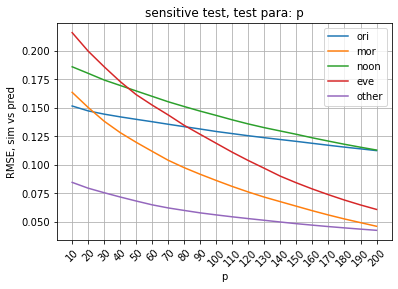

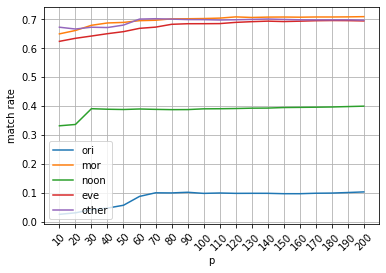

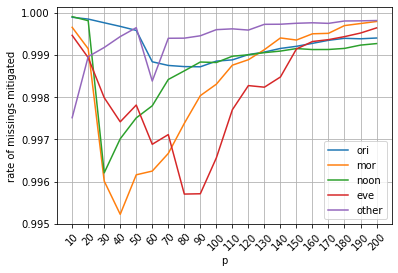

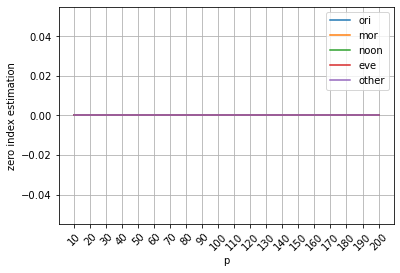

In [585]:
#svd
k_svd_10_200 = list(np.array(range(1, 21))*10)
test_k_svd_10_200 = fit_model_get_para(test_matrice_reverse, Zero_index, k_svd_10_200, 
                                       missing_val, 288, result_para_dict, 'SVD',
                                       True, True)


5

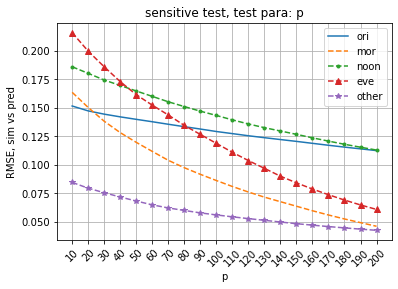

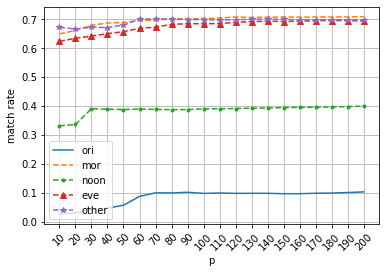

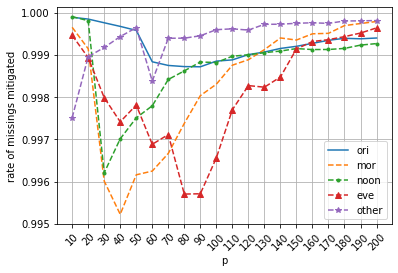

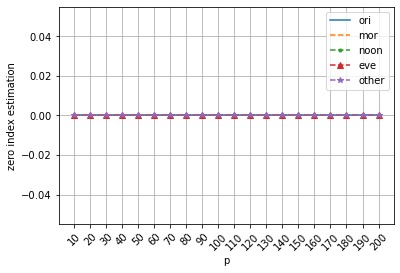

In [591]:
plot_paras_sensitive_svd(test_k_svd_10_200, k_svd_10_200, 'p',1)

In [608]:
#nmf w0
lzero_r = generate_paralst(list(np.round(np.array(range(1, 21))*10,1)), [4], [300, 0.01, 0.01 ,0.5], 5)

test_lzero_r = fit_model_get_para_sensitive_w0(test_matrice_reverse, lzero_r, missing_info,
                                             0.0, 288, result_para_dict_w0,
                                             Zero_index)

RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 10], 0.1506649873916635
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 10], 0.1545706200475518
zero_val, para=[300, 0.01, 0.01, 0.5, 10], 0.10932071089821227
matched % compared with raw dt 0.11164622762971546
% of missings mitigated 0.9996814541392091
RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 10],mor, 0.15650118998865511
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 10],mor, 0.16220955707358448
zero_val, para=[300, 0.01, 0.01, 0.5, 10], 0.313905687610765
matched % compared with raw dtmor, 0.6988648555855972
% of missings mitigatedmor, 0.9995130699160343
RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 10],noon, 0.18180158431121474
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 10],noon, 0.1896374109725601
zero_val, para=[300, 0.01, 0.01, 0.5, 10], 0.1261215993108894
matched % compared with raw dtnoon, 0.392044601090082
% of

RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 50],other, 0.08968298931883656
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 50],other, 0.09245605579720105
zero_val, para=[300, 0.01, 0.01, 0.5, 50], 0.4669761683689261
matched % compared with raw dtother, 0.6984412757087359
% of missings mitigatedother, 0.9998200467878352
RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 60], 0.1532227797038548
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 60], 0.15562316895009
zero_val, para=[300, 0.01, 0.01, 0.5, 60], 0.10065831483219445
matched % compared with raw dt 0.11073380255496904
% of missings mitigated 0.9996898244315794
RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 60],mor, 0.16259110719313058
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 60],mor, 0.16872224852195145
zero_val, para=[300, 0.01, 0.01, 0.5, 60], 0.33296183289788606
matched % compared with raw dtmor, 0.69892923050512

RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 100],eve, 0.21740622936273907
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 100],eve, 0.22313984779360843
zero_val, para=[300, 0.01, 0.01, 0.5, 100], 0.27535726058208754
matched % compared with raw dteve, 0.6789273299122662
% of missings mitigatedeve, 0.9998396003757934
RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 100],other, 0.09044354372918241
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 100],other, 0.09277390163884705
zero_val, para=[300, 0.01, 0.01, 0.5, 100], 0.4421231816774992
matched % compared with raw dtother, 0.6972474135647
% of missings mitigatedother, 0.999806698087014
RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 110], 0.15391457140862463
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 110], 0.15588008994687583
zero_val, para=[300, 0.01, 0.01, 0.5, 110], 0.09952893108486738
matched % compared with raw dt 0.11

RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 150],noon, 0.19055856192905787
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 150],noon, 0.19484212013848198
zero_val, para=[300, 0.01, 0.01, 0.5, 150], 0.12288717080400458
matched % compared with raw dtnoon, 0.392377204840994
% of missings mitigatednoon, 0.9994393715664267
RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 150],eve, 0.21962992899502853
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 150],eve, 0.22500525923958958
zero_val, para=[300, 0.01, 0.01, 0.5, 150], 0.27733503965253137
matched % compared with raw dteve, 0.6779598668358807
% of missings mitigatedeve, 0.9997258552744303
RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 150],other, 0.09084721325842832
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 150],other, 0.092983513494886
zero_val, para=[300, 0.01, 0.01, 0.5, 150], 0.4339007531208088
matched % compared with ra

matched % compared with raw dt 0.11113033417736005
% of missings mitigated 0.9996801302010905
RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 200],mor, 0.16920536370369063
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 200],mor, 0.17412781683167974
zero_val, para=[300, 0.01, 0.01, 0.5, 200], 0.34343083697221055
matched % compared with raw dtmor, 0.6980458635537816
% of missings mitigatedmor, 0.9993841051758854
RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 200],noon, 0.19122874257976336
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 200],noon, 0.19509541977505263
zero_val, para=[300, 0.01, 0.01, 0.5, 200], 0.12393434870179498
matched % compared with raw dtnoon, 0.39268835028539545
% of missings mitigatednoon, 0.9994346676795537
RMSE, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 200],eve, 0.22203915607871264
RMSE, zero, data with missing rate>=0.0, para=[300, 0.01, 0.01, 0.5, 200],eve, 0.2272019384480

6

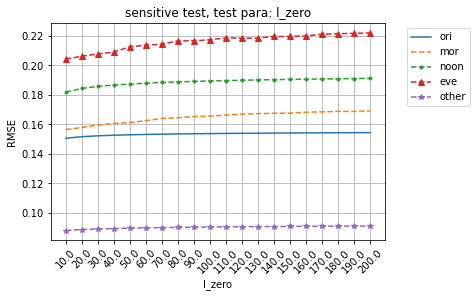

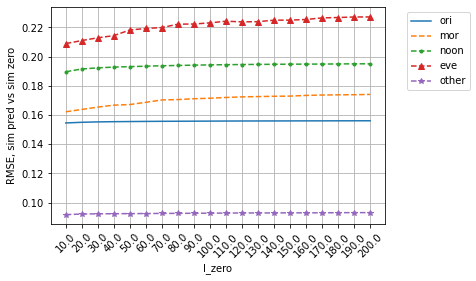

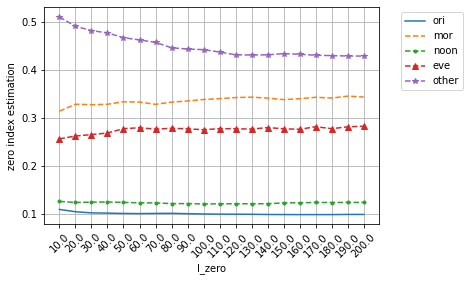

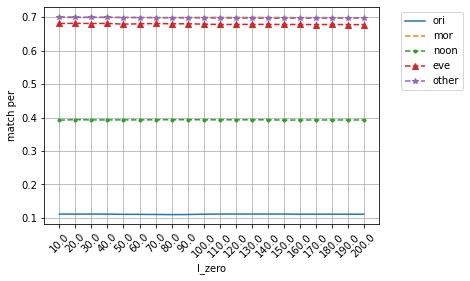

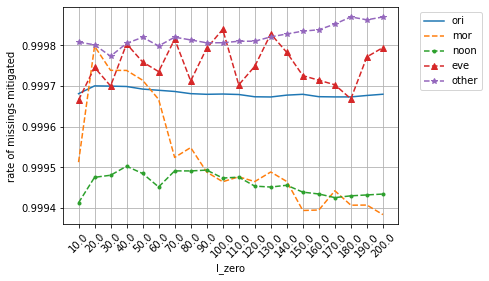

In [609]:
plot_paras_sensitive_w0(test_lzero_r, lzero_r, 'l_zero', 4, 1)

RMSE, data with missing rate>=0.0, para=[300, 0, 0, 0, 0.5], 0.13481410456331802
RMSE, zero, data with missing rate>=0.0, para=[300, 0, 0, 0, 0.5], 0.13912831040000936
zero_val, para=[300, 0, 0, 0, 0.5], 0.12512072135126107
matched % compared with raw dt 0.12370981932105918
% of missings mitigated 0.9996668656290015
RMSE, data with missing rate>=0.0, para=[300, 0, 0, 0, 0.5],mor, 0.04745244030169262
RMSE, zero, data with missing rate>=0.0, para=[300, 0, 0, 0, 0.5],mor, 0.048145939462766935
zero_val, para=[300, 0, 0, 0, 0.5], 0.40193302029854017
matched % compared with raw dtmor, 0.7001487775918058
% of missings mitigatedmor, 0.9998568736432815
RMSE, data with missing rate>=0.0, para=[300, 0, 0, 0, 0.5],noon, 0.13832889644052365
RMSE, zero, data with missing rate>=0.0, para=[300, 0, 0, 0, 0.5],noon, 0.1430043424207604
zero_val, para=[300, 0, 0, 0, 0.5], 0.1413943511508401
matched % compared with raw dtnoon, 0.3942400540749324
% of missings mitigatednoon, 0.9994686433135404
RMSE, data wi

RMSE, data with missing rate>=0.0, para=[300, 0, 0, 0, 3.0], 0.143089737350497
RMSE, zero, data with missing rate>=0.0, para=[300, 0, 0, 0, 3.0], 0.14730873201344613
zero_val, para=[300, 0, 0, 0, 3.0], 0.13278326057859902
matched % compared with raw dt 0.13439203253079268
% of missings mitigated 0.9996095595925165
RMSE, data with missing rate>=0.0, para=[300, 0, 0, 0, 3.0],mor, 0.05850854299311435
RMSE, zero, data with missing rate>=0.0, para=[300, 0, 0, 0, 3.0],mor, 0.06012409321259126
zero_val, para=[300, 0, 0, 0, 3.0], 0.4103009153527123
matched % compared with raw dtmor, 0.7000736735190192
% of missings mitigatedmor, 0.9997972884347089
RMSE, data with missing rate>=0.0, para=[300, 0, 0, 0, 3.0],noon, 0.15042646659829265
RMSE, zero, data with missing rate>=0.0, para=[300, 0, 0, 0, 3.0],noon, 0.1560204248299027
zero_val, para=[300, 0, 0, 0, 3.0], 0.1412887888627563
matched % compared with raw dtnoon, 0.39358423458220676
% of missings mitigatednoon, 0.9994647947753355
RMSE, data with 

RMSE, data with missing rate>=0.0, para=[300, 0, 0, 0, 5.5], 0.1462728062730699
RMSE, zero, data with missing rate>=0.0, para=[300, 0, 0, 0, 5.5], 0.1500700561167378
zero_val, para=[300, 0, 0, 0, 5.5], 0.13623731147585683
matched % compared with raw dt 0.140230033045792
% of missings mitigated 0.9996110681275531
RMSE, data with missing rate>=0.0, para=[300, 0, 0, 0, 5.5],mor, 0.0669049772156823
RMSE, zero, data with missing rate>=0.0, para=[300, 0, 0, 0, 5.5],mor, 0.0687927874122642
zero_val, para=[300, 0, 0, 0, 5.5], 0.4147223795516416
matched % compared with raw dtmor, 0.7018797476503155
% of missings mitigatedmor, 0.9997840639170805
RMSE, data with missing rate>=0.0, para=[300, 0, 0, 0, 5.5],noon, 0.1547950819436194
RMSE, zero, data with missing rate>=0.0, para=[300, 0, 0, 0, 5.5],noon, 0.16082568005860226
zero_val, para=[300, 0, 0, 0, 5.5], 0.14242886157406043
matched % compared with raw dtnoon, 0.3932958885884726
% of missings mitigatednoon, 0.999442943732896
RMSE, data with missi

RMSE, data with missing rate>=0.0, para=[300, 0, 0, 0, 8.0], 0.1478860976083254
RMSE, zero, data with missing rate>=0.0, para=[300, 0, 0, 0, 8.0], 0.15139624322025305
zero_val, para=[300, 0, 0, 0, 8.0], 0.1396777279616782
matched % compared with raw dt 0.14415645608915212
% of missings mitigated 0.9995988368357629
RMSE, data with missing rate>=0.0, para=[300, 0, 0, 0, 8.0],mor, 0.07561422664997026
RMSE, zero, data with missing rate>=0.0, para=[300, 0, 0, 0, 8.0],mor, 0.0782142089639791
zero_val, para=[300, 0, 0, 0, 8.0], 0.4193630899091956
matched % compared with raw dtmor, 0.7022445388609931
% of missings mitigatedmor, 0.9997717882194677
RMSE, data with missing rate>=0.0, para=[300, 0, 0, 0, 8.0],noon, 0.15715058034456333
RMSE, zero, data with missing rate>=0.0, para=[300, 0, 0, 0, 8.0],noon, 0.16352565927685989
zero_val, para=[300, 0, 0, 0, 8.0], 0.14274132594678812
matched % compared with raw dtnoon, 0.39323956053388265
% of missings mitigatednoon, 0.9994496264532956
RMSE, data with

C:\Users\Yiran\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


RMSE, data with missing rate>=0.0, para=[300, 0, 0, 0, 10.0], 0.14885806785219255
RMSE, zero, data with missing rate>=0.0, para=[300, 0, 0, 0, 10.0], 0.15212095493316613
zero_val, para=[300, 0, 0, 0, 10.0], 0.14243187907186017
matched % compared with raw dt 0.14630362788435403
% of missings mitigated 0.9995973041898168
RMSE, data with missing rate>=0.0, para=[300, 0, 0, 0, 10.0],mor, 0.07954891576165306
RMSE, zero, data with missing rate>=0.0, para=[300, 0, 0, 0, 10.0],mor, 0.08257493542786996
zero_val, para=[300, 0, 0, 0, 10.0], 0.4205506732684121
matched % compared with raw dtmor, 0.7024269344663319
% of missings mitigatedmor, 0.9997596298299382
RMSE, data with missing rate>=0.0, para=[300, 0, 0, 0, 10.0],noon, 0.15846064568216614
RMSE, zero, data with missing rate>=0.0, para=[300, 0, 0, 0, 10.0],noon, 0.1649085127553393
zero_val, para=[300, 0, 0, 0, 10.0], 0.14302001038732914
matched % compared with raw dtnoon, 0.39311215183897685
% of missings mitigatednoon, 0.9994475321260069
RMSE

6

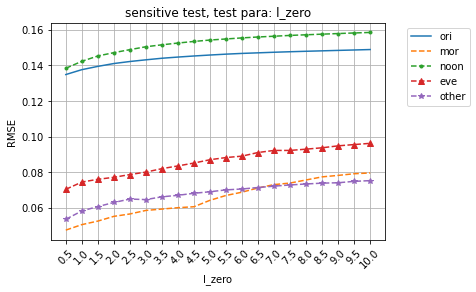

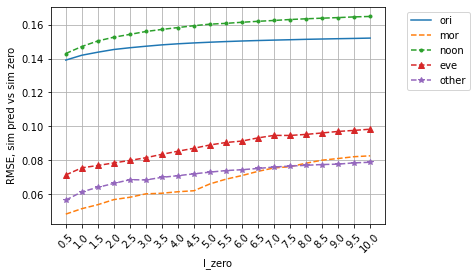

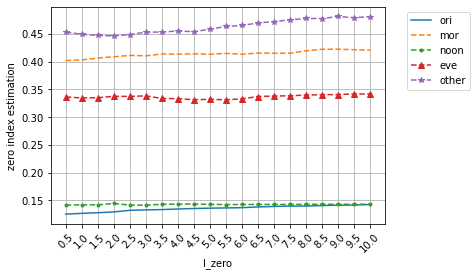

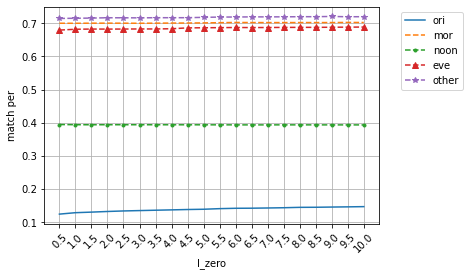

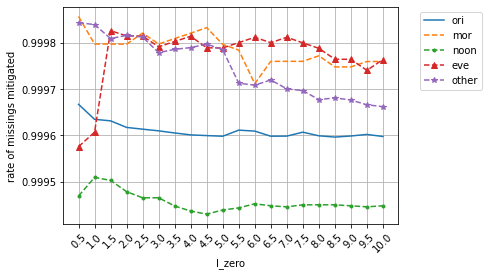

In [610]:
lzero = generate_paralst(list(np.round(np.array(range(1, 21))*0.5, 1)), [4], [300, 0, 0, 0], 5)

test_lzero = fit_model_get_para_sensitive_w0(test_matrice_reverse, lzero, missing_info,
                                             0.0, 288, result_para_dict_w0,
                                             Zero_index)

plot_paras_sensitive_w0(test_lzero, lzero, 'l_zero', 4, 1)

In [ ]:
k_nmf_w0 = generate_paralst(list(np.array(range(1, 31))*10), [0], [0, 0, 0, 0.5], 4)

test_k_nmf_w0 = fit_model_get_para_sensitive_w0(test_matrice_reverse, k_nmf_w0, missing_info,
                                             0.0, 288, result_para_dict_w0,
                                             Zero_index)

plot_paras_sensitive_w0(test_k_nmf_w0 , k_nmf_w0, 'l_zero', 4, 1)

6

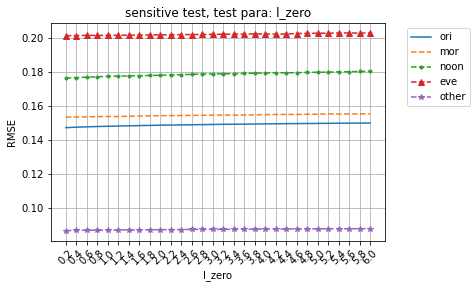

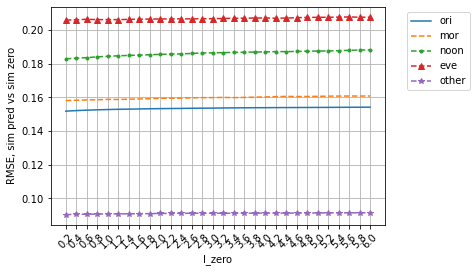

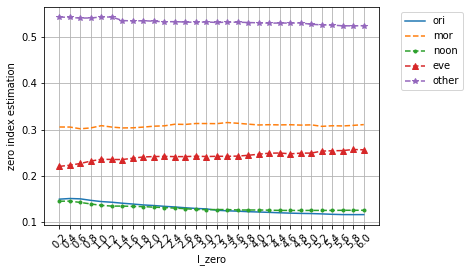

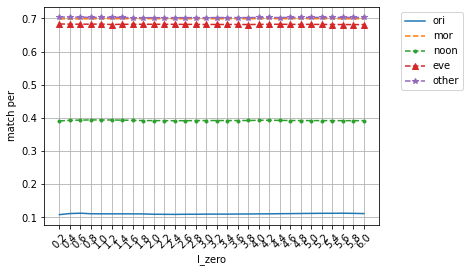

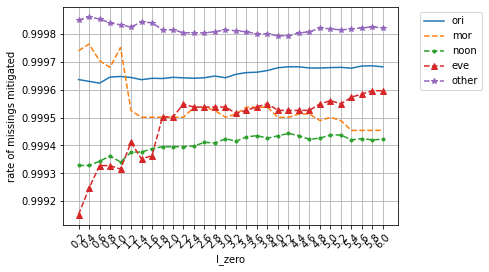

In [594]:
k_nmf_w0 = generate_paralst(list(np.array(range(1, 31))*10), [0], [0.01, 0.01, 0.5, 0.5], 4)

test_k_nmf_w0 = fit_model_get_para_sensitive_w0(test_matrice_reverse, k_nmf_w0, missing_info,
                                             0.0, 288, result_para_dict_w0,
                                             Zero_index)

plot_paras_sensitive_w0(test_k_nmf_w0 , k_nmf_w0, 'l_zero', 4, 1)

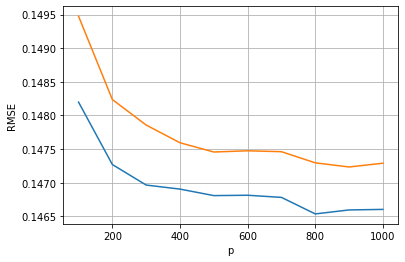

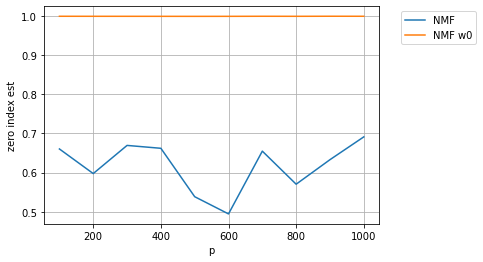

In [328]:
plt.figure(1)
plt.plot(np.array(k_nmf_100_r)[:, 0], test_k_nmf_100_r['ori']['rmse_predvsraw'], label= 'NMF')
plt.plot(np.array(k_nmf_100_r)[:, 0], test_k_nmf_100_w0['ori']['rmse_predvssim'], label = 'NMF w0')
plt.ylabel('RMSE')
plt.xlabel('p')
#plt.legend()
plt.grid()

plt.figure(2)
plt.plot(np.array(k_nmf_100_r)[:, 0], test_k_nmf_100_r['ori']['zero index estimation'], label= 'NMF')
plt.plot(np.array(k_nmf_100_r)[:, 0], test_k_nmf_100['ori']['per of zero val'], label = 'NMF w0')
plt.ylabel('zero index est')
plt.xlabel('p')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.grid()

In [564]:
test_k_nmf_ori

{'ori': {'rmse_predvsraw': [0.15262221267268672,
   0.1508558776304644,
   0.1489053804761244,
   0.14829839521175295,
   0.1468548106641592,
   0.1465254780720811,
   0.14576479921016589,
   0.14467463754471524,
   0.14503890388832444,
   0.14411795470362854,
   0.14324116360928232,
   0.14238621515492061,
   0.14133927896152645,
   0.14085760315530216,
   0.14049809267794303,
   0.1402163848201021,
   0.13921350969163,
   0.13884817620218415,
   0.13886723483848995,
   0.13697870972675333],
  'match per': [0.14031094874325853,
   0.17169685135115803,
   0.16840657768622233,
   0.20680800537888216,
   0.22788319170851037,
   0.25712326366536487,
   0.25973402429080295,
   0.28673840893809993,
   0.2792396249088022,
   0.29439544797791223,
   0.31059646939330215,
   0.3015280996523754,
   0.3248456790123457,
   0.31384606168547846,
   0.33578583894825687,
   0.342753529891421,
   0.3417347073802269,
   0.3652141181351301,
   0.3512630895669714,
   0.38865821209390156],
  'per of missin

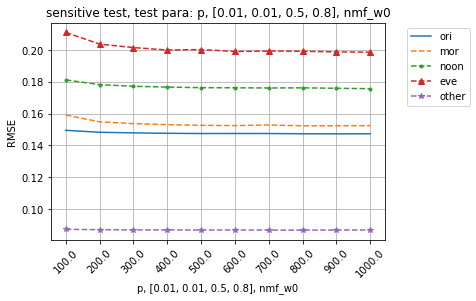

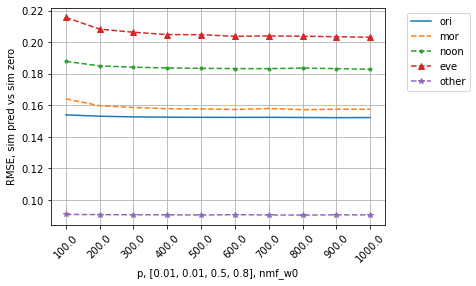

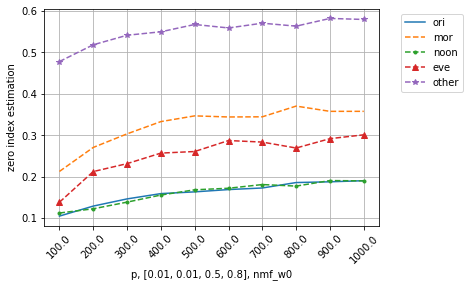

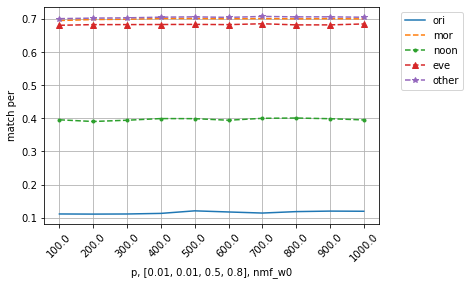

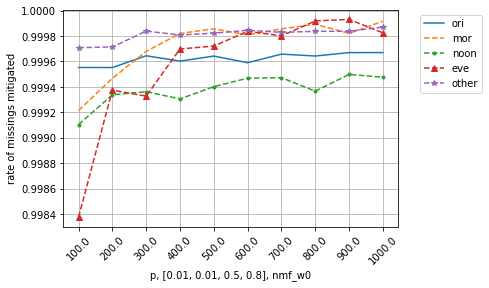

In [277]:
idx = plot_paras_sensitive_w0(test_k_nmf_100_w0, k_nmf_100_w0, 'p, [0.01, 0.01, 0.5, 0.8], nmf_w0', 0, idx)

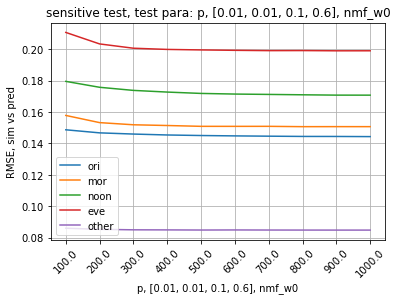

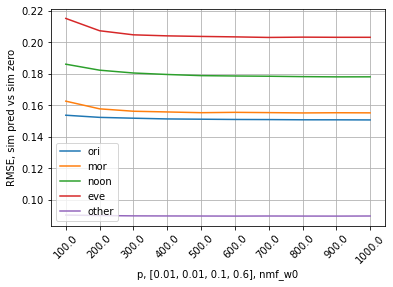

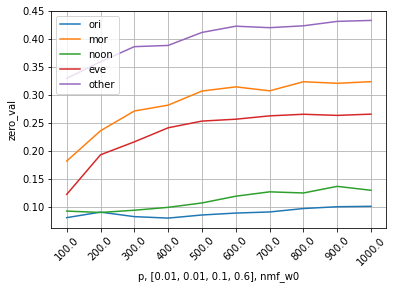

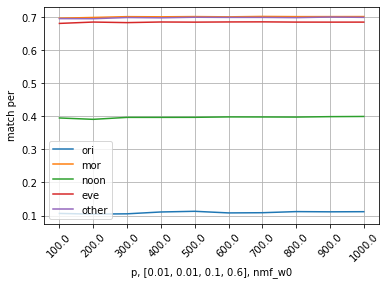

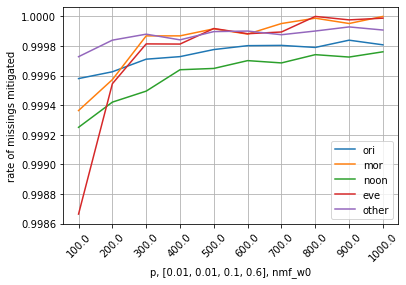

In [238]:
idx = plot_paras_sensitive_w0(test_k_nmf_100_w0, k_nmf_100_w0, 'p, [0.01, 0.01, 0.5, 0.6], nmf_w0', 0, idx)

In [244]:
para_lst = [300, 0.01, 0.01, 0.1, 0.1]

model = NMF_w0(n_components=para_lst[0], init='random', random_state=0,
                   alpha_W = para_lst[1], alpha_H = para_lst[2],
                   l1_ratio = para_lst[3], zero_weight=para_lst[4], 
                   beta_loss='kullback-leibler',
                   solver="zero")
W = model.fit_transform_w0(test_matrice_reverse, Zero_index)
H = model.components_
WH = np.dot(W, H)
print(mean_squared_error(test_matrice_reverse, WH, squared=False))
WH_max_mmf_w0, WH_index_nmf_w0 = get_pred_dt(WH, 288)

0.14510010956400632


In [243]:
para_lst = [300, 0, 0, 0, 0.6]
model = NMF_w0(n_components=para_lst[0], init='random', random_state=0,
                   alpha_W = para_lst[1], alpha_H = para_lst[2],
                   l1_ratio = para_lst[3], zero_weight=para_lst[4], 
                   beta_loss='kullback-leibler',
                   solver="zero")
W = model.fit_transform_w0(test_matrice_reverse, Zero_index)
H = model.components_
WH = np.dot(W, H)
print(mean_squared_error(test_matrice_reverse, WH, squared=False))
WH_max_mmf_w02, WH_index_nmf_w02 = get_pred_dt(WH, 288)

0.1354971020180701


In [ ]:
para_lst = [300, 0.01, 0.01, 0.1]

model = NMF(n_components=para_lst[0], init='random', random_state=0,
                   alpha_W = para_lst[1], alpha_H = para_lst[2],
                   l1_ratio = para_lst[3], 
                   beta_loss='kullback-leibler',
                   solver="mu")
W = model.fit_transform(test_matrice_reverse)
H = model.components_
WH = np.dot(W, H)
print(mean_squared_error(test_matrice_reverse, WH, squared=False))
WH_max_nmf, WH_index_nmf = get_pred_dt(WH, 288)

In [373]:
para_lst = [300, 0, 0, 0]

model = NMF(n_components=para_lst[0], init='random', random_state=0,
                   alpha_W = para_lst[1], alpha_H = para_lst[2],
                   l1_ratio = para_lst[3], 
                   beta_loss='kullback-leibler',
                   solver="mu")
W = model.fit_transform(test_matrice_reverse)
H = model.components_
WH = np.dot(W, H)
print(mean_squared_error(test_matrice_reverse, WH, squared=False))
WH_max_nmf2, WH_index_nmf2 = get_pred_dt(WH, 288)

C:\Users\Yiran\anaconda3\lib\site-packages\sklearn\decomposition\_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


0.1318137942522366


In [240]:
k_val =300
model = nimfa.Bmf(test_matrice_reverse, rank=k_val, max_iter=1000, lambda_w=1.1, lambda_h=1.1)
model_fit = model()
        
W = model_fit.fit.W
H = model_fit.fit.H

WH = np.dot(W, H)
print(mean_squared_error(test_matrice_reverse, WH, squared=False))
WH_max_bmf, WH_index_bmf = get_pred_dt(WH, 288)

C:\Users\Yiran\anaconda3\lib\site-packages\sklearn\utils\validation.py:593: FutureWarning: np.matrix usage is deprecated in 1.0 and will raise a TypeError in 1.2. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
  warnings.warn(


0.10613478782820825


In [235]:
u, s, v = svds(test_matrice_reverse, k=k_val)
svd_idx = 1
        
pred_dt = u @ np.diag(s) @ v        
print(mean_squared_error(test_matrice_reverse, pred_dt, squared=False))
WH_max_svd, WH_index_svd = get_pred_dt(pred_dt, 288)
del(u, s, v)

In [239]:
print(mean_squared_error(test_matrice_reverse, pred_dt, squared=False))

0.10004797761186247


In [245]:
Seattle_ct = pd.read_csv('G:/My Drive/2021/Bias/census_tract_process/Seattle_ct.csv')
ct_pop = Seattle_ct['pop'].values

In [249]:
WH_index_svd.shape

(7767, 288)

In [340]:
origin_WH_max, origin_WH_index = get_pred_dt(test_matrice_reverse, 288)

In [331]:
para_lst = [300, 0, 0, 0]
WH_max_nmf2, WH_index_nmf2

para_lst = [300, 0.01, 0.01, 0.1]
WH_max_nmf, WH_index_nmf

para_lst = [300, 0.01, 0.01, 0.1, 0.1]
WH_max_mmf_w0, WH_index_nmf_w0

para_lst = [300, 0, 0, 0, 0.6]
WH_max_mmf_w02

array([[ 9,  2,  2, ...,  8,  0,  0],
       [ 5,  2,  2, ...,  2,  0,  0],
       [ 8,  8,  7, ..., 11, 11,  8],
       ...,
       [ 1,  1,  1, ...,  5, 11,  5],
       [10, 10,  1, ...,  2,  6,  2],
       [ 7,  7,  7, ...,  5,  7,  5]], dtype=int64)

In [337]:
np.where(WH_max_nmf2>0.5)

(array([   0,    0,    0, ..., 7766, 7766, 7766], dtype=int64),
 array([ 80,  81,  82, ..., 193, 194, 195], dtype=int64))

In [388]:
def get_time_idx(WH_max, critieria):
    test = np.zeros(WH_max.shape)
    test[np.where(WH_max >= critieria)] = 1
    return(np.sum(test, axis=0))

array([16., 15., 13., ..., 13., 11., 13.])

112360

Text(0.5, 0, 'time (time interval = 5min)')

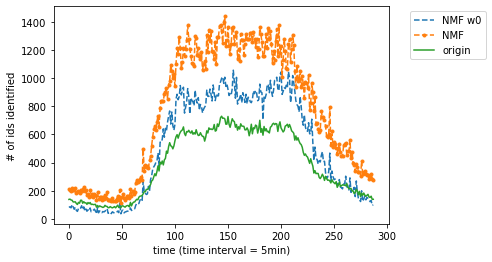

In [399]:
#plt.plot(get_time_idx(WH_max_mmf_w0, 0.3), label='NMF w0, wr')
plt.plot(get_time_idx(WH_max_mmf_w02, 0.2), label='NMF w0', linestyle='dashed')
#plt.plot(get_time_idx(WH_max_nmf, 0.5), label='NMF, wr')
plt.plot(get_time_idx(WH_max_nmf2, 0.2), label='NMF', linestyle='dashed', marker='.')
plt.plot(get_time_idx(origin_WH_max, 1), label='origin')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.ylabel('# of ids identified')
plt.xlabel('time (time interval = 5min)')

In [506]:
#between 22:00 - 6:00
def get_idx(unique_val):
    idx_lst =[]
    for i in unique_val:
        idx = i-1
        if idx != -1:
            idx_lst.append(int(idx))
    return(idx_lst)

def get_loc_sum(WH_max, WH_index):
    WH_max_home = np.hstack((WH_max[:, :72], WH_max[:, 264:]))
    WH_index_home = np.hstack((WH_index[:, :72], WH_index[:, 264:]))
    
    test = np.zeros(WH_max_home.shape)
    test[WH_max_home>0]=1
    test = WH_index_home+test
    
    arr = np.zeros((12))

    for row in test[np.sum(test, axis=1)>0,]:
        unique_loc = np.unique(row)
        idx_loc = get_idx(unique_loc)
        arr[idx_loc] += 1
    return(arr)

In [515]:
Seattle_ct = Seattle_ct.sort_values(by=['GEOID10'])
census_tract = Seattle_ct['GEOID10'].values
ct_pop = Seattle_ct['pop'].values

In [ ]:
rang

Text(0.5, 0, 'census tract id')

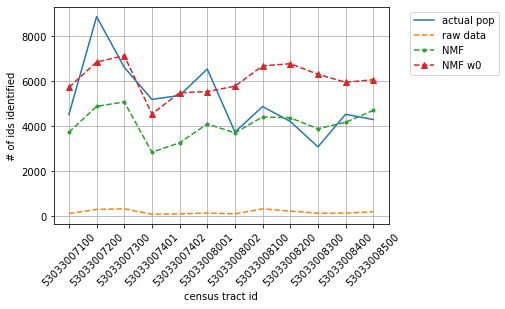

In [533]:
plt.plot(ct_pop, label='actual pop')
plt.plot(get_loc_sum(origin_WH_max, origin_WH_index), label='raw data', 
        linestyle='dashed')
plt.plot(get_loc_sum(WH_max_nmf, WH_index_nmf), label='NMF',
        linestyle='dashed', marker='.')
plt.plot(get_loc_sum(WH_max_mmf_w0, WH_index_nmf_w0), label='NMF w0',
        linestyle='dashed', marker='^')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.grid()
plt.xticks(list(range(12)), census_tract, rotation=45)
plt.ylabel('# of ids identified')
plt.xlabel('census tract id')

In [70]:
from scipy.stats import kstest
from scipy.stats import mannwhitneyu

In [105]:
print(list(get_loc_sum(ori_max, ori_index)))
print(list(get_loc_sum(WH_max_nmf, WH_index_nmf)))
print(list(get_loc_sum(WH_max_mmf_w0, WH_index_nmf_w0)))
print(list(get_loc_sum(knn_max, knn_index)))
print(list(get_loc_sum(knn_max10, knn_index10)))
print(list(get_loc_sum(knn_max300, knn_index300)))
print(list(get_loc_sum(em_max, em_index)))
print(list(get_loc_sum(em_ber_max, em_ber_index)))

[133.0, 312.0, 338.0, 98.0, 115.0, 151.0, 115.0, 336.0, 238.0, 144.0, 147.0, 212.0]
[2889.0, 5179.0, 4664.0, 2712.0, 2793.0, 3194.0, 3049.0, 4782.0, 4447.0, 4152.0, 3616.0, 3838.0]
[4896.0, 6087.0, 6108.0, 3812.0, 4205.0, 4668.0, 4914.0, 5819.0, 5847.0, 5620.0, 5114.0, 5150.0]
[133.0, 7767.0, 7766.0, 98.0, 115.0, 375.0, 115.0, 7766.0, 7747.0, 7698.0, 147.0, 212.0]
[4782.0, 7298.0, 6654.0, 3474.0, 3094.0, 1971.0, 2404.0, 6142.0, 4984.0, 3544.0, 2725.0, 2394.0]
[133.0, 7767.0, 7766.0, 98.0, 115.0, 151.0, 115.0, 7766.0, 7747.0, 7698.0, 147.0, 212.0]
[5807.0, 7544.0, 7220.0, 2932.0, 3388.0, 4416.0, 2294.0, 7271.0, 6576.0, 5443.0, 4516.0, 5459.0]
[1311.0, 2613.0, 2482.0, 1036.0, 1205.0, 1263.0, 855.0, 2489.0, 1957.0, 1479.0, 1342.0, 1593.0]


In [106]:
print('raw vs actual', kstest(list(get_loc_sum(ori_max, ori_index)),
       ct_pop))
print('nmf vs actual', kstest(list(get_loc_sum(WH_max_nmf, WH_index_nmf)),
       ct_pop))
print('nmf with zero vs actual', kstest(list(get_loc_sum(WH_max_mmf_w0, WH_index_nmf_w0)),
       ct_pop))
print('knn vs actual', kstest(list(get_loc_sum(knn_max, knn_index)),
       ct_pop))
print('em with zero vs actual', kstest(list(get_loc_sum(em_max, em_index)),
       ct_pop))
print('em ber with zero vs actual', kstest(list(get_loc_sum(em_ber_max, em_ber_index)),
       ct_pop))

raw vs actual KstestResult(statistic=1.0, pvalue=7.396023010506791e-07)
nmf vs actual KstestResult(statistic=0.5, pvalue=0.09954677170991616)
nmf with zero vs actual KstestResult(statistic=0.3333333333333333, pvalue=0.5360977695073805)
knn vs actual KstestResult(statistic=0.5833333333333334, pvalue=0.031436056203858066)
em with zero vs actual KstestResult(statistic=0.3333333333333333, pvalue=0.5360977695073805)
em ber with zero vs actual KstestResult(statistic=1.0, pvalue=7.396023010506791e-07)


In [107]:
print('raw vs actual', mannwhitneyu(list(get_loc_sum(ori_max, ori_index)),
       ct_pop))
print('nmf vs actual', mannwhitneyu(list(get_loc_sum(WH_max_nmf, WH_index_nmf)),
       ct_pop))
print('nmf with zero vs actual', mannwhitneyu(list(get_loc_sum(WH_max_mmf_w0, WH_index_nmf_w0)),
       ct_pop))
print('knn vs actual', mannwhitneyu(list(get_loc_sum(knn_max, knn_index)),
       ct_pop))
print('em with zero vs actual', mannwhitneyu(list(get_loc_sum(em_max, em_index)),
       ct_pop))
print('em ber with zero vs actual', mannwhitneyu(list(get_loc_sum(em_ber_max, em_ber_index)),
       ct_pop))

raw vs actual MannwhitneyuResult(statistic=0.0, pvalue=3.644202729246209e-05)
nmf vs actual MannwhitneyuResult(statistic=29.0, pvalue=0.014137969455911484)
nmf with zero vs actual MannwhitneyuResult(statistic=83.0, pvalue=0.5443701458566098)
knn vs actual MannwhitneyuResult(statistic=55.0, pvalue=0.34056858806388934)
em with zero vs actual MannwhitneyuResult(statistic=79.0, pvalue=0.7074539677020747)
em ber with zero vs actual MannwhitneyuResult(statistic=0.0, pvalue=3.6584553538971e-05)


In [501]:
arr[get_idx(unique_loc)]+=1

In [502]:
arr

array([1., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

In [431]:
for i in range(12):
    with_data = WH_index_home[test[np.sum(WH_max_home, axis=1)>0],]
    with_data[with_data==i]

array([[0, 9, 9, ..., 0, 0, 2],
       [6, 0, 6, ..., 0, 0, 0],
       [0, 0, 0, ..., 4, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)